> **Experiment E01: Exploratory data analysis**  
> Spec, decision rule and results: [docs/experiments/E01_eda.md](../docs/experiments/E01_eda.md)  
> Depends on: none · Status: done  
> Registered in `experiments/registry.yaml`; see the [experiment graph](../docs/experiments/EXPERIMENT_GRAPH.md).

# Exploratory Data Analysis — Wind Farm C (CARE to Compare SCADA Benchmark)

**Project context:** predictive maintenance / early failure detection research
**Data:** [Wind Turbine SCADA Data For Early Fault Detection](https://www.kaggle.com/datasets/azizkasimov/wind-turbine-scada-data-for-early-fault-detection)
— Wind Farm C (offshore, Germany), 10-minute resolution, anonymised
**Source of record:** Zenodo [10.5281/zenodo.10958775](https://doi.org/10.5281/zenodo.10958775) ·
Paper: Gück & Roelofs, *CARE to Compare*, Data 2024, 9(12):138 ([10.3390/data9120138](https://doi.org/10.3390/data9120138))
**Author:** _<add name>_ · **Version:** 1.1 (Kaggle)

---

## 1. Introduction

### 1.1 Purpose of this notebook

This notebook performs a **complete, reproducible exploratory data analysis (EDA)** of the
Wind Farm C subset of the *CARE to Compare* benchmark, in preparation for building
**normal-behaviour models (NBM)** and **early failure detection** algorithms.

The EDA is deliberately structured around four research questions:

| # | Question | Sections |
|---|----------|----------|
| Q1 | **What is in the data?** Structure, schema, label semantics. | 3 – 5 |
| Q2 | **Can we trust the data?** Missingness, duplicates, timestamp integrity, sensor faults. | 6 – 9, 20 |
| Q3 | **What does normal behaviour look like?** Distributions, correlations, power curve, seasonality. | 10 – 19 |
| Q4 | **What should the model consume?** Feature engineering and modelling recommendations. | 21 – 22 |

### 1.2 Dataset background

Wind Farm C is the largest of the three farms in the benchmark. The key facts that shape
every decision in this notebook are:

* **22 turbines / 58 sub-datasets** — 27 contain a labelled anomaly event, 31 are pure
  normal behaviour. Each sub-dataset is one CSV: **one year of training data** followed by
  **4–98 days of prediction data**.
* **957 columns / 238 physical sensors** — most sensors are exposed as
  `*_avg`, and many additionally as `*_min`, `*_max`, `*_std` over the 10-minute window.
  This is a **wide, highly redundant** feature space; naive `df.describe()` or a full
  correlation heatmap is unusable, so this notebook works with an explicit
  *core feature set* plus data-driven feature shortlists.
* **Five descriptive columns**: row `id`, `time_stamp`, `asset_id` (turbine),
  `train_test` (train vs. prediction partition), `status_type_id` (operating state).
* **Anonymisation**: sensor names are numbered; only *power*, *reactive power* and
  *wind speed* remain identifiable by name. Power channels are **scaled by rated power**
  (so they are dimensionless, typically in `[0, 1]`), and all timestamps have been
  **shifted so each sub-dataset starts in 2022** — seasonality is preserved, absolute
  chronology across datasets is not.

**The named channels in Wind Farm C are not unique.** Per the dataset record there are
*four* power channels (`power_2`, `power_5`, `power_6`, `power_17`), *four* reactive-power
channels (`reactive_power_119` … `reactive_power_122`) and *three* wind-speed channels
(`wind_speed_235`, `wind_speed_236`, `wind_speed_237`), alongside `sensor_0` … `sensor_234`.
Section 3.6 therefore *selects* a primary channel for each role from the candidates
present, data-driven rather than hard-coded, and prints the full candidate table so the
choice can be overridden.

### 1.3 Three data-quality caveats that drive the analysis

Both are stated explicitly by the dataset authors and are the reason several unusual
checks appear below:

1. **Missing values were replaced by `0` by the operator** for Wind Farms B and C.
   A zero is therefore *ambiguous*: it can mean "genuinely zero" (turbine idle) or
   "no data". Long runs of consecutive zeros must be treated as missing.
   → Section 5 implements a *zero-run* detector rather than relying on `NaN` counts.
2. **Status codes are only logged on change** and can be lost during brief communication
   outages, so `status_type_id` is not fully reliable. The recommended cross-check is to
   compare wind speed against power: if wind speed is inside the operating range but power
   is ~0, the turbine was probably not in normal operation regardless of the logged status.
   → Section 18 implements this physics-based status correction.
3. **The `min` / `max` / `std` columns are unreliable.** The dataset's *Known Data Issues*
   notice states that per-timestamp Min/Max/Std were passed through as-is by the operator
   and are frequently implausible, in four documented ways: `std` larger than the maximum
   possible given min/max/avg; `min > avg`; `max < avg`; and min/max/std identically zero.
   For Wind Farm C, 17 sensors are affected in ~20–30% of records, a further 90 in ~10–15%,
   and 131 in under 5%. **Only the `*_avg` channels are described as generally plausible.**
   → Section 9.3 quantifies all four issues on this data, and the loader defaults to
   `CFG.avg_only = True` — which also cuts the 957 columns down to a tractable ~243.

### 1.4 Label semantics (used throughout)

| `status_type_id` | Description | Considered normal |
|---|---|---|
| 0 | Normal operation without limitations | **Yes** |
| 1 | Derated generation (power restriction) | No |
| 2 | Asset idling, waiting to operate | **Yes** |
| 3 | Service mode / service team on site | No |
| 4 | Down due to fault or other reason | No |
| 5 | Other states (system test, setup, ice build-up, emergency power) | No |

Event-level labels (`anomaly` / `normal`) live in `event_info.csv` and apply to the
*prediction* partition of each sub-dataset. Following the benchmark's evaluation protocol,
points with a **non-normal status are excluded from scoring** — they are trivially
detectable and already known to the operator. This notebook mirrors that convention:
statistics describing "normal behaviour" are computed on `status_type_id in {0, 2}` only.

### 1.5 How to run on Kaggle

1. **Add the data**: *Add Input* → search `wind-turbine-scada-data-for-early-fault-detection`
   → add. Kaggle mounts it read-only, though the exact mount point varies slightly by
   attach method (`Add Input` vs. a KaggleHub cache vs. a rerun).
2. **Run all**. Section 3.1 tries the known mount points in turn — including
   `/kaggle/input/datasets/azizkasimov/wind-turbine-scada-data-for-early-fault-detection`
   and `/kaggle/input/wind-turbine-scada-data-for-early-fault-detection` — walks each one,
   and locates the `Wind Farm C` directory wherever it sits. No path editing required.
3. If the dataset is not attached, the notebook falls back to a **synthetic Wind Farm C
   simulator** with the same schema, naming and documented defects, so every cell still
   executes top to bottom. A banner states which mode is active; never quote synthetic
   numbers as results.

**Resource notes.** Wind Farm C is the largest farm in the benchmark (5.5 GB across all
three farms). Two settings keep the notebook inside a standard Kaggle session:
`CFG.avg_only = True` drops the `min`/`max`/`std` columns at read time (they are unreliable
anyway — see §1.3), and `CFG.max_datasets` caps how many of the 58 sub-datasets are loaded.
Outputs are written to `/kaggle/working/`, so figures and tables persist as notebook output.

The Kaggle mirror's only change to the Zenodo original is that the CSV separator was
converted from `;` to `,`; the loader auto-detects either.

---
## 2. Environment, Configuration and Reusable Helpers

Everything configurable lives in one place (`CFG`) so the notebook can be re-pointed at
Wind Farm A or B, or at a different turbine, by editing a single cell.

### 2.1 Imports and global configuration

In [50]:
from __future__ import annotations

import json
import re
import warnings
from dataclasses import dataclass, field
from pathlib import Path
from typing import Dict, Iterable, List, Optional, Sequence, Tuple

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

print(f"pandas {pd.__version__} | numpy {np.__version__} | seaborn {sns.__version__}")

pandas 2.3.3 | numpy 2.0.2 | seaborn 0.13.2


### 2.2 Analysis configuration

In [51]:
@dataclass
class EDAConfig:
    # --- data location -------------------------------------------------
    # Leave as None to auto-discover under /kaggle/input (see Section 3.1),
    # or set explicitly, e.g. Path("/kaggle/input/<slug>/Wind Farm C")
    data_root: Optional[Path] = None
    kaggle_input: Path = Path("/kaggle/input")
    farm_name: str = "C"

    # --- scope control (the farm has 58 datasets x 957 columns) ---------
    max_datasets: Optional[int] = 8      # None = load everything (memory heavy)
    avg_only: bool = True                # drop *_min/*_max/*_std at read time
    max_columns_per_file: Optional[int] = None   # None = no extra cap

    # --- schema ---------------------------------------------------------
    ts_col: str = "time_stamp"
    id_col: str = "id"
    asset_col: str = "asset_id"
    split_col: str = "train_test"
    status_col: str = "status_type_id"
    expected_freq: str = "10min"

    # --- domain knowledge -------------------------------------------------
    normal_status_ids: Tuple[int, ...] = (0, 2)
    cut_in_speed: float = 3.0            # m/s
    rated_speed: float = 13.0            # m/s
    cut_out_speed: float = 25.0          # m/s

    # --- analysis knobs ---------------------------------------------------
    zero_run_threshold: int = 6          # >= 6 x 10 min = 1 h of zeros -> suspect missing
    flatline_threshold: int = 18         # >= 3 h of an identical non-zero value
    corr_top_k: int = 25                 # features in the correlation heat-map
    redundancy_threshold: float = 0.98   # |rho| above which two sensors are duplicates
    zscore_threshold: float = 3.0
    iqr_multiplier: float = 1.5
    rolling_windows: Tuple[str, ...] = ("6h", "24h", "7D")

    # --- output ------------------------------------------------------------
    work_dir: Path = Path("/kaggle/working") if Path("/kaggle/working").exists() else Path(".")
    save_figures: bool = True
    fig_dpi: int = 150

    @property
    def fig_dir(self) -> Path:
        return self.work_dir / "figures"

    @property
    def out_dir(self) -> Path:
        return self.work_dir / "outputs"


CFG = EDAConfig()
CFG.fig_dir.mkdir(parents=True, exist_ok=True)
CFG.out_dir.mkdir(parents=True, exist_ok=True)

STATUS_LABELS = {
    0: "0 · Normal operation",
    1: "1 · Derated / curtailed",
    2: "2 · Idling",
    3: "3 · Service mode",
    4: "4 · Fault / down",
    5: "5 · Other (test, ice, ...)",
}
STATUS_IS_NORMAL = {k: (k in CFG.normal_status_ids) for k in STATUS_LABELS}

CFG

EDAConfig(data_root=None, kaggle_input=PosixPath('/kaggle/input'), farm_name='C', max_datasets=8, avg_only=True, max_columns_per_file=None, ts_col='time_stamp', id_col='id', asset_col='asset_id', split_col='train_test', status_col='status_type_id', expected_freq='10min', normal_status_ids=(0, 2), cut_in_speed=3.0, rated_speed=13.0, cut_out_speed=25.0, zero_run_threshold=6, flatline_threshold=18, corr_top_k=25, redundancy_threshold=0.98, zscore_threshold=3.0, iqr_multiplier=1.5, rolling_windows=('6h', '24h', '7D'), work_dir=PosixPath('/kaggle/working'), save_figures=True, fig_dpi=150)

### 2.3 Plotting theme and figure helpers

A single theme keeps every figure consistent (fonts, grid, colours) and
`save_fig()` writes publication-ready PNGs at 150 dpi into `figures/`.

In [52]:
# --- consistent, colour-blind-safe palette used across the whole notebook ---
PALETTE = {
    "primary":   "#1f4e79",   # deep blue  - main signal / power
    "secondary": "#2e8b57",   # green      - wind speed
    "accent":    "#d95f02",   # orange     - temperature / derived
    "warning":   "#c0392b",   # red        - anomalies, outliers, faults
    "neutral":   "#7f8c8d",   # grey       - reference lines, context
    "light":     "#bdc3c7",
}
STATUS_COLORS = {
    0: "#2e8b57", 1: "#e6a700", 2: "#4a90d9",
    3: "#8e44ad", 4: "#c0392b", 5: "#7f8c8d",
}
SEQ_CMAP = "viridis"
DIV_CMAP = "RdBu_r"


def setup_plot_style() -> None:
    """Apply the notebook-wide Matplotlib/Seaborn theme."""
    sns.set_theme(context="notebook", style="whitegrid")
    mpl.rcParams.update({
        "figure.dpi": 110,
        "savefig.dpi": CFG.fig_dpi,
        "savefig.bbox": "tight",
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "axes.titlesize": 13,
        "axes.titleweight": "semibold",
        "axes.labelsize": 11,
        "axes.edgecolor": "#333333",
        "axes.linewidth": 0.9,
        "grid.color": "#dddddd",
        "grid.linewidth": 0.7,
        "legend.frameon": True,
        "legend.framealpha": 0.9,
        "legend.fontsize": 9,
        "xtick.labelsize": 9,
        "ytick.labelsize": 9,
        "font.size": 10,
        "figure.max_open_warning": 0,
    })


setup_plot_style()


def save_fig(fig: plt.Figure, name: str) -> None:
    """Persist a figure with a deterministic, sortable filename."""
    if not CFG.save_figures:
        return
    path = CFG.fig_dir / f"{name}.png"
    fig.savefig(path)


def annotate_source(ax: plt.Axes, text: str) -> None:
    """Small caption under an axis - useful for figure provenance in a paper."""
    ax.annotate(text, xy=(0, -0.16), xycoords="axes fraction",
                fontsize=8, color=PALETTE["neutral"], va="top")


def section_banner(title: str) -> None:
    print("=" * 78)
    print(title)
    print("=" * 78)

### 2.4 Generic tabular helpers

Small, side-effect-free utilities reused by many sections.

In [53]:
def human_bytes(n: float) -> str:
    for unit in ("B", "KB", "MB", "GB", "TB"):
        if abs(n) < 1024.0:
            return f"{n:3.1f} {unit}"
        n /= 1024.0
    return f"{n:.1f} PB"


def memory_footprint(df: pd.DataFrame) -> str:
    return human_bytes(df.memory_usage(deep=True).sum())


def downcast_numeric(df: pd.DataFrame) -> pd.DataFrame:
    """Shrink float64/int64 columns; ~50% RAM saving on 957-column SCADA files."""
    out = df.copy()
    for col in out.select_dtypes(include=["float64"]).columns:
        out[col] = pd.to_numeric(out[col], downcast="float")
    for col in out.select_dtypes(include=["int64"]).columns:
        out[col] = pd.to_numeric(out[col], downcast="integer")
    return out


def numeric_columns(df: pd.DataFrame, exclude: Sequence[str] = ()) -> List[str]:
    cols = df.select_dtypes(include=[np.number]).columns.tolist()
    return [c for c in cols if c not in set(exclude)]


def sensor_columns(df: pd.DataFrame) -> List[str]:
    """All measurement columns, i.e. everything that is not descriptive metadata."""
    meta = {CFG.id_col, CFG.ts_col, CFG.asset_col, CFG.split_col, CFG.status_col,
            "event_id", "event_label", "dataset_id", "status_is_normal"}
    return [c for c in numeric_columns(df) if c not in meta]


def stat_suffix(col: str) -> str:
    """Return the aggregation suffix of a SCADA channel (avg / min / max / std)."""
    m = re.search(r"_(avg|min|max|std)$", col)
    return m.group(1) if m else "other"


def base_sensor(col: str) -> str:
    """Strip the aggregation suffix: sensor_12_max -> sensor_12."""
    return re.sub(r"_(avg|min|max|std)$", "", col)


def show(df: pd.DataFrame, n: int = 10, caption: str = "") -> pd.DataFrame:
    if caption:
        print(caption)
    return df.head(n)

---
## 3. Dataset Loading

The CARE-to-Compare distribution ships one folder per wind farm:

```
Wind Farm C/
├── datasets/            # one CSV per sub-dataset, named <event_id>.csv
│   ├── 40.csv
│   └── ...
├── event_info.csv       # event_id, event_start/end, event_label, description
└── feature_description.csv
```

Kaggle mirrors wrap this in an arbitrary extra directory level, so rather than hard-coding
a path the loader **inventories `/kaggle/input` and finds the Wind Farm C directory itself**.
It is otherwise defensive: flat or nested layouts, `comma_*.csv` / `semicolon_*.csv` naming
variants, `,` or `;` separators. If nothing is found it switches to the **synthetic
simulator** so the notebook remains executable.

### 3.1 Inventory the Kaggle input and locate Wind Farm C

In [54]:
import os

# Kaggle mounts this dataset at slightly different paths depending on how it was
# attached (Add Input vs. kagglehub cache vs. a competition-style rerun), so several
# candidate roots are tried in order rather than hard-coding one.
KAGGLE_SEARCH_ROOTS = [
    Path("/kaggle/input/datasets/azizkasimov/wind-turbine-scada-data-for-early-fault-detection"),
    Path("/kaggle/input/wind-turbine-scada-data-for-early-fault-detection"),
    CFG.kaggle_input,
]


def inventory_path(root: Path, max_entries: int = 5) -> None:
    # Cheap, top-level sanity check: what does the mount actually contain?
    if not root.exists():
        print(f"  [absent] {root}")
        return
    for dirpath, dirnames, filenames in os.walk(root):
        print(f"  {dirpath}  dirs={dirnames}  files={filenames[:max_entries]}")
        break                                          # first level only, like a quick ls


def find_farm_c_dir(root: Path, farm: str = None) -> Optional[Path]:
    # Walk `root` looking for the Wind Farm <farm> directory: either a folder literally
    # named "Wind Farm <farm>" containing a "datasets" subfolder, or any folder whose
    # "datasets" subfolder sits next to an event_info file (plain or "comma_"-prefixed,
    # matching the two naming variants seen across CARE-to-Compare mirrors).
    farm = farm or CFG.farm_name
    target_name = f"wind farm {farm}".lower()
    for dirpath, dirnames, filenames in os.walk(root):
        base = os.path.basename(dirpath).lower()
        lower_files = [f.lower() for f in filenames]
        if base == target_name and "datasets" in dirnames:
            return Path(dirpath)
        if "datasets" in dirnames and any(
            f in ("event_info.csv", "comma_event_info.csv") for f in lower_files
        ):
            return Path(dirpath)
    return None


def locate_wind_farm_c(search_roots: Sequence[Path] = KAGGLE_SEARCH_ROOTS,
                       farm: str = None) -> Optional[Path]:
    # Try each candidate root in turn; print what was found (or not) for transparency.
    farm = farm or CFG.farm_name
    for root in search_roots:
        if not root.exists():
            print(f"  [skip] {root} (not mounted)")
            continue
        inventory_path(root)
        found = find_farm_c_dir(root, farm)
        if found is not None:
            return found
        print(f"  [not found under] {root}")
    return None


print("Searching for the Wind Farm C data under the known Kaggle mount points:")
if CFG.data_root is None:
    CFG.data_root = locate_wind_farm_c()
print(f"\nResolved CFG.data_root -> {CFG.data_root}")

Searching for the Wind Farm C data under the known Kaggle mount points:
  /kaggle/input/datasets/azizkasimov/wind-turbine-scada-data-for-early-fault-detection  dirs=['Wind Farm C', 'Wind Farm A', 'Wind Farm B']  files=['README.md', 'README.txt']

Resolved CFG.data_root -> /kaggle/input/datasets/azizkasimov/wind-turbine-scada-data-for-early-fault-detection/Wind Farm C


### 3.2 Loader functions

In [55]:
def _read_csv_flexible(path: Path, usecols=None) -> pd.DataFrame:
    # Read a CSV whose delimiter may be "," or ";" (both ship with the benchmark).
    try:
        df = pd.read_csv(path, sep=None, engine="python", usecols=usecols)
    except Exception:
        df = pd.read_csv(path, usecols=usecols)
    df.columns = [str(c).strip() for c in df.columns]
    return df


def find_file(root: Path, stem: str) -> Optional[Path]:
    # Locate event_info / feature_description regardless of the naming variant.
    if not root.exists():
        return None
    for candidate in sorted(root.glob("*.csv")):
        if stem in candidate.stem.lower():
            return candidate
    return None


def discover_datasets(root: Path) -> List[Path]:
    # Return the per-turbine CSVs, preferring the canonical datasets/ subfolder.
    if not root.exists():
        return []
    nested = sorted((root / "datasets").glob("*.csv")) if (root / "datasets").exists() else []
    if nested:
        return nested
    meta_stems = ("event_info", "feature_description")
    return [p for p in sorted(root.glob("*.csv"))
            if not any(s in p.stem.lower() for s in meta_stems)]


def load_event_info(root: Path) -> pd.DataFrame:
    path = find_file(root, "event_info")
    if path is None:
        return pd.DataFrame()
    ev = _read_csv_flexible(path)
    for col in ("event_start", "event_end"):
        if col in ev.columns:
            ev[col] = pd.to_datetime(ev[col], errors="coerce")
    return ev


def load_feature_description(root: Path) -> pd.DataFrame:
    path = find_file(root, "feature_description")
    return _read_csv_flexible(path) if path is not None else pd.DataFrame()


META_COLS = ("id", "time_stamp", "asset_id", "train_test", "status_type_id")


def plan_columns(path: Path, cfg: EDAConfig = CFG) -> Optional[List[str]]:
    # Decide which columns to read. Dropping *_min/*_max/*_std takes Wind Farm C
    # from 957 columns to ~243 and removes the channels the dataset authors flag
    # as unreliable (see section 1.3).
    if not cfg.avg_only and cfg.max_columns_per_file is None:
        return None
    header = pd.read_csv(path, nrows=0, sep=None, engine="python")
    cols = [str(c).strip() for c in header.columns]
    meta = [c for c in cols if c in META_COLS]
    rest = [c for c in cols if c not in meta]
    if cfg.avg_only:
        rest = [c for c in rest if not re.search(r"_(min|max|std)$", c)]
    if cfg.max_columns_per_file is not None:
        rest = rest[: max(0, cfg.max_columns_per_file - len(meta))]
    return meta + rest


def load_single_dataset(path: Path, cfg: EDAConfig = CFG,
                        all_columns: bool = False) -> pd.DataFrame:
    # Load one sub-dataset CSV and attach its dataset identifier.
    usecols = None if all_columns else plan_columns(path, cfg)
    df = _read_csv_flexible(path, usecols=usecols)
    df["dataset_id"] = path.stem
    return downcast_numeric(df)


# One sub-dataset is always kept with ALL columns so that section 9.3 can audit
# the min/max/std statistics even when cfg.avg_only drops them everywhere else.
STATS_SAMPLE: Optional[pd.DataFrame] = None


def load_wind_farm(cfg: EDAConfig = CFG):
    # Load up to cfg.max_datasets sub-datasets, or fall back to the simulator.
    # Returns (raw_dataframe, event_info, feature_description, mode).
    global STATS_SAMPLE
    paths = discover_datasets(cfg.data_root) if cfg.data_root else []
    if not paths:
        loc = cfg.data_root if cfg.data_root else cfg.kaggle_input
        print(f"[!] No sub-dataset CSVs found under {loc} - using the synthetic simulator.")
        print("    On Kaggle: Add Input -> "
              "'wind-turbine-scada-data-for-early-fault-detection', then re-run.")
        raw, events, feats = simulate_wind_farm_c(cfg)
        STATS_SAMPLE = raw[raw["dataset_id"] == raw["dataset_id"].iloc[0]].copy()
        if cfg.avg_only:
            drop = [c for c in raw.columns if re.search(r"_(min|max|std)$", c)]
            raw = raw.drop(columns=drop)
        return raw, events, feats, "synthetic"

    if cfg.max_datasets is not None:
        paths = paths[: cfg.max_datasets]
    print(f"Loading {len(paths)} sub-dataset(s) from {cfg.data_root}"
          f"{' (avg channels only)' if cfg.avg_only else ''} ...")

    frames = []
    for i, p in enumerate(paths):
        try:
            if i == 0:                                # keep one file in full
                full = load_single_dataset(p, cfg, all_columns=True)
                STATS_SAMPLE = full
                drop = ([c for c in full.columns if re.search(r"_(min|max|std)$", c)]
                        if cfg.avg_only else [])
                frames.append(full.drop(columns=drop))
            else:
                frames.append(load_single_dataset(p, cfg))
            print(f"  [{i + 1}/{len(paths)}] {p.name}: {frames[-1].shape}")
        except Exception as exc:                      # never let one bad file stop the EDA
            print(f"  [!] Skipped {p.name}: {exc}")
    raw = pd.concat(frames, ignore_index=True, sort=False)
    return raw, load_event_info(cfg.data_root), load_feature_description(cfg.data_root), "real"

### 3.3 Synthetic Wind Farm C simulator (fallback only)

The simulator is **not** a modelling tool - it exists so the notebook is self-testing.
It reproduces the real column naming (`power_2/5/6/17`, `reactive_power_119/120`,
`wind_speed_235/236/237`, `sensor_k`) and, importantly, the *defects* documented for Wind
Farm C: zeros standing in for missing data, implausible min/max/std statistics, duplicated
rows, timestamp gaps, frozen sensors, curtailment, and one slow gearbox-temperature drift
preceding a fault.

In [56]:
def _power_curve(ws: np.ndarray, cfg: EDAConfig) -> np.ndarray:
    # Normalised (0-1) power curve: cubic between cut-in and rated, flat to cut-out.
    p = np.zeros_like(ws, dtype=float)
    ramp = (ws >= cfg.cut_in_speed) & (ws < cfg.rated_speed)
    p[ramp] = ((ws[ramp] - cfg.cut_in_speed) /
               (cfg.rated_speed - cfg.cut_in_speed)) ** 3
    p[(ws >= cfg.rated_speed) & (ws <= cfg.cut_out_speed)] = 1.0
    return np.clip(p, 0.0, 1.0)


def _simulate_one(dataset_id: str, asset_id: int, label: str,
                  n_sensors: int, cfg: EDAConfig, seed: int):
    # One sub-dataset: 1 year of training data + a prediction window.
    r = np.random.default_rng(seed)
    train_days, pred_days = 365, int(r.integers(20, 90))
    n = int((train_days + pred_days) * 24 * 6)
    t = pd.date_range("2022-01-01", periods=n, freq=cfg.expected_freq)

    hours = t.hour.to_numpy() + t.minute.to_numpy() / 60.0
    doy = t.dayofyear.to_numpy()

    # wind speed: base + winter seasonality + diurnal cycle + AR(1) gusts
    seasonal = 1.6 * np.cos(2 * np.pi * (doy - 15) / 365.0)
    diurnal = 0.6 * np.sin(2 * np.pi * (hours - 15) / 24.0)
    gust = np.zeros(n)
    innov = r.normal(0, 1.1, n)
    for i in range(1, n):
        gust[i] = 0.96 * gust[i - 1] + innov[i]
    ws = np.clip(7.5 + seasonal + diurnal + gust, 0.0, 32.0)

    amb_t = 9.0 - 7.5 * np.cos(2 * np.pi * (doy - 20) / 365.0) + r.normal(0, 1.4, n)

    power = _power_curve(ws, cfg) * (1 + r.normal(0, 0.045, n))
    power = np.clip(power, 0.0, 1.02)
    reactive = power * r.normal(0.18, 0.05, n)

    rotor_rpm = 4.0 + 9.5 * np.clip((ws - cfg.cut_in_speed) / 10.0, 0, 1) + r.normal(0, 0.25, n)
    gen_rpm = rotor_rpm * 97.0 + r.normal(0, 15, n)
    pitch = np.where(ws > cfg.rated_speed, (ws - cfg.rated_speed) * 2.4, 0.0) + r.normal(0, 0.35, n)
    nacelle_dir = (180 + 60 * np.sin(2 * np.pi * doy / 365.0) + r.normal(0, 12, n)) % 360

    def thermal(base, gain, tau=0.02):
        # first-order thermal response to load and ambient temperature
        drive = base + gain * power + 0.55 * amb_t
        out = np.empty(n)
        out[0] = drive[0]
        for i in range(1, n):
            out[i] = out[i - 1] + tau * (drive[i] - out[i - 1])
        return out + r.normal(0, 0.5, n)

    gear_bearing = thermal(38.0, 26.0)
    gear_oil = thermal(41.0, 22.0)
    generator_t = thermal(45.0, 34.0)
    nacelle_t = thermal(21.0, 9.0)

    status = np.zeros(n, dtype=int)
    status[power < 0.005] = 2                                   # idling
    curtail = r.random(n) < 0.015                               # derated
    power[curtail] *= r.uniform(0.25, 0.7, curtail.sum())
    status[curtail] = 1
    for _ in range(int(r.integers(1, 4))):                      # service windows
        s = int(r.integers(0, n - 200))
        status[s:s + int(r.integers(40, 200))] = 3

    event_start = event_end = pd.NaT
    if label == "anomaly":
        ev_i = n - int(pred_days * 24 * 6 * 0.45)
        drift = np.clip(np.arange(n) - (ev_i - 30 * 144), 0, None) / (30 * 144)
        gear_bearing = gear_bearing + 7.5 * drift
        gear_oil = gear_oil + 5.0 * drift
        end_i = min(n - 1, ev_i + 12 * 144)
        event_start, event_end = t[ev_i], t[end_i]
        status[end_i:end_i + 300] = 4

    # --- column names mirror the real Wind Farm C schema ---------------------
    core = {
        "wind_speed_235_avg": ws,
        "wind_speed_235_max": ws * r.uniform(1.05, 1.30, n),
        "wind_speed_235_min": ws * r.uniform(0.70, 0.95, n),
        "wind_speed_235_std": np.abs(r.normal(0.9, 0.3, n)),
        "wind_speed_236_avg": ws * r.uniform(0.97, 1.03) + r.normal(0, 0.25, n),
        "wind_speed_237_avg": ws * r.uniform(0.97, 1.03) + r.normal(0, 0.25, n),
        "power_5_avg": power,
        "power_5_max": np.clip(power * r.uniform(1.02, 1.12, n), 0, 1.1),
        "power_5_min": power * r.uniform(0.85, 0.99, n),
        "power_5_std": np.abs(r.normal(0.04, 0.015, n)),
        "power_2_avg": power * r.uniform(0.98, 1.0) + r.normal(0, 0.004, n),
        "power_6_avg": power * r.uniform(0.98, 1.0) + r.normal(0, 0.004, n),
        "power_17_avg": np.zeros(n),                       # a dead named channel
        "reactive_power_119_avg": reactive,
        "reactive_power_120_avg": reactive * r.uniform(0.95, 1.05),
        "sensor_0_avg": rotor_rpm,
        "sensor_1_avg": gen_rpm,
        "sensor_2_avg": pitch,
        "sensor_3_avg": nacelle_dir,
        "sensor_4_avg": amb_t,
        "sensor_5_avg": nacelle_t,
        "sensor_6_avg": gear_bearing,
        "sensor_7_avg": gear_oil,
        "sensor_8_avg": generator_t,
    }
    for k in range(9, n_sensors):
        if k % 11 == 0:
            core[f"sensor_{k}_avg"] = np.full(n, 1.0)                       # constant/dead
        elif k % 3 == 0:
            core[f"sensor_{k}_avg"] = gear_bearing * r.uniform(0.9, 1.1) + r.normal(0, 0.8, n)
        elif k % 3 == 1:
            core[f"sensor_{k}_avg"] = power * r.uniform(80, 120) + r.normal(0, 2.5, n)
        else:
            core[f"sensor_{k}_avg"] = r.normal(50, 8, n)
        if k % 4 == 0:
            core[f"sensor_{k}_max"] = core[f"sensor_{k}_avg"] * 1.08
            core[f"sensor_{k}_min"] = core[f"sensor_{k}_avg"] * 0.92
            core[f"sensor_{k}_std"] = np.abs(r.normal(1.0, 0.3, n))
    for suf in ("min", "max", "std"):
        core.setdefault(f"sensor_12_{suf}", np.zeros(n))

    df = pd.DataFrame(core)
    df.insert(0, cfg.id_col, np.arange(n))
    df.insert(1, cfg.ts_col, t)
    df.insert(2, cfg.asset_col, asset_id)
    df.insert(3, cfg.status_col, status)
    df.insert(4, cfg.split_col, np.where(np.arange(n) < train_days * 144, "train", "prediction"))
    df["dataset_id"] = dataset_id

    # ---- inject the documented Wind Farm C defects --------------------
    sens = [c for c in df.columns if c.startswith(("sensor_", "power_", "wind_", "reactive_"))]
    for _ in range(6):                                   # zeros standing in for missing data
        s = int(r.integers(0, n - 400))
        ln = int(r.integers(12, 380))
        df.loc[s:s + ln, list(r.choice(sens, size=6, replace=False))] = 0.0
    for _ in range(2):                                   # genuine NaN blocks
        s = int(r.integers(0, n - 200))
        df.loc[s:s + int(r.integers(6, 150)), list(r.choice(sens, size=3, replace=False))] = np.nan
    frozen = str(r.choice(sens))                         # frozen / stuck sensor
    s = int(r.integers(0, n - 1500))
    df.loc[s:s + 900, frozen] = df.loc[s, frozen]
    spike_rows = r.choice(n, size=max(4, n // 6000), replace=False)
    df.loc[spike_rows, "sensor_8_avg"] = float(df["sensor_8_avg"].mean()) * 4.5

    # implausible min/max/std statistics, exactly as documented for Wind Farm C
    bad = r.choice(n, size=int(n * 0.15), replace=False)          # issue 2: min > avg
    df.loc[bad, "wind_speed_235_min"] = df.loc[bad, "wind_speed_235_avg"] * 1.15
    bad = r.choice(n, size=int(n * 0.12), replace=False)          # issue 3: max < avg
    df.loc[bad, "power_5_max"] = df.loc[bad, "power_5_avg"] * 0.85
    bad = r.choice(n, size=int(n * 0.10), replace=False)          # issue 1: impossible std
    df.loc[bad, "power_5_std"] = (df.loc[bad, "power_5_max"]
                                  - df.loc[bad, "power_5_min"]).abs() * 2.5
    for suf in ("min", "max", "std"):                             # issue 4: all-zero stats
        col = f"sensor_12_{suf}"
        if col in df.columns:
            df[col] = 0.0

    drop = r.choice(n, size=int(n * 0.004), replace=False)            # timestamp gaps
    df = df.drop(index=drop).reset_index(drop=True)
    df = pd.concat([df, df.sample(5, random_state=seed)], ignore_index=True)  # duplicates
    df = df.sort_values(cfg.ts_col).reset_index(drop=True)

    return downcast_numeric(df), event_start, event_end


def simulate_wind_farm_c(cfg: EDAConfig = CFG, n_datasets: Optional[int] = None,
                         n_sensors: int = 34):
    # Generate a schema-faithful stand-in for Wind Farm C.
    n_datasets = n_datasets or (cfg.max_datasets or 6)
    frames, rows = [], []
    for i in range(n_datasets):
        label = "anomaly" if i % 2 == 0 else "normal"
        did = str(40 + i)
        frame, ev_start, ev_end = _simulate_one(did, 100 + (i % 5), label,
                                                n_sensors, cfg, RANDOM_SEED + i)
        frames.append(frame)
        rows.append({"event_id": did, "event_label": label,
                     "event_start": ev_start, "event_end": ev_end,
                     "event_description": ("gearbox bearing over-temperature"
                                           if label == "anomaly" else "no event"),
                     "asset_id": 100 + (i % 5)})
    raw = pd.concat(frames, ignore_index=True)
    events = pd.DataFrame(rows)
    sensors = sorted({base_sensor(c) for c in sensor_columns(raw)})
    feats = pd.DataFrame({
        "sensor_name": sensors,
        "description": ["simulated channel" for _ in sensors],
        "unit": ["-" for _ in sensors],
        "is_angle": [s == "sensor_3" for s in sensors],
        "is_counter": [False for _ in sensors],
    })
    return raw, events, feats

### 3.4 Load the data

In [57]:
raw_df, event_info, feature_desc, DATA_MODE = load_wind_farm(CFG)

banner = ("REAL Wind Farm C data (Kaggle input)" if DATA_MODE == "real"
          else "SYNTHETIC stand-in - attach the Kaggle dataset for real results")
section_banner(f"DATA SOURCE: {banner}")
print(f"Rows          : {len(raw_df):,}")
print(f"Columns loaded: {raw_df.shape[1]:,}"
      f"{'  (avg channels only)' if CFG.avg_only else ''}")
print(f"Columns in the full schema (stats sample): "
      f"{STATS_SAMPLE.shape[1]:,}" if STATS_SAMPLE is not None else "")
print(f"Sub-datasets  : {raw_df['dataset_id'].nunique()}")
print(f"Memory        : {memory_footprint(raw_df)}")
raw_df.head()

Loading 8 sub-dataset(s) from /kaggle/input/datasets/azizkasimov/wind-turbine-scada-data-for-early-fault-detection/Wind Farm C (avg channels only) ...
  [1/8] 1.csv: (53569, 244)
  [2/8] 11.csv: (56437, 244)
  [3/8] 12.csv: (56107, 244)
  [4/8] 15.csv: (54433, 244)
  [5/8] 16.csv: (53568, 244)
  [6/8] 18.csv: (52848, 244)
  [7/8] 20.csv: (54001, 244)
  [8/8] 28.csv: (55918, 244)
DATA SOURCE: REAL Wind Farm C data (Kaggle input)
Rows          : 436,881
Columns loaded: 244  (avg channels only)
Columns in the full schema (stats sample): 958
Sub-datasets  : 8
Memory        : 471.3 MB


,time_stamp,asset_id,id,train_test,status_type_id,sensor_0_avg,sensor_1_avg,power_2_avg,sensor_3_avg,sensor_4_avg,power_5_avg,power_6_avg,sensor_7_avg,sensor_8_avg,sensor_9_avg,sensor_10_avg,sensor_11_avg,sensor_12_avg,sensor_13_avg,sensor_14_avg,sensor_15_avg,sensor_16_avg,power_17_avg,sensor_18_avg,sensor_19_avg,sensor_20_avg,sensor_21_avg,sensor_22_avg,sensor_23_avg,sensor_24_avg,...,sensor_209_avg,sensor_210_avg,sensor_211_avg,sensor_212_avg,sensor_213_avg,sensor_214_avg,sensor_215_avg,sensor_216_avg,sensor_217_avg,sensor_218_avg,sensor_219_avg,sensor_220_avg,sensor_221_avg,sensor_222_avg,sensor_223_avg,sensor_224_avg,sensor_225_avg,sensor_226_avg,sensor_227_avg,sensor_228_avg,sensor_229_avg,sensor_230_avg,sensor_231_avg,sensor_232_avg,sensor_233_avg,sensor_234_avg,wind_speed_236_avg,wind_speed_235_avg,wind_speed_237_avg,dataset_id
0,2022-10-01 00:00:00,53,0,train,0,58.7100,0.0011,0.6844,0.0000,77.6420,0.6624,0.6624,29.2290,172.6800,0.0000,0.0000,0.0000,-0.2986,-0.4778,-1.0210,34.6870,3.4270,0.6822,49.4190,50.3890,50.4620,51.0270,0.0000,0.0000,3.1000,...,37.1830,29.1560,75.0900,25.8000,25.8000,201.0800,201.9600,200.8500,22.4870,25.3000,400.6500,401.6800,400.2300,199.5700,199.7300,199.3800,0.6721,3.7610,0.4244,34.1290,34.1890,503.7300,3.8510,3.8310,35.8970,36.0080,19.0560,-14.9000,19.0560,1
1,2022-10-01 00:10:00,53,1,train,0,58.7110,-0.0041,0.6842,0.0000,78.4000,0.6620,0.6620,28.2960,172.5600,0.0000,0.0000,0.0000,-0.2988,-0.4735,-1.0160,30.4640,3.4270,0.6820,49.5890,50.5310,50.6260,51.1950,0.0000,0.0000,3.1000,...,37.1160,29.2730,75.0900,25.8000,25.8000,201.0900,201.9600,200.8500,22.4840,25.3000,400.6500,401.6800,400.2400,199.5600,199.7300,199.3900,0.6839,3.7590,0.4273,34.0750,34.1360,503.1500,3.8520,3.8310,35.8270,35.9580,18.8680,-14.9000,18.8680,1
2,2022-10-01 00:20:00,53,2,train,0,58.6960,0.0014,0.6840,0.0000,78.7990,0.6619,0.6619,27.8060,172.5000,0.0000,0.0000,0.0000,-0.2992,-0.4754,-1.0140,30.1070,3.4270,0.6818,49.7030,50.6260,50.7350,51.2660,0.0000,0.0000,3.1000,...,37.0940,29.3270,75.0900,25.8000,25.8000,201.0800,201.9600,200.8600,22.4640,25.3000,400.6500,401.6900,400.2500,199.5600,199.7200,199.3900,0.6899,3.7580,0.4283,33.7230,33.7800,502.9200,3.8570,3.8340,35.5900,35.7340,19.2840,-14.9000,19.2840,1
3,2022-10-01 00:30:00,53,3,train,0,58.7590,-0.0039,0.6841,0.0000,79.0010,0.6618,0.6618,27.6890,172.5200,0.0000,0.0000,0.0000,-0.2990,-0.4778,-1.0060,30.0870,3.4270,0.6816,49.7990,50.7510,50.8360,51.4150,0.0000,0.0000,3.1000,...,37.2420,29.4550,75.0900,25.8000,25.8000,201.0600,201.9600,200.8500,22.4290,25.3000,400.6100,401.6800,400.2400,199.5400,199.7200,199.3900,0.6957,3.7570,0.4283,33.6410,33.7050,502.8600,3.8570,3.8340,35.5230,35.6100,19.4200,-14.9000,19.4200,1
4,2022-10-01 00:40:00,53,4,train,0,58.6840,0.0102,0.6835,0.0000,78.7970,0.6614,0.6614,27.6000,172.4500,0.0000,0.0000,0.0000,-0.2988,-0.4780,-0.9966,30.0000,3.4270,0.6811,49.8900,50.8620,50.9660,51.5500,0.0000,0.0000,3.1000,...,37.5000,29.4770,75.0900,25.8000,25.8000,201.0400,201.9500,200.8300,22.4180,25.3000,400.5600,401.6700,400.1800,199.5300,199.7200,199.3500,0.6999,3.7570,0.4286,34.0930,34.1580,502.7600,3.8590,3.8390,35.8570,35.9680,18.0590,-14.9000,18.0590,1


### 3.5 Harmonise the schema and attach event labels

In [58]:
def prepare(df: pd.DataFrame, events: pd.DataFrame, cfg: EDAConfig = CFG) -> pd.DataFrame:
    # Type-cast, sort, and enrich the raw frame with event labels and calendar keys.
    out = df.copy()
    out[cfg.ts_col] = pd.to_datetime(out[cfg.ts_col], errors="coerce")
    out = out.sort_values(["dataset_id", cfg.ts_col]).reset_index(drop=True)

    if cfg.status_col in out.columns:
        out[cfg.status_col] = pd.to_numeric(out[cfg.status_col], errors="coerce").astype("Int16")
        out["status_is_normal"] = out[cfg.status_col].isin(cfg.normal_status_ids)
    if cfg.split_col in out.columns:
        # normalise the partition flag: the mirrors use train/prediction, 0/1 or True/False
        raw_split = out[cfg.split_col].astype(str).str.strip().str.lower()
        out[cfg.split_col] = np.where(
            raw_split.str.startswith(("train", "0", "false")), "train", "prediction")
        out[cfg.split_col] = out[cfg.split_col].astype("category")

    if not events.empty and "event_id" in events.columns:
        ev = events.copy()
        ev["event_id"] = ev["event_id"].astype(str)
        keep = [c for c in ("event_id", "event_label", "event_start", "event_end")
                if c in ev.columns]
        out = out.merge(ev[keep], how="left", left_on="dataset_id", right_on="event_id")

    ts = out[cfg.ts_col]
    out["year"] = ts.dt.year
    out["month"] = ts.dt.month
    out["day_of_year"] = ts.dt.dayofyear
    out["hour"] = ts.dt.hour
    out["day_of_week"] = ts.dt.dayofweek
    out["date"] = ts.dt.normalize()
    return out


df = prepare(raw_df, event_info)
print(f"Prepared frame: {df.shape[0]:,} rows x {df.shape[1]:,} columns  ({memory_footprint(df)})")
event_info.head(10)

Prepared frame: 436,881 rows x 255 columns  (488.5 MB)


,event_id,event_label,event_start,event_start_id,event_end,event_end_id,event_description
0,55,anomaly,2018-10-29 11:30:00,52848,2018-11-15 15:30:00,55320,Harting plug Nacelle/HUB damaged + NCR20_HUB: ...
1,81,anomaly,2019-11-17 01:30:00,52704,2019-11-19 14:00:00,53067,Converter Failure from 17.11 12:30 - 18.11. 13...
2,47,anomaly,2018-12-23 15:00:00,52416,2018-12-28 13:40:00,53128,Failure due to Rotorbrake and Hydraulic proble...
3,12,anomaly,2025-06-25 00:00:00,52560,2025-07-17 15:00:00,55818,"10115 : Oil level error, two-pump mode + Oil L..."
4,4,anomaly,2026-07-29 10:00:00,52992,2026-08-17 10:00:00,55728,23020 : Axis 3 not ready-to-operate
5,18,anomaly,2025-09-12 00:00:00,51408,2025-09-15 23:50:00,51983,We had some failures (störung 24VAC Versorgung...
6,28,anomaly,2023-05-27 13:00:00,52704,2023-06-16 20:30:00,55629,P20_spinner_carbonbrush defekt + P20_Accumulat...
7,39,anomaly,2022-10-18 13:00:00,52848,2022-10-23 15:20:00,53582,15004 : Safety chain relay open + 93005 : Gear...
8,66,anomaly,2029-01-15 00:00:00,51696,2029-01-21 13:00:00,52638,"Pitchfailure - defect Beckhoffcard, Axis 2, re..."
9,15,anomaly,2019-02-07 00:00:00,51984,2019-02-24 00:00:00,54432,Randomn small failures regarding pitch resulti...


### 3.6 Resolve the core physical channels

In [59]:
ROLE_PATTERNS = {
    "power": r"^power_\d+",
    "reactive_power": r"^reactive_power_\d+",
    "wind_speed": r"^wind_speed_\d+",
}


def candidate_channels(df: pd.DataFrame) -> pd.DataFrame:
    # Every named channel that survives anonymisation, with the stats needed to rank it.
    rows = []
    for role, pattern in ROLE_PATTERNS.items():
        for col in sensor_columns(df):
            if stat_suffix(col) != "avg" or not re.match(pattern, col):
                continue
            s = df[col]
            rows.append({"role": role, "column": col,
                         "nan_pct": s.isna().mean() * 100,
                         "zero_pct": (s == 0).mean() * 100,
                         "std": s.std(), "min": s.min(), "max": s.max()})
    return pd.DataFrame(rows)


def detect_sentinel_value(series: pd.Series, min_share: float = 0.001,
                          tail_quantile: float = 0.05,
                          isolation_ratio: float = 5.0) -> Optional[float]:
    # Detect a recurring value isolated from the rest of the lower tail by a gap much
    # wider than the typical spacing between other low values - the signature of a fill
    # or error code rather than a real, if extreme, measurement. Comparing the gap to a
    # local (tail) spacing rather than the whole-distribution spread avoids missing a
    # sentinel that sits well inside the nominal range of the sensor (e.g. wind speed).
    s = series.dropna()
    if s.empty:
        return None
    vmin = s.min()
    share = float((s == vmin).mean())
    if share < min_share:
        return None
    tail = s[s <= s.quantile(tail_quantile)]
    others = tail[tail > vmin]
    if others.empty:
        return None                       # every low value equals vmin - can't isolate it
    gap = float(others.min() - vmin)
    sorted_others = np.sort(others.unique())
    spacing = (np.median(np.diff(sorted_others)) if len(sorted_others) >= 2
              else float(others.std()))
    spacing = max(float(spacing), 1e-9)
    return float(vmin) if gap > isolation_ratio * spacing else None


def resolve_core_features(df: pd.DataFrame) -> Tuple[Dict[str, Optional[str]], pd.DataFrame]:
    # Wind Farm C has several power / reactive-power / wind-speed channels. Pick a
    # primary for each role: usable (non-constant, not mostly missing) and, for power,
    # most strongly related to the chosen wind speed. Plausibility screens are applied
    # PER ROLE and never eliminate every candidate for that role - a role with only
    # "implausible-looking" options still needs one selected, with a printed warning,
    # rather than silently returning None and breaking every downstream section.
    cands = candidate_channels(df)
    core: Dict[str, Optional[str]] = {}
    if cands.empty:
        return {k: None for k in ROLE_PATTERNS}, cands

    cands = cands.copy()
    cands["usable"] = (cands["std"].fillna(0) > 0) & (cands["nan_pct"] < 50)
    cands["plausible"] = True
    ws = cands["role"] == "wind_speed"
    cands.loc[ws, "plausible"] = cands.loc[ws, "min"] >= -0.5

    def pool(role: str) -> pd.DataFrame:
        # usable candidates for this role; fall back to the full role pool if that
        # empties it; then prefer plausible candidates, but never at the cost of
        # ending up with zero candidates.
        sub = cands[(cands["role"] == role) & cands["usable"]]
        if sub.empty:
            sub = cands[cands["role"] == role]
        plausible_sub = sub[sub["plausible"]]
        return plausible_sub if not plausible_sub.empty else sub

    sample = df.sample(min(30_000, len(df)), random_state=RANDOM_SEED)

    def best_by_corr(sub: pd.DataFrame, ref: str) -> Optional[str]:
        scores = {c: abs(sample[c].corr(sample[ref], method="spearman"))
                  for c in sub["column"]}
        scores = {c: v for c, v in scores.items() if v == v}          # drop NaN scores
        return max(scores, key=scores.get) if scores else sub["column"].iloc[0]

    # 1. provisional power = the most complete power channel
    pw_pool = pool("power")
    provisional_power = (pw_pool.sort_values(["nan_pct", "zero_pct"])["column"].iloc[0]
                         if len(pw_pool) else None)

    # 2. wind speed = the anemometer most consistent with production
    ws_pool = pool("wind_speed")
    if ws_pool.empty:
        core["wind_speed"] = None
    elif provisional_power:
        core["wind_speed"] = best_by_corr(ws_pool, provisional_power)
    else:
        core["wind_speed"] = ws_pool.sort_values("nan_pct")["column"].iloc[0]

    # 3. final power = the channel most consistent with that anemometer
    core["power"] = (best_by_corr(pw_pool, core["wind_speed"])
                     if len(pw_pool) and core["wind_speed"] else provisional_power)

    rp_pool = pool("reactive_power")
    core["reactive_power"] = (rp_pool.sort_values(["nan_pct", "zero_pct"])["column"].iloc[0]
                              if len(rp_pool) else None)

    # companion statistics of the chosen wind-speed sensor, when they were loaded
    if core["wind_speed"]:
        stem = base_sensor(core["wind_speed"])
        for suf in ("std", "max"):
            col = f"{stem}_{suf}"
            core[f"wind_speed_{suf}"] = col if col in df.columns else None

    cands["chosen"] = cands["column"].isin([c for c in core.values() if c])
    return core, cands


CORE, CANDIDATES = resolve_core_features(df)
POWER, WIND, REACTIVE = CORE.get("power"), CORE.get("wind_speed"), CORE.get("reactive_power")

print("Named-channel candidates found in the loaded data:")
print(CANDIDATES.drop(columns=["usable", "plausible", "chosen"]).to_string(index=False)
      if not CANDIDATES.empty else "  none")
print("\nSelected primary channels:")
for role, col in CORE.items():
    print(f"  {role:<18} -> {col}")
assert POWER and WIND, "Power and wind-speed channels are required for the power-curve section."

Named-channel candidates found in the loaded data:
          role                 column  nan_pct  zero_pct    std      min     max
         power            power_2_avg   0.0000   18.9436 0.3152  -0.1530  1.0722
         power            power_5_avg   0.0000    1.6064 0.3066  -0.0134  1.0442
         power            power_6_avg   0.0000    1.6064 0.3066  -0.0134  1.0442
         power           power_17_avg   0.0000   17.9699 0.3145  -0.0035  1.0886
reactive_power reactive_power_119_avg   0.0000   18.9189 0.0413  -0.3818  0.4431
reactive_power reactive_power_120_avg   0.0000   17.9790 0.1524  -0.0893  0.5345
reactive_power reactive_power_121_avg   0.0000    9.8864 0.0626  -0.5716  0.2373
reactive_power reactive_power_122_avg   0.0000    9.4621 0.0353  -0.3754  0.4351
    wind_speed     wind_speed_236_avg   0.0000    0.6203 4.2685 -14.9000 33.7360
    wind_speed     wind_speed_235_avg   0.0000    0.4617 9.7648 -14.9000 33.7730
    wind_speed     wind_speed_237_avg   0.0000    0.4617 6

> **Why this matters.** Because Wind Farm C is anonymised, `power`, `reactive_power` and
> `wind_speed` are the *only* channels with known physical meaning. They therefore anchor
> the entire analysis: the power curve (Section 18) is the one physics-based sanity check
> available, and every unnamed `sensor_k` is characterised by how it relates to them.
>
> The selection above is data-driven, not hard-coded, because the farm exposes several
> channels per role. Inspect the candidate table: a channel that is 100% zero is a dead tag,
> and a power channel weakly correlated with wind speed is likely a different quantity
> (a setpoint or an auxiliary meter) rather than turbine output. To override, set
> `POWER`, `WIND` and `REACTIVE` manually in the next cell and re-run from here.

### 3.7 Sentinel-value check on the selected channels

A wind-speed reading of, say, exactly `-14.9` is not physically meaningful, and if the
*same* exact value recurs across otherwise-independent channels it is far more likely to
be an operator fill/error code than real noise. This is checked here - separately from the
documented Min/Max/Std issues in Section 9.3, since it can also affect `avg` channels - and
any such value is masked to `NaN` in place, so every downstream section (distributions,
correlations, the power curve) sees a clean signal rather than a spike of fake negative
readings.

In [60]:
def mask_sentinels(frame: pd.DataFrame, columns: Sequence[str]) -> pd.DataFrame:
    # Replace a detected sentinel value with NaN, in place, for each given column.
    out = frame.copy()
    for col in columns:
        if col not in out.columns:
            continue
        sentinel = detect_sentinel_value(out[col])
        if sentinel is None:
            continue
        hit = out[col] == sentinel
        print(f"  {col}: masking sentinel value {sentinel:g} "
              f"({hit.sum():,} records, {hit.mean():.2%})")
        out.loc[hit, col] = np.nan
    return out


sentinel_targets = [c for c in (WIND, POWER, REACTIVE,
                                CORE.get("wind_speed_std"), CORE.get("wind_speed_max"))
                    if c]
print("Scanning core channels for sentinel/fill values:")
df = mask_sentinels(df, sentinel_targets)

Scanning core channels for sentinel/fill values:


---
## 4. Dataset Overview

A first structural census: how much data, from how many turbines, how it is partitioned
into training vs. prediction, and how the operating states are distributed.

In [61]:
def dataset_overview(df: pd.DataFrame, cfg: EDAConfig = CFG) -> pd.Series:
    ts = df[cfg.ts_col]
    span_days = (ts.max() - ts.min()).total_seconds() / 86400
    info = {
        "Rows": f"{len(df):,}",
        "Columns": f"{df.shape[1]:,}",
        "Sensor channels (avg/min/max/std)": f"{len(sensor_columns(df)):,}",
        "Unique physical sensors": f"{len({base_sensor(c) for c in sensor_columns(df)}):,}",
        "Sub-datasets": df["dataset_id"].nunique(),
        "Turbines (asset_id)": df[cfg.asset_col].nunique(),
        "First timestamp": str(ts.min()),
        "Last timestamp": str(ts.max()),
        "Calendar span (days)": f"{span_days:,.1f}",
        "Turbine-years of data": f"{len(df) / (365 * 24 * 6):,.1f}",
        "Memory footprint": memory_footprint(df),
    }
    return pd.Series(info, name="value").to_frame()


overview_tbl = dataset_overview(df)
overview_tbl

,value
Rows,"436,881"
Columns,255
Sensor channels (avg/min/max/std),243
Unique physical sensors,243
Sub-datasets,8
Turbines (asset_id),6
First timestamp,2022-02-04 00:00:00
Last timestamp,2024-01-07 23:50:00
Calendar span (days),703.0
Turbine-years of data,8.3


In [62]:
# ---- per sub-dataset census -------------------------------------------------
per_dataset = (df.groupby("dataset_id")
                 .agg(rows=(CFG.id_col, "size"),
                      asset=(CFG.asset_col, "first"),
                      start=(CFG.ts_col, "min"),
                      end=(CFG.ts_col, "max"))
                 .assign(days=lambda d: (d["end"] - d["start"]).dt.total_seconds() / 86400))

if "event_label" in df.columns:
    per_dataset["event_label"] = df.groupby("dataset_id")["event_label"].first()
if CFG.split_col in df.columns:
    split_counts = (df.pivot_table(index="dataset_id", columns=CFG.split_col,
                                   values=CFG.id_col, aggfunc="size", observed=True)
                      .fillna(0).astype(int))
    # pivoting on a categorical column leaves a CategoricalIndex on the result's
    # columns, which some pandas versions choke on inside .join(); plain strings
    # sidestep that entirely and are all this table needs.
    split_counts.columns = split_counts.columns.astype(str)
    per_dataset = per_dataset.join(split_counts)

per_dataset.sort_values("rows", ascending=False)

,rows,asset,start,end,days,event_label,prediction,train
dataset_id,,,,,,,,
11,56437,43,2022-10-17 12:30:00,2023-11-14 10:30:00,392.9167,anomaly,4021,52416
12,56107,2,2022-06-27 00:00:00,2023-07-21 15:00:00,389.6250,anomaly,3547,52560
28,55918,52,2022-05-27 13:00:00,2023-06-19 20:30:00,388.3125,anomaly,3358,52560
15,54433,12,2022-02-04 00:00:00,2023-02-23 00:00:00,384.0000,anomaly,2737,51696
20,54001,53,2022-07-12 01:10:00,2023-07-30 01:10:00,383.0000,normal,2593,51408
1,53569,53,2022-10-01 00:00:00,2023-10-16 00:00:00,380.0000,normal,2161,51408
16,53568,53,2022-12-23 00:00:00,2024-01-07 23:50:00,380.9931,anomaly,2304,51264
18,52848,34,2022-09-11 00:00:00,2023-09-22 23:50:00,376.9931,anomaly,1728,51120


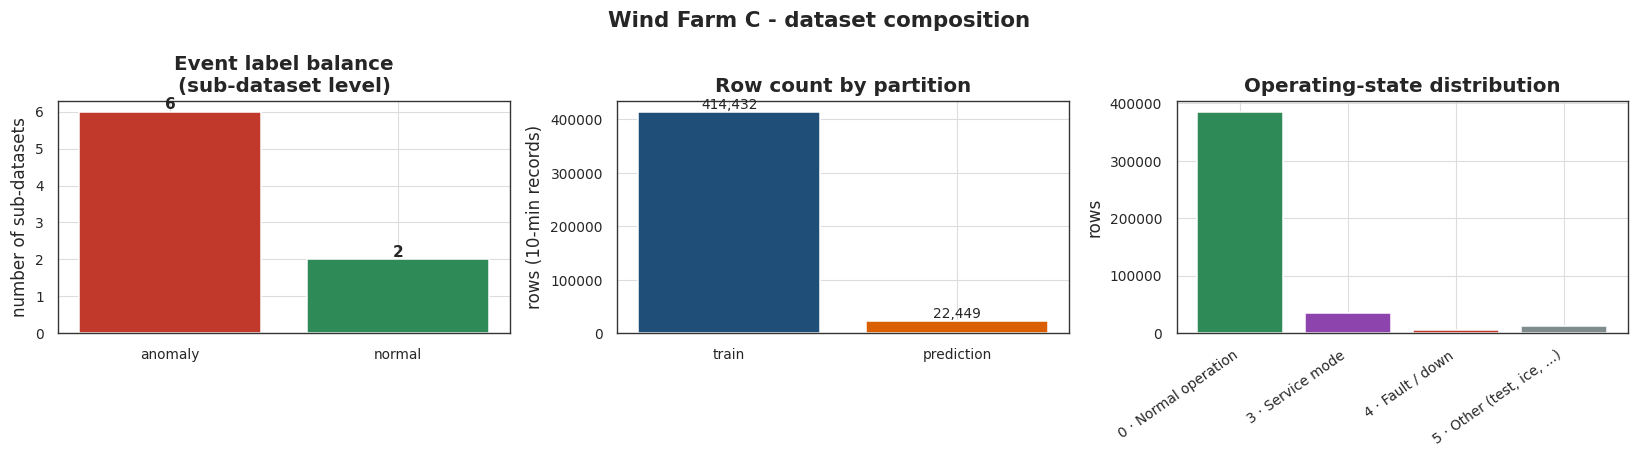

Share of records in a NORMAL operating state (status in (0, 2)): 88.2%


In [63]:
# ---- label and partition balance -------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))

if "event_label" in df.columns and df["event_label"].notna().any():
    lbl = per_dataset["event_label"].value_counts()
    axes[0].bar(lbl.index.astype(str), lbl.to_numpy(),
                color=[PALETTE["warning"] if k == "anomaly" else PALETTE["secondary"]
                       for k in lbl.index])
    for i, v in enumerate(lbl.to_numpy()):
        axes[0].text(i, v, f"{v}", ha="center", va="bottom", fontweight="bold")
    axes[0].set_title("Event label balance\n(sub-dataset level)")
    axes[0].set_ylabel("number of sub-datasets")
else:
    axes[0].text(0.5, 0.5, "No event labels available", ha="center", va="center")
    axes[0].set_axis_off()

split = df[CFG.split_col].value_counts()
axes[1].bar(split.index.astype(str), split.to_numpy(),
            color=[PALETTE["primary"], PALETTE["accent"]][: len(split)])
for i, v in enumerate(split.to_numpy()):
    axes[1].text(i, v, f"{v:,}", ha="center", va="bottom", fontsize=9)
axes[1].set_title("Row count by partition")
axes[1].set_ylabel("rows (10-min records)")

status_counts = df[CFG.status_col].value_counts().sort_index()
axes[2].bar([STATUS_LABELS.get(int(k), str(k)) for k in status_counts.index],
            status_counts.to_numpy(),
            color=[STATUS_COLORS.get(int(k), PALETTE["neutral"]) for k in status_counts.index])
axes[2].set_title("Operating-state distribution")
axes[2].set_ylabel("rows")
axes[2].tick_params(axis="x", rotation=35)
for lab in axes[2].get_xticklabels():
    lab.set_ha("right")

fig.suptitle(f"Wind Farm {CFG.farm_name} - dataset composition", fontsize=14, fontweight="bold")
fig.tight_layout()
save_fig(fig, "04_dataset_composition")
plt.show()

normal_share = df["status_is_normal"].mean()
print(f"Share of records in a NORMAL operating state (status in {CFG.normal_status_ids}): {normal_share:.1%}")

**Reading the figure.**

* *Left* — the benchmark is deliberately balanced at the event level (27 anomaly vs.
  31 normal sub-datasets across the full farm). Any sample loaded via `max_datasets`
  inherits only an approximate balance, so class weighting should be revisited once the
  full farm is loaded.
* *Middle* — the training partition dominates by construction (one full year vs. 4–98
  days of prediction data). A model therefore sees plenty of normal behaviour but very
  little labelled event data: this is a **semi-supervised normal-behaviour-model problem,
  not a supervised classification problem**.
* *Right* — the share of `status_type_id in {0, 2}` is the effective size of the usable
  training set. Anything below roughly two thirds violates the benchmark's own data
  requirement and should be flagged. Note that the benchmark's evaluation protocol
  **discards non-normal-status points from scoring**, so these rows matter for cleaning
  but not for the final metric.

---
## 5. Data Types Inspection

With ~957 columns, the goal is not to look at every dtype but to catch *schema
pathologies*: numeric channels parsed as objects, constant/dead sensors, integer-coded
categoricals, and columns whose cardinality reveals what they really are.

In [64]:
def dtype_profile(df: pd.DataFrame) -> pd.DataFrame:
    # One row per column: dtype, cardinality, null rate, sample value.
    rows = []
    n = len(df)
    for col in df.columns:
        s = df[col]
        nunique = s.nunique(dropna=True)
        rows.append({
            "column": col,
            "dtype": str(s.dtype),
            "n_unique": nunique,
            "unique_ratio": nunique / n if n else np.nan,
            "null_pct": s.isna().mean() * 100,
            "is_constant": nunique <= 1,
            "stat_type": stat_suffix(col),
            "example": s.dropna().iloc[0] if s.notna().any() else None,
        })
    return pd.DataFrame(rows)


dtypes_tbl = dtype_profile(df)
print("Columns per dtype:")
print(dtypes_tbl["dtype"].value_counts().to_string())
print("\nSensor channels per aggregation type:")
print(dtypes_tbl.loc[dtypes_tbl["column"].isin(sensor_columns(df)), "stat_type"]
      .value_counts().to_string())

constant_cols = dtypes_tbl.loc[dtypes_tbl["is_constant"], "column"].tolist()
print(f"\nConstant (zero-variance) columns: {len(constant_cols)}")
print(constant_cols[:20])

Columns per dtype:
dtype
float32           238
int32               6
datetime64[ns]      4
object              3
category            1
int8                1
Int16               1
boolean             1

Sensor channels per aggregation type:
stat_type
avg      238
other      5

Constant (zero-variance) columns: 0
[]


In [65]:
# Columns that *look* numeric but were parsed as object - a classic SCADA export bug.
object_cols = dtypes_tbl.loc[dtypes_tbl["dtype"] == "object", "column"].tolist()
suspicious = []
for col in object_cols:
    if col in {CFG.ts_col, "dataset_id", "event_id", "event_label"}:
        continue
    coerced = pd.to_numeric(df[col], errors="coerce")
    if coerced.notna().mean() > 0.9:
        suspicious.append((col, round(coerced.notna().mean() * 100, 2)))

print("Object columns that are >90% numeric (cast these before modelling):")
print(suspicious if suspicious else "  none - schema is clean")

low_card = (dtypes_tbl.query("n_unique <= 12 and n_unique > 1")
                      .sort_values("n_unique")[["column", "dtype", "n_unique", "example"]])
show(low_card, 15, "\nLow-cardinality columns (candidate categoricals / state flags):")

Object columns that are >90% numeric (cast these before modelling):
  none - schema is clean

Low-cardinality columns (candidate categoricals / state flags):


,column,dtype,n_unique,example
3,train_test,category,2,train
244,status_is_normal,boolean,2,True
246,event_label,object,2,normal
249,year,int32,3,2022
4,status_type_id,Int16,4,0
1,asset_id,int8,6,53
253,day_of_week,int32,7,5
243,dataset_id,object,8,1
247,event_start,datetime64[ns],8,2026-10-01 00:00:00
245,event_id,object,8,1


**Implications.** Constant columns carry zero information and must be dropped before any
distance- or variance-based method (PCA, autoencoder, k-NN) — they also break
standardisation by producing division-by-zero. Low-cardinality integer columns are almost
always *state flags* rather than continuous measurements and should be one-hot encoded or
excluded from the reconstruction target of a normal-behaviour model.

---
## 6. Missing Value Analysis

This is the single most important quality section for Wind Farm C, because
**the operator replaced missing values with `0`**. A plain `isna()` count therefore
*understates* missingness dramatically. The analysis runs on two levels:

1. **Explicit missingness** — `NaN` counts per column and per sub-dataset.
2. **Implicit missingness** — runs of consecutive zeros longer than
   `CFG.zero_run_threshold` (default 1 hour) in channels that should not physically be
   zero for that long.

### 6.1 Explicit `NaN` analysis

In [66]:
def missing_report(df: pd.DataFrame, columns: Optional[Sequence[str]] = None) -> pd.DataFrame:
    cols = list(columns) if columns is not None else df.columns.tolist()
    miss = df[cols].isna().sum()
    out = (pd.DataFrame({"n_missing": miss,
                         "pct_missing": miss / len(df) * 100})
             .sort_values("pct_missing", ascending=False))
    return out[out["n_missing"] > 0]


sensor_cols = sensor_columns(df)
nan_tbl = missing_report(df, sensor_cols)
print(f"Sensor channels with at least one NaN: {len(nan_tbl)} / {len(sensor_cols)}")
print(f"Overall NaN rate across sensor channels: "
      f"{df[sensor_cols].isna().to_numpy().mean() * 100:.3f}%")
show(nan_tbl, 15)

Sensor channels with at least one NaN: 0 / 243
Overall NaN rate across sensor channels: 0.000%


,n_missing,pct_missing


### 6.2 Implicit missingness — consecutive-zero runs

In [67]:
def longest_zero_run(s: pd.Series) -> int:
    # Length of the longest run of exact zeros in a series.
    is_zero = (s == 0).to_numpy()
    if not is_zero.any():
        return 0
    # run-length encode the boolean mask
    idx = np.flatnonzero(np.diff(np.concatenate(([0], is_zero.view(np.int8), [0]))))
    starts, ends = idx[::2], idx[1::2]
    return int((ends - starts).max())


def zero_run_report(df: pd.DataFrame, columns: Sequence[str],
                    cfg: EDAConfig = CFG) -> pd.DataFrame:
    # Per-channel zero statistics, treating long zero runs as hidden missing data.
    rows = []
    for col in columns:
        s = df[col]
        zero_share = float((s == 0).mean())
        run = longest_zero_run(s)
        rows.append({
            "column": col,
            "zero_pct": zero_share * 100,
            "longest_zero_run": run,
            "longest_zero_hours": run / 6.0,
            "suspect_hidden_missing": run >= cfg.zero_run_threshold and zero_share > 0.001,
        })
    return (pd.DataFrame(rows)
              .sort_values(["suspect_hidden_missing", "zero_pct"], ascending=[False, False]))


zero_tbl = zero_run_report(df, sensor_cols)
n_suspect = int(zero_tbl["suspect_hidden_missing"].sum())
print(f"Channels with zero-runs >= {CFG.zero_run_threshold} samples "
      f"({CFG.zero_run_threshold / 6:.1f} h): {n_suspect} / {len(sensor_cols)}")
show(zero_tbl, 15)

Channels with zero-runs >= 6 samples (1.0 h): 240 / 243


,column,zero_pct,longest_zero_run,longest_zero_hours,suspect_hidden_missing
22,sensor_22_avg,97.3769,60740,"10,123.3333",True
3,sensor_3_avg,93.2874,270768,"45,128.0000",True
142,sensor_142_avg,93.2874,270768,"45,128.0000",True
95,sensor_95_avg,83.0414,50661,"8,443.5000",True
10,sensor_10_avg,77.4611,1287,214.5000,True
83,sensor_83_avg,75.0756,2599,433.1667,True
81,sensor_81_avg,74.1426,49993,"8,332.1667",True
86,sensor_86_avg,73.4568,3307,551.1667,True
84,sensor_84_avg,73.3108,2039,339.8333,True
9,sensor_9_avg,73.0753,1275,212.5000,True


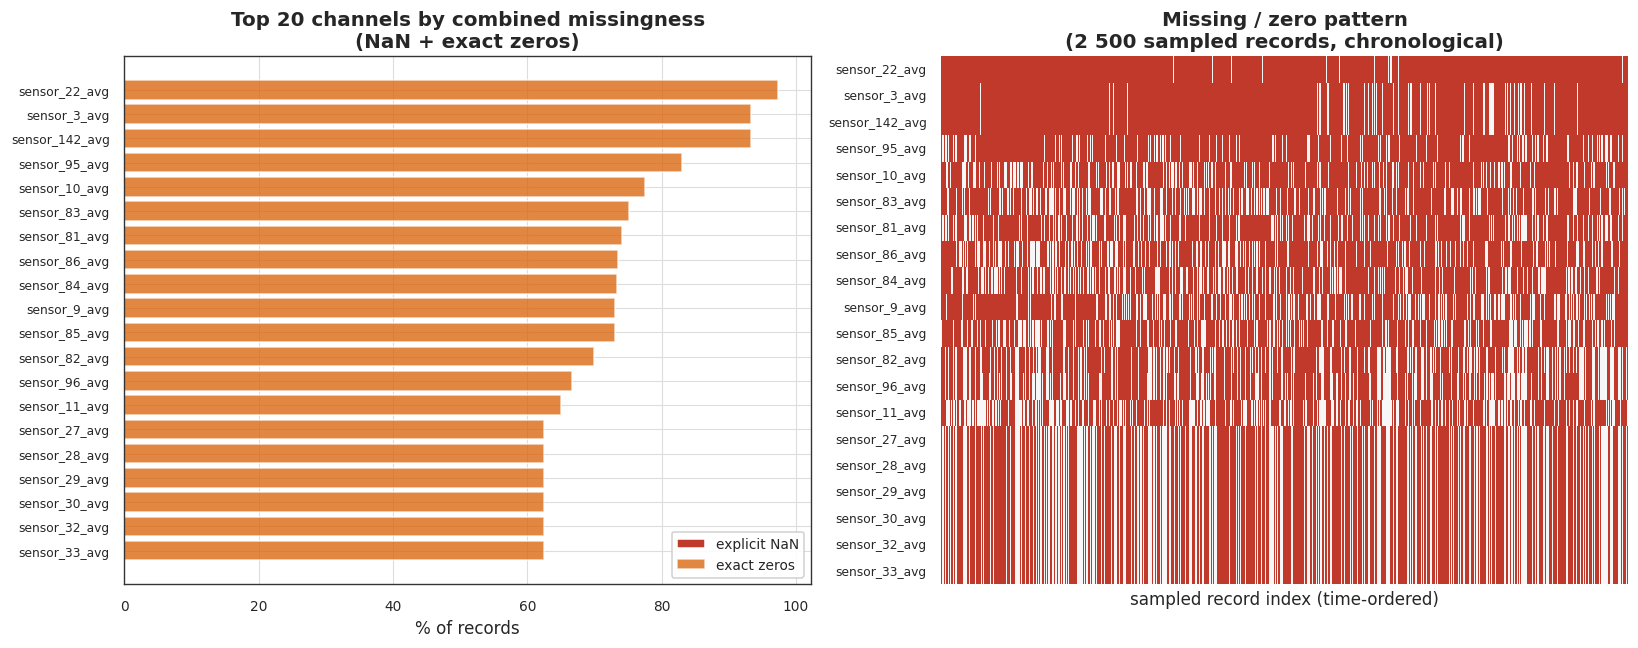

In [68]:
# ---- combined missingness view ------------------------------------------------
top_missing = (zero_tbl.set_index("column")
                       .assign(nan_pct=nan_tbl["pct_missing"])
                       .fillna({"nan_pct": 0.0})
                       .assign(effective_missing_pct=lambda d: d["nan_pct"] + d["zero_pct"])
                       .sort_values("effective_missing_pct", ascending=False)
                       .head(20))

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

y = np.arange(len(top_missing))
axes[0].barh(y, top_missing["nan_pct"], color=PALETTE["warning"], label="explicit NaN")
axes[0].barh(y, top_missing["zero_pct"], left=top_missing["nan_pct"],
             color=PALETTE["accent"], alpha=0.75, label="exact zeros")
axes[0].set_yticks(y)
axes[0].set_yticklabels(top_missing.index, fontsize=8)
axes[0].invert_yaxis()
axes[0].set_xlabel("% of records")
axes[0].set_title("Top 20 channels by combined missingness\n(NaN + exact zeros)")
axes[0].legend(loc="lower right")

# nullity matrix: sampled rows x top channels, black = missing-or-zero
sample = df.sample(min(2500, len(df)), random_state=RANDOM_SEED).sort_values(CFG.ts_col)
mat = (sample[top_missing.index].isna() | (sample[top_missing.index] == 0)).astype(int)
sns.heatmap(mat.T, cmap=["#f7f7f7", PALETTE["warning"]], cbar=False, ax=axes[1])
axes[1].set_title("Missing / zero pattern\n(2 500 sampled records, chronological)")
axes[1].set_xlabel("sampled record index (time-ordered)")
axes[1].set_ylabel("")
axes[1].set_xticks([])
axes[1].tick_params(axis="y", labelsize=8)

fig.tight_layout()
save_fig(fig, "06_missingness")
plt.show()

In [69]:
# ---- missingness per sub-dataset: is the problem global or turbine-specific? ----
per_ds_missing = (df.groupby("dataset_id")[sensor_cols]
                    .apply(lambda g: float((g.isna() | (g == 0)).to_numpy().mean() * 100))
                    .rename("missing_or_zero_pct")
                    .sort_values(ascending=False)
                    .to_frame())
per_ds_missing

,missing_or_zero_pct
dataset_id,
15,12.2117
11,11.6299
28,11.2735
18,11.2225
16,11.2131
1,10.7141
20,10.5084
12,9.4180


**Interpretation and downstream impact.**

* Vertical stripes in the nullity matrix mean *whole-system outages* (the data logger went
  down) — every channel is unusable for that period, so those rows should be dropped.
* Horizontal stripes mean *individual sensor failures* — the row is still usable for other
  channels, which favours imputation or a model tolerant of missing inputs.
* Because zeros are ambiguous, the recommended cleaning rule for Wind Farm C is:
  **treat a zero as missing when it belongs to a run of ≥ 1 h in a channel that is not
  physically expected to sit at zero** (temperatures, rotational speeds, pressures).
  Power and wind speed are legitimately zero when the turbine is idle, so they need the
  cross-check in Section 18 instead.
* **Do not forward-fill across long gaps.** In a 10-min NBM, forward-filling a 6-hour hole
  fabricates 36 records of "perfectly healthy" behaviour and directly suppresses the
  anomaly score the model is supposed to raise.

---
## 7. Duplicate Detection

Three distinct kinds of duplication matter for SCADA data, and they have different causes
and different fixes:

| Kind | Cause | Fix |
|---|---|---|
| Identical full rows | export/concatenation artefact | drop |
| Repeated `(asset_id, timestamp)` keys | logger restart, DST/clock issue | keep last, or investigate |
| Duplicated *columns* | redundant sensor tags in the SCADA tag list | drop one, keep the mapping |

In [70]:
def duplicate_report(df: pd.DataFrame, cfg: EDAConfig = CFG) -> Dict[str, object]:
    key = ["dataset_id", cfg.asset_col, cfg.ts_col]
    full_dupes = df.duplicated(keep="first")
    key_dupes = df.duplicated(subset=key, keep="first")
    return {
        "n_full_row_duplicates": int(full_dupes.sum()),
        "pct_full_row_duplicates": float(full_dupes.mean() * 100),
        "n_duplicate_keys": int(key_dupes.sum()),
        "pct_duplicate_keys": float(key_dupes.mean() * 100),
        "duplicate_key_rows": df.loc[key_dupes, key].head(10),
    }


dup = duplicate_report(df)
print(f"Exact duplicate rows          : {dup['n_full_row_duplicates']:,} "
      f"({dup['pct_full_row_duplicates']:.4f}%)")
print(f"Duplicate (dataset, asset, ts): {dup['n_duplicate_keys']:,} "
      f"({dup['pct_duplicate_keys']:.4f}%)")
dup["duplicate_key_rows"]

Exact duplicate rows          : 0 (0.0000%)
Duplicate (dataset, asset, ts): 0 (0.0000%)


,dataset_id,asset_id,time_stamp


In [71]:
def duplicate_columns(df: pd.DataFrame, columns: Sequence[str],
                      sample_rows: int = 5000) -> List[Tuple[str, str]]:
    # Detect columns with byte-identical content (hashing a sample first for speed).
    sample = df[list(columns)].head(sample_rows)
    buckets: Dict[str, List[str]] = {}
    for col in columns:
        h = pd.util.hash_pandas_object(sample[col].fillna(-9.99e18), index=False).sum()
        buckets.setdefault(str(h), []).append(col)
    pairs = []
    for group in buckets.values():
        if len(group) > 1:
            ref = group[0]
            for other in group[1:]:
                if df[ref].equals(df[other]):
                    pairs.append((ref, other))
    return pairs


dup_cols = duplicate_columns(df, sensor_cols)
print(f"Byte-identical sensor column pairs: {len(dup_cols)}")
for a, b in dup_cols[:15]:
    print(f"  {a}  ==  {b}")

# de-duplicate rows for the remainder of the notebook (columns are kept for transparency)
df_clean = df.drop_duplicates(subset=["dataset_id", CFG.asset_col, CFG.ts_col],
                              keep="last").reset_index(drop=True)
print(f"\nRows before / after key de-duplication: {len(df):,} -> {len(df_clean):,}")

Byte-identical sensor column pairs: 1
  sensor_206_avg  ==  sensor_207_avg

Rows before / after key de-duplication: 436,881 -> 436,881


**Implication.** Duplicate `(asset, timestamp)` keys silently corrupt any `resample()`,
`rolling()` or `shift()` operation because pandas will happily aggregate two records into
one bin. De-duplication must therefore happen **before** any temporal feature engineering,
not after. Duplicate *columns* inflate the apparent dimensionality and, in a
correlation-based feature selection step, will always be selected together — wasting model
capacity on the same physical signal.

---
## 8. Timestamp Validation

Everything downstream — resampling, rolling windows, lag features, event alignment —
assumes a clean, monotonic, regularly spaced time index. This section verifies that
assumption explicitly rather than trusting it.

In [72]:
def timestamp_validation(df: pd.DataFrame, cfg: EDAConfig = CFG) -> pd.DataFrame:
    # Per sub-dataset timestamp integrity checks.
    expected = pd.Timedelta(cfg.expected_freq)
    rows = []
    for did, g in df.groupby("dataset_id"):
        ts = g[cfg.ts_col]
        deltas = ts.diff().dropna()
        on_grid = ts.sub(ts.dt.floor(cfg.expected_freq)).eq(pd.Timedelta(0))
        rows.append({
            "dataset_id": did,
            "n_rows": len(g),
            "n_unparsed": int(ts.isna().sum()),
            "monotonic_increasing": bool(ts.is_monotonic_increasing),
            "n_non_positive_delta": int((deltas <= pd.Timedelta(0)).sum()),
            "modal_delta": str(deltas.mode().iloc[0]) if not deltas.empty else "n/a",
            "pct_on_10min_grid": float(on_grid.mean() * 100),
            "start": ts.min(),
            "end": ts.max(),
            "timezone_aware": ts.dt.tz is not None,
        })
    return pd.DataFrame(rows)


ts_valid = timestamp_validation(df_clean)
ts_valid

,dataset_id,n_rows,n_unparsed,monotonic_increasing,n_non_positive_delta,modal_delta,pct_on_10min_grid,start,end,timezone_aware
0,1,53569,0,True,0,0 days 00:10:00,100.0000,2022-10-01 00:00:00,2023-10-16 00:00:00,False
1,11,56437,0,True,0,0 days 00:10:00,100.0000,2022-10-17 12:30:00,2023-11-14 10:30:00,False
2,12,56107,0,True,0,0 days 00:10:00,100.0000,2022-06-27 00:00:00,2023-07-21 15:00:00,False
3,15,54433,0,True,0,0 days 00:10:00,100.0000,2022-02-04 00:00:00,2023-02-23 00:00:00,False
4,16,53568,0,True,0,0 days 00:10:00,100.0000,2022-12-23 00:00:00,2024-01-07 23:50:00,False
5,18,52848,0,True,0,0 days 00:10:00,100.0000,2022-09-11 00:00:00,2023-09-22 23:50:00,False
6,20,54001,0,True,0,0 days 00:10:00,100.0000,2022-07-12 01:10:00,2023-07-30 01:10:00,False
7,28,55918,0,True,0,0 days 00:10:00,100.0000,2022-05-27 13:00:00,2023-06-19 20:30:00,False


In [73]:
issues = []
if ts_valid["n_unparsed"].sum():
    issues.append(f"{int(ts_valid['n_unparsed'].sum())} timestamps failed to parse")
if not ts_valid["monotonic_increasing"].all():
    bad = ts_valid.loc[~ts_valid["monotonic_increasing"], "dataset_id"].tolist()
    issues.append(f"non-monotonic timestamps in datasets {bad}")
if (ts_valid["pct_on_10min_grid"] < 99.9).any():
    issues.append("some timestamps are off the 10-minute grid (clock drift or DST)")
if ts_valid["timezone_aware"].nunique() > 1:
    issues.append("mixed timezone-aware and naive timestamps")

print("TIMESTAMP VALIDATION")
print("-" * 40)
print("PASS - no timestamp integrity issues detected" if not issues
      else "\n".join(f"FAIL - {i}" for i in issues))
print(f"\nAll sub-datasets start in {sorted(ts_valid['start'].dt.year.unique())} "
      "(consistent with the benchmark's year-shift anonymisation).")

TIMESTAMP VALIDATION
----------------------------------------
PASS - no timestamp integrity issues detected

All sub-datasets start in [np.int32(2022)] (consistent with the benchmark's year-shift anonymisation).


**Note on the shifted years.** The benchmark deliberately shifts every sub-dataset so that
it starts in 2022. Seasonality (month, day-of-year) is preserved and remains a valid
feature; **absolute chronology across sub-datasets is meaningless**, so the datasets must
never be concatenated into one long global series, and any cross-dataset train/test split
must be made *by dataset*, not by calendar date.

---
## 9. Time-Series Consistency Checks

Beyond parseable timestamps, a usable time series needs *regularity*: expected sampling
interval, no large holes, and no frozen sensors quietly reporting the last good value.

### 9.1 Sampling interval and gap analysis

In [74]:
def gap_analysis(df: pd.DataFrame, cfg: EDAConfig = CFG) -> Tuple[pd.DataFrame, pd.Series]:
    # Quantify holes in each sub-dataset relative to a perfect 10-minute grid.
    expected = pd.Timedelta(cfg.expected_freq)
    summaries, all_deltas = [], []
    for did, g in df.groupby("dataset_id"):
        ts = g[cfg.ts_col].sort_values()
        deltas = ts.diff().dropna()
        all_deltas.append(deltas)
        gaps = deltas[deltas > expected]
        span = ts.max() - ts.min()
        expected_rows = int(span / expected) + 1
        summaries.append({
            "dataset_id": did,
            "expected_rows": expected_rows,
            "actual_rows": len(g),
            "completeness_pct": len(g) / expected_rows * 100 if expected_rows else np.nan,
            "n_gaps": int(len(gaps)),
            "missing_samples": int(((gaps - expected) / expected).sum()),
            "largest_gap": str(gaps.max()) if len(gaps) else "0",
        })
    return pd.DataFrame(summaries), pd.concat(all_deltas)


gap_tbl, deltas_all = gap_analysis(df_clean)
gap_tbl.sort_values("completeness_pct")

,dataset_id,expected_rows,actual_rows,completeness_pct,n_gaps,missing_samples,largest_gap
5,18,54288,52848,97.3475,1,1440,10 days 00:10:00
4,16,54864,53568,97.6378,3,1296,5 days 00:10:00
0,1,54721,53569,97.8948,2,1152,5 days 00:10:00
6,20,55153,54001,97.9113,2,1152,5 days 00:10:00
3,15,55297,54433,98.4375,2,864,4 days 00:10:00
1,11,56581,56437,99.7455,1,144,1 days 00:10:00
2,12,56107,56107,100.0000,0,0,0
7,28,55918,55918,100.0000,0,0,0


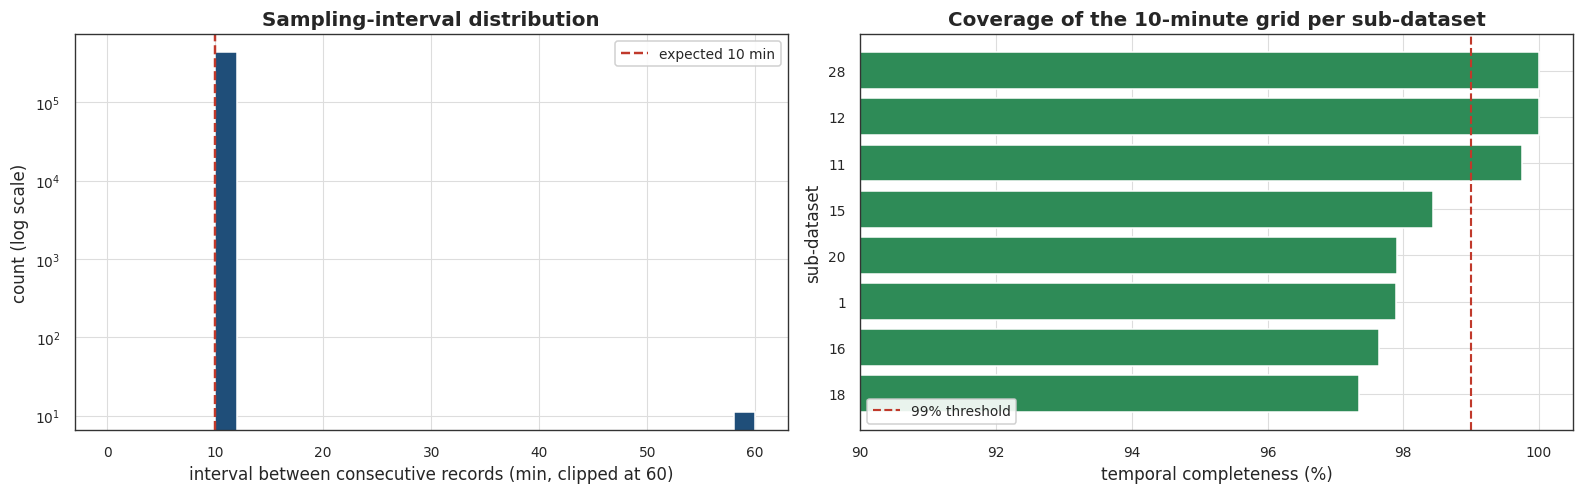

In [75]:
fig, axes = plt.subplots(1, 2, figsize=(14.5, 4.6))

minutes = deltas_all.dt.total_seconds() / 60
bins = np.arange(0, 61, 2)
axes[0].hist(np.clip(minutes, 0, 60), bins=bins, color=PALETTE["primary"], edgecolor="white")
axes[0].axvline(10, color=PALETTE["warning"], ls="--", lw=1.6, label="expected 10 min")
axes[0].set_yscale("log")
axes[0].set_xlabel("interval between consecutive records (min, clipped at 60)")
axes[0].set_ylabel("count (log scale)")
axes[0].set_title("Sampling-interval distribution")
axes[0].legend()

order = gap_tbl.sort_values("completeness_pct")
axes[1].barh(order["dataset_id"].astype(str), order["completeness_pct"],
             color=PALETTE["secondary"])
axes[1].axvline(99, color=PALETTE["warning"], ls="--", lw=1.4, label="99% threshold")
axes[1].set_xlim(min(90, order["completeness_pct"].min() - 1), 100.5)
axes[1].set_xlabel("temporal completeness (%)")
axes[1].set_ylabel("sub-dataset")
axes[1].set_title("Coverage of the 10-minute grid per sub-dataset")
axes[1].legend(loc="lower left")

fig.tight_layout()
save_fig(fig, "09_temporal_consistency")
plt.show()

### 9.2 Frozen (stuck) sensor detection

In [76]:
def flatline_report(df: pd.DataFrame, columns: Sequence[str],
                    cfg: EDAConfig = CFG) -> pd.DataFrame:
    # Longest run of an identical NON-ZERO value per channel: a classic stuck-sensor signature.
    rows = []
    for col in columns:
        s = df[col]
        changed = s.ne(s.shift()).cumsum()
        runs = s.groupby(changed).agg(["size", "first"])
        runs = runs[(runs["first"] != 0) & runs["first"].notna()]
        longest = int(runs["size"].max()) if len(runs) else 0
        rows.append({"column": col,
                     "longest_flat_run": longest,
                     "longest_flat_hours": longest / 6.0,
                     "is_frozen_suspect": longest >= cfg.flatline_threshold})
    return pd.DataFrame(rows).sort_values("longest_flat_run", ascending=False)


flat_tbl = flatline_report(df_clean, sensor_cols)
n_frozen = int(flat_tbl["is_frozen_suspect"].sum())
print(f"Channels with a constant non-zero value for >= {CFG.flatline_threshold} samples "
      f"({CFG.flatline_threshold / 6:.0f} h): {n_frozen}")
show(flat_tbl, 12)

Channels with a constant non-zero value for >= 18 samples (3 h): 209


,column,longest_flat_run,longest_flat_hours,is_frozen_suspect
238,year,51264,"8,544.0000",True
213,sensor_213_avg,37639,"6,273.1667",True
45,sensor_45_avg,37639,"6,273.1667",True
98,sensor_98_avg,36966,"6,161.0000",True
147,sensor_147_avg,32579,"5,429.8333",True
146,sensor_146_avg,32485,"5,414.1667",True
225,sensor_225_avg,31502,"5,250.3333",True
212,sensor_212_avg,28865,"4,810.8333",True
125,sensor_125_avg,25672,"4,278.6667",True
236,wind_speed_235_avg,25672,"4,278.6667",True


**Why frozen sensors are dangerous for predictive maintenance (§9.2).** A stuck channel has *zero*
variance over its frozen window, so a reconstruction-based model (autoencoder, regression
NBM) learns to predict it perfectly and its residual collapses to zero. The model then
reports unusually *healthy* behaviour precisely when the instrumentation has failed —
the worst possible failure mode for a monitoring system. Frozen windows should be masked
out of both training and scoring, and the freeze itself should raise a **data-quality
alarm**, distinct from a **machine-health alarm**.

### 9.3 Min / Max / Avg / Std plausibility audit

The dataset's *Known Data Issues* notice states that the per-timestamp Min/Max/Std
statistics were passed through as-is by the operator and are frequently implausible. Four
issue types are documented:

| Issue | Test |
|---|---|
| 1 | `std` exceeds the maximum possible standard deviation given `min`, `max`, `avg` |
| 2 | `min > avg` |
| 3 | `max < avg` |
| 4 | `min`, `max` and `std` are identically zero for every record of a feature |

For Wind Farm C the notice names **17 sensors affected in ~20–30% of records**, a further
**90 in ~10–15%**, and **131 below 5%** — while stating that the `*_avg` channels are
generally plausible. This audit reproduces those checks on the data actually loaded, so the
decision to work `avg`-only is evidenced rather than assumed.

For issue 1 the bound used is the maximum standard deviation of any distribution supported
on `[min, max]` with mean `avg`, namely `sqrt((avg - min) * (max - avg))`.

In [77]:
def minmaxstd_audit(frame: pd.DataFrame) -> pd.DataFrame:
    # Reproduce the four documented Min/Max/Std issue types, per physical sensor.
    if frame is None or frame.empty:
        return pd.DataFrame()
    stems = sorted({base_sensor(c) for c in frame.columns
                    if re.search(r"_(avg|min|max|std)$", str(c))})
    rows = []
    for stem in stems:
        cols = {suf: f"{stem}_{suf}" for suf in ("avg", "min", "max", "std")}
        if not all(c in frame.columns for c in cols.values()):
            continue
        avg, lo, hi, sd = (pd.to_numeric(frame[cols[k]], errors="coerce")
                           for k in ("avg", "min", "max", "std"))
        valid = avg.notna() & lo.notna() & hi.notna() & sd.notna()
        n = int(valid.sum())
        if n == 0:
            continue
        max_possible_sd = np.sqrt(np.clip((avg - lo) * (hi - avg), 0, None))
        issue1 = (sd > max_possible_sd * 1.001) & valid
        issue2 = (lo > avg) & valid
        issue3 = (hi < avg) & valid
        issue4 = bool(((lo == 0) & (hi == 0) & (sd == 0)).loc[valid].all())
        any_issue = (issue1 | issue2 | issue3)
        rows.append({
            "sensor": stem,
            "n_valid": n,
            "issue1_impossible_std_pct": issue1.sum() / n * 100,
            "issue2_min_gt_avg_pct": issue2.sum() / n * 100,
            "issue3_max_lt_avg_pct": issue3.sum() / n * 100,
            "issue4_all_zero_stats": issue4,
            "any_issue_pct": any_issue.sum() / n * 100,
        })
    out = pd.DataFrame(rows)
    if out.empty:
        return out
    out["contamination"] = pd.cut(out["any_issue_pct"], [-0.01, 5, 15, 30, 101],
                                  labels=["low (<5%)", "medium (5-15%)",
                                          "high (15-30%)", "severe (>30%)"])
    return out.sort_values("any_issue_pct", ascending=False)


stats_audit = minmaxstd_audit(STATS_SAMPLE)
if stats_audit.empty:
    print("No sensor exposes a complete avg/min/max/std quadruplet in the sample - "
          "audit skipped.")
else:
    print(f"Sensors with a full avg/min/max/std quadruplet: {len(stats_audit)}")
    print("\nContamination levels (share of records failing issues 1-3):")
    print(stats_audit["contamination"].value_counts().sort_index().to_string())
    print(f"\nSensors with all-zero min/max/std (issue 4): "
          f"{int(stats_audit['issue4_all_zero_stats'].sum())}")
    show(stats_audit.drop(columns=["contamination"]), 12, "\nWorst-affected sensors:")

Sensors with a full avg/min/max/std quadruplet: 238

Contamination levels (share of records failing issues 1-3):
contamination
low (<5%)         148
medium (5-15%)     57
high (15-30%)      31
severe (>30%)       2

Sensors with all-zero min/max/std (issue 4): 2

Worst-affected sensors:


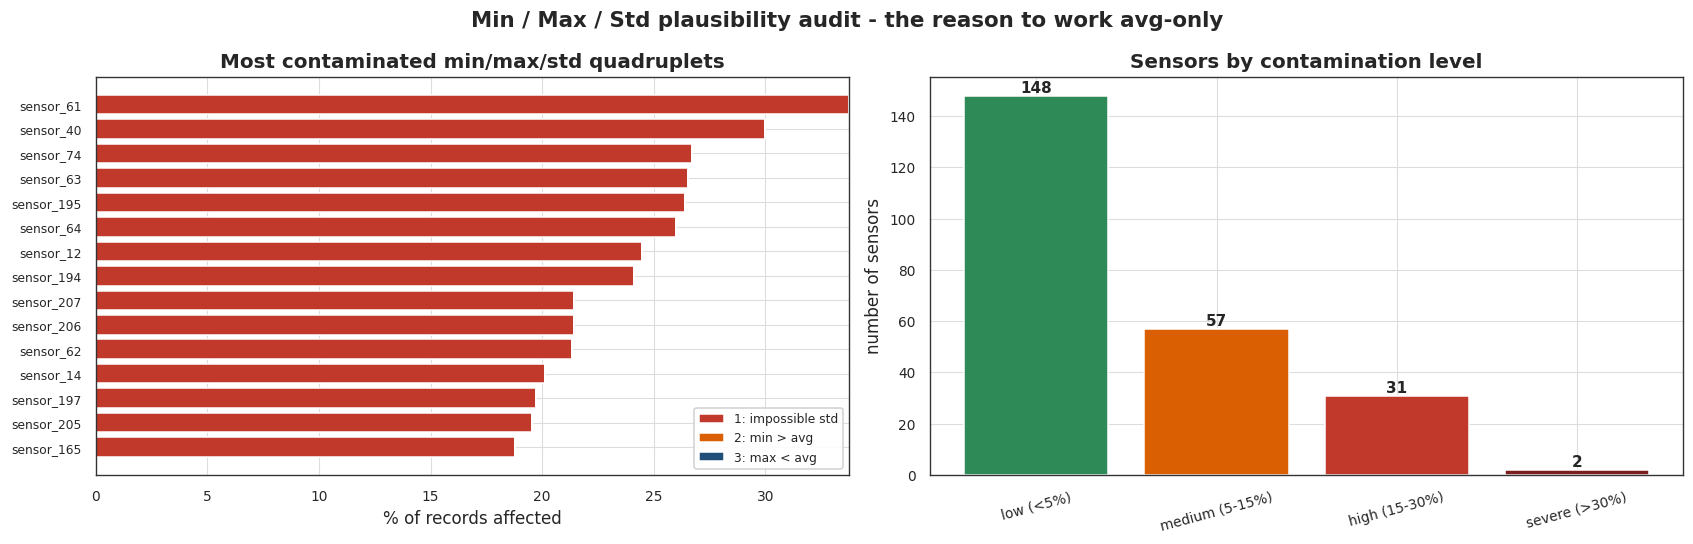

In [78]:
if not stats_audit.empty:
    fig, axes = plt.subplots(1, 2, figsize=(15.5, 5))

    issue_cols = ["issue1_impossible_std_pct", "issue2_min_gt_avg_pct",
                  "issue3_max_lt_avg_pct"]
    labels = ["1: impossible std", "2: min > avg", "3: max < avg"]
    top = stats_audit.head(15).iloc[::-1]
    left = np.zeros(len(top))
    for col, lab, colour in zip(issue_cols, labels,
                                [PALETTE["warning"], PALETTE["accent"], PALETTE["primary"]]):
        axes[0].barh(top["sensor"], top[col], left=left, color=colour, label=lab)
        left = left + top[col].to_numpy()
    axes[0].set_xlabel("% of records affected")
    axes[0].set_title("Most contaminated min/max/std quadruplets")
    axes[0].tick_params(axis="y", labelsize=8)
    axes[0].legend(fontsize=8, loc="lower right")

    counts = stats_audit["contamination"].value_counts().sort_index()
    axes[1].bar(counts.index.astype(str), counts.to_numpy(),
                color=[PALETTE["secondary"], PALETTE["accent"],
                       PALETTE["warning"], "#7b1e1e"][: len(counts)])
    for i, v in enumerate(counts.to_numpy()):
        axes[1].text(i, v, str(v), ha="center", va="bottom", fontweight="bold")
    axes[1].set_ylabel("number of sensors")
    axes[1].set_title("Sensors by contamination level")
    axes[1].tick_params(axis="x", rotation=15)

    fig.suptitle("Min / Max / Std plausibility audit - the reason to work avg-only",
                 fontsize=14, fontweight="bold")
    fig.tight_layout()
    save_fig(fig, "09_minmaxstd_audit")
    plt.show()

**Consequence.** The contamination is structural, not incidental: it comes from how the
operator's historian aggregated each 10-minute window, so it cannot be repaired by
cleaning. Two practical rules follow, and both are already the notebook's defaults:

* **Work `avg`-only** (`CFG.avg_only = True`). This is the dataset authors' own
  recommendation, and it happens to solve the dimensionality problem at the same time —
  957 columns collapse to roughly 243.
* **If a min/max/std channel is needed** (for a turbulence or gust feature, say), validate
  that specific quadruplet first with the audit above and mask the failing records. Do not
  assume a low farm-wide contamination rate applies to the sensor you happen to want.

Note also that a derived feature inherits its inputs' defects: a gust factor built from a
contaminated `*_max` is contaminated, and it will look like a physical anomaly.

---
## 10. Descriptive Statistics

Two analysis frames are defined here and reused for the rest of the notebook:

* **`df_clean`** — all records, de-duplicated. Used for data-quality work.
* **`df_norm`** — records in a normal operating state (`status_type_id ∈ {0, 2}`) *and*
  in the training partition. This is the population a normal-behaviour model is trained
  on, so it is the correct reference for distributions, correlations and the power curve.

A curated **analysis feature set** keeps the wide-data sections readable: the three named
physical channels plus the highest-variance unnamed sensors.

In [79]:
# ---- analysis frames ---------------------------------------------------------
mask_norm = df_clean["status_is_normal"].fillna(False)
if CFG.split_col in df_clean.columns:
    mask_norm &= df_clean[CFG.split_col].astype(str).eq("train")
df_norm = df_clean.loc[mask_norm].copy()

print(f"df_clean : {len(df_clean):,} rows  (all records, de-duplicated)")
print(f"df_norm  : {len(df_norm):,} rows  ({len(df_norm) / len(df_clean):.1%} of total) "
      "- normal status, training partition")


def select_analysis_features(df: pd.DataFrame, k: int = 14) -> List[str]:
    # Named physical channels + the k most informative unnamed *_avg sensors.
    named = [c for c in (POWER, WIND, REACTIVE, CORE.get("wind_speed_std")) if c]
    avg_cols = [c for c in sensor_columns(df)
                if stat_suffix(c) == "avg" and c not in named]
    # rank by coefficient of variation -> favours channels that actually move
    stats_tbl = df[avg_cols].agg(["std", "mean"]).T
    stats_tbl["cv"] = stats_tbl["std"] / stats_tbl["mean"].abs().replace(0, np.nan)
    ranked = stats_tbl.replace([np.inf, -np.inf], np.nan).dropna().sort_values("cv", ascending=False)
    return named + ranked.head(k).index.tolist()


ANALYSIS_FEATURES = select_analysis_features(df_norm)
print(f"\nAnalysis feature set ({len(ANALYSIS_FEATURES)} channels):")
print(", ".join(ANALYSIS_FEATURES))

df_clean : 436,881 rows  (all records, de-duplicated)
df_norm  : 368,614 rows  (84.4% of total) - normal status, training partition

Analysis feature set (17 channels):
power_5_avg, wind_speed_236_avg, reactive_power_122_avg, sensor_126_avg, sensor_124_avg, sensor_1_avg, sensor_16_avg, sensor_12_avg, sensor_150_avg, sensor_148_avg, sensor_149_avg, sensor_125_avg, sensor_48_avg, sensor_22_avg, sensor_10_avg, sensor_3_avg, sensor_142_avg


In [80]:
def descriptive_stats(df: pd.DataFrame, columns: Sequence[str]) -> pd.DataFrame:
    # describe() extended with the shape statistics that matter for model choice.
    sub = df[list(columns)]
    out = sub.describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).T
    out["iqr"] = out["75%"] - out["25%"]
    out["cv"] = out["std"] / out["mean"].abs().replace(0, np.nan)
    out["skew"] = sub.skew()
    out["kurtosis"] = sub.kurtosis()
    out["zero_pct"] = (sub == 0).mean() * 100
    out["missing_pct"] = sub.isna().mean() * 100
    return out


desc_norm = descriptive_stats(df_norm, ANALYSIS_FEATURES)
desc_norm[["count", "mean", "std", "min", "5%", "50%", "95%", "max",
           "iqr", "cv", "skew", "kurtosis", "zero_pct", "missing_pct"]]

,count,mean,std,min,5%,50%,95%,max,iqr,cv,skew,kurtosis,zero_pct,missing_pct
power_5_avg,"368,614.0000",0.3471,0.3048,-0.0097,-0.0034,0.2739,0.9971,1.0442,0.4823,0.8782,0.6796,-0.6440,0.1438,0.0000
wind_speed_236_avg,"368,614.0000",7.7593,4.1895,-3.3270,2.3990,6.8600,16.0790,31.3790,5.0100,0.5399,0.9653,0.8285,0.0076,0.0000
reactive_power_122_avg,"368,614.0000",0.0246,0.0362,-0.3754,-0.0178,0.0170,0.0968,0.4351,0.0437,1.4712,0.5240,2.3552,0.6733,0.0000
sensor_126_avg,"368,614.0000",-0.3627,36.9740,-165.6000,-17.3033,-6.9770,55.8870,180.0000,7.6210,101.9509,3.3060,13.7547,0.0076,0.0000
sensor_124_avg,"368,614.0000",-0.2027,17.4833,-167.4200,-7.6260,0.0900,7.6720,164.0900,5.9360,86.2519,-0.7872,36.1894,0.0100,0.0000
sensor_1_avg,"368,614.0000",-0.0005,0.0184,-0.2501,-0.0278,0.0000,0.0266,0.2337,0.0073,37.8543,-1.5844,30.5155,4.8728,0.0000
sensor_16_avg,"368,614.0000",-0.1229,4.3136,-8.0000,-8.0000,3.4270,3.4270,3.4270,4.9970,35.0988,-0.7989,-0.9419,0.7428,0.0000
sensor_12_avg,"368,614.0000",-0.0164,0.4709,-0.9940,-0.5375,-0.0808,1.1560,1.5540,0.3447,28.7875,1.0823,0.7695,8.4755,0.0000
sensor_150_avg,"368,614.0000",0.1475,2.9145,-46.9010,-1.8440,0.0000,1.9260,62.7910,0.2373,19.7541,9.6011,134.1745,7.5876,0.0000
sensor_148_avg,"368,614.0000",0.1594,2.9306,-46.7170,-1.8680,0.0000,1.9700,59.0400,0.2131,18.3907,9.5903,134.4303,6.2209,0.0000


In [81]:
# ---- how much do the statistics shift between operating states? ---------------
by_status = (df_clean.groupby(CFG.status_col, observed=True)[[POWER, WIND]]
                     .agg(["count", "mean", "std", "median"]))
by_status.index = [STATUS_LABELS.get(int(i), str(i)) for i in by_status.index]
by_status

power_5_avg                       wind_speed_236_avg                     
                                 count   mean    std  median              count   mean    std median
0 · Normal operation            385307 0.3463 0.3048  0.2723             385307 7.7404 4.1739 6.8480
3 · Service mode                 34423 0.0036 0.0377 -0.0001              34423 8.1803 4.8355 7.4720
4 · Fault / down                  4720 0.1457 0.2634 -0.0000               4720 8.4398 4.5681 8.6540
5 · Other (test, ice, ...)       12431 0.1274 0.2219  0.0000              12431 6.2777 4.9903 5.3350

**What to take from the tables.**

* **Scale heterogeneity** — power is normalised to `[0, 1]` while temperatures are tens of
  degrees and speeds are hundreds of rpm. Any distance-based or gradient-based model needs
  per-feature standardisation, fitted **on the training partition only**.
* **Skew and kurtosis** — wind speed is right-skewed (Weibull-like) and power is strongly
  bimodal (a mass at zero plus a mass at rated). Neither is Gaussian, so Z-score outlier
  rules (Section 17) will misbehave on them and robust alternatives are preferred.
* **Conditioning on status changes everything** — the mean power in status 1 (derated) is
  much lower than in status 0 at comparable wind speeds. Mixing states in the training data
  teaches an NBM that curtailment is "normal", which then masks genuine underperformance.

---
## 11. Feature Distributions

Distributions are shown for the normal-behaviour population, because that is what the
model will learn. Where relevant, the same channel is overlaid for non-normal states so
that the separability of the operating regimes is visible.

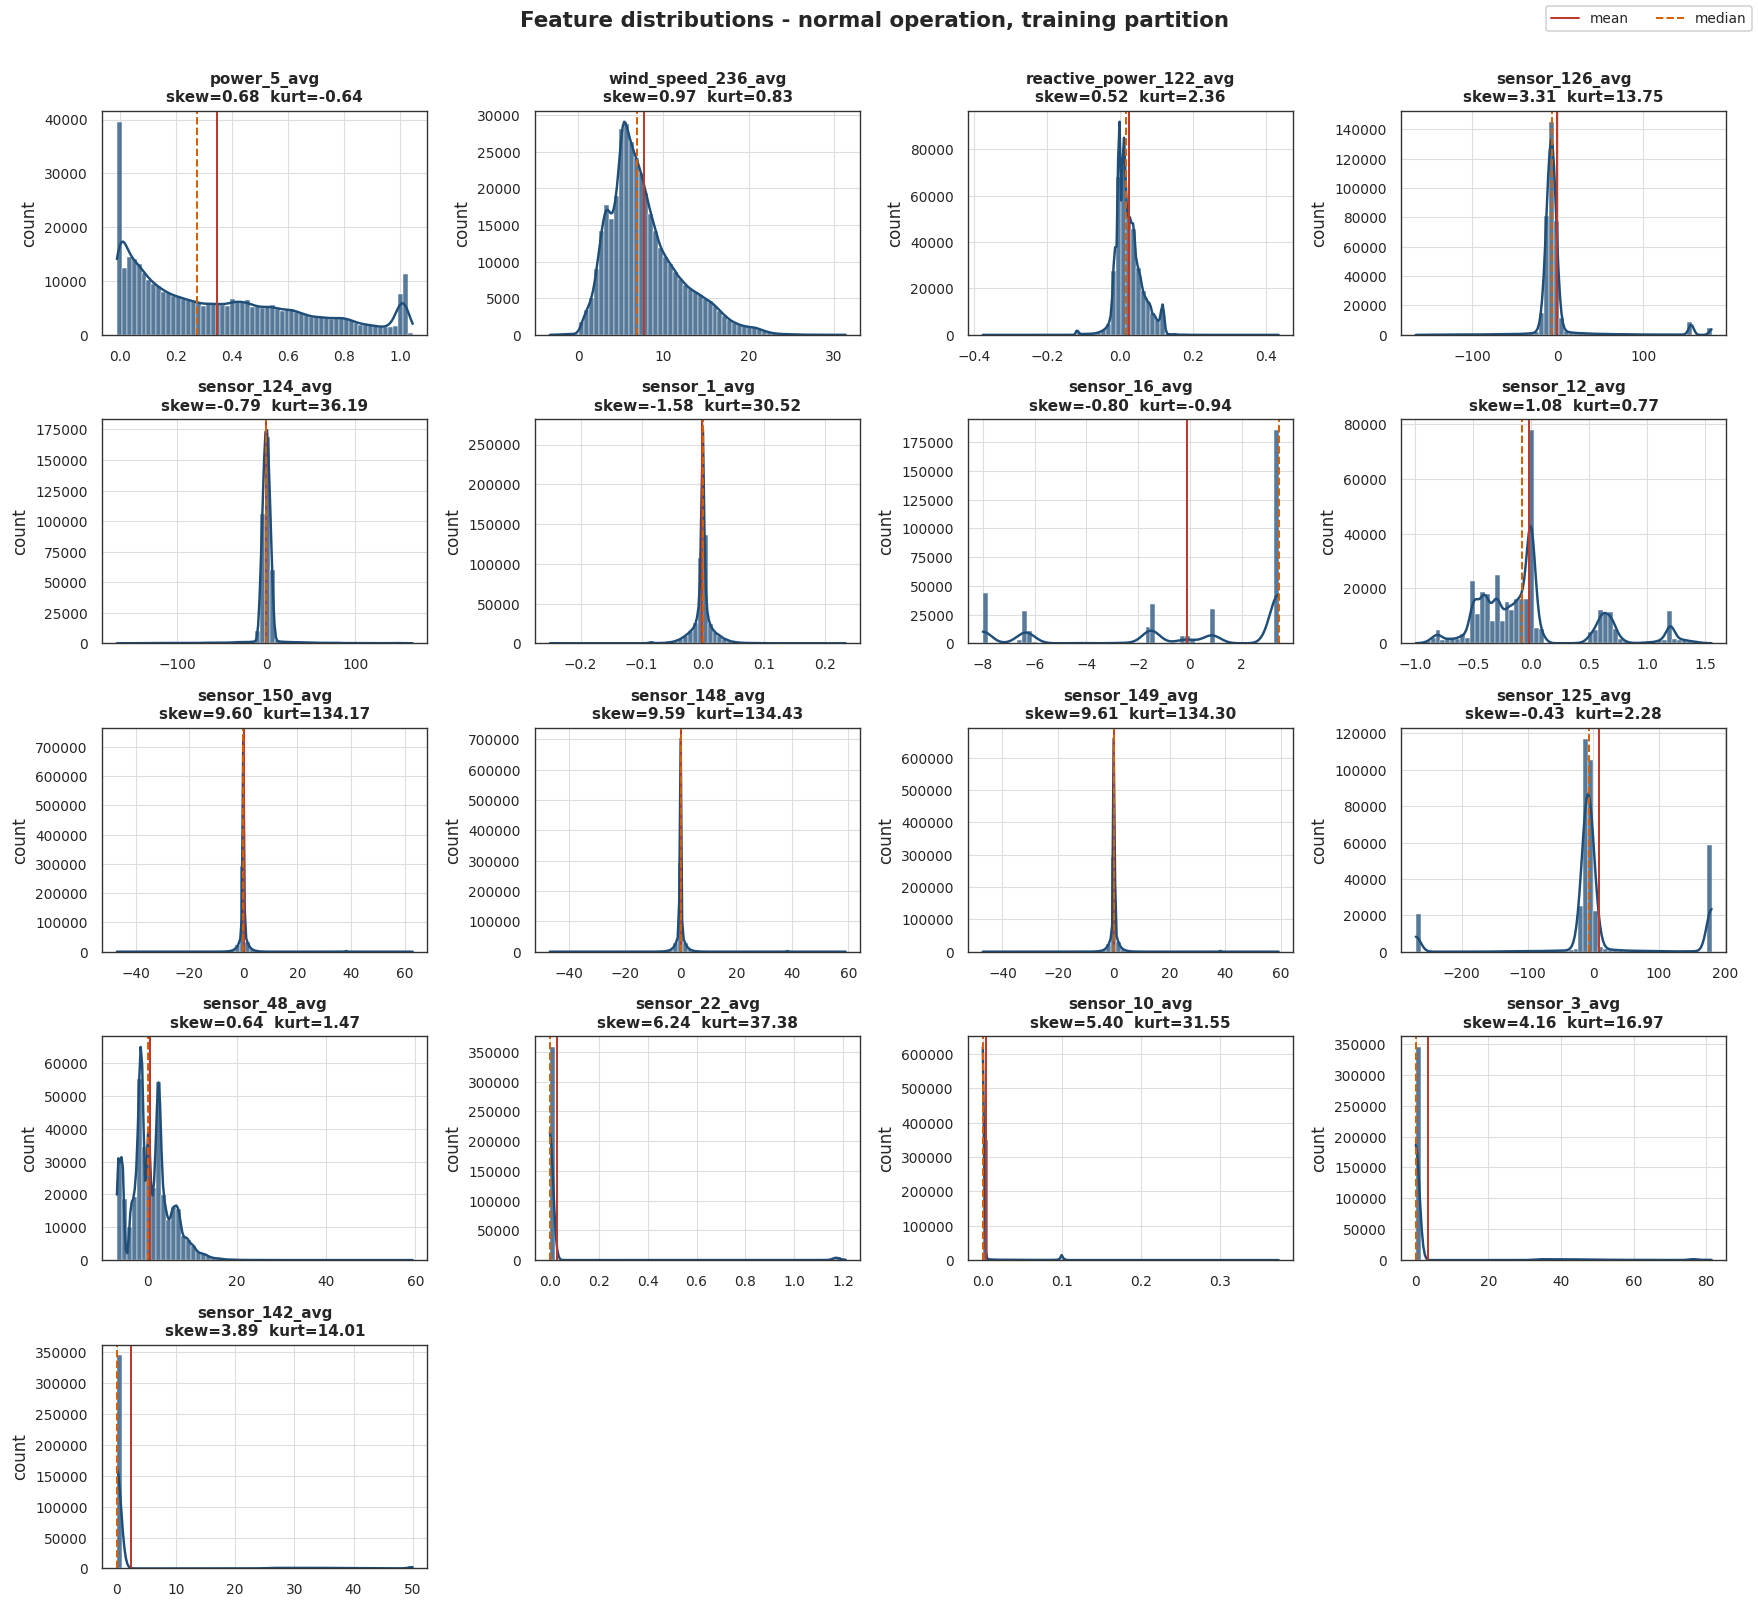

In [82]:
def plot_distribution_grid(df: pd.DataFrame, columns: Sequence[str],
                           ncols: int = 4, name: str = "11_distributions") -> None:
    # Histogram + KDE per channel, annotated with mean and median.
    cols = [c for c in columns if c in df.columns]
    nrows = int(np.ceil(len(cols) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(4.0 * ncols, 2.9 * nrows))
    axes = np.atleast_1d(axes).ravel()

    for ax, col in zip(axes, cols):
        s = df[col].dropna()
        if s.empty:
            ax.set_axis_off()
            continue
        sns.histplot(s, bins=60, kde=True, ax=ax, color=PALETTE["primary"],
                     edgecolor=None, alpha=0.75, line_kws={"lw": 1.6})
        ax.axvline(s.mean(), color=PALETTE["warning"], ls="-", lw=1.3, label="mean")
        ax.axvline(s.median(), color=PALETTE["accent"], ls="--", lw=1.3, label="median")
        ax.set_title(f"{col}\nskew={s.skew():.2f}  kurt={s.kurtosis():.2f}", fontsize=10)
        ax.set_xlabel("")
        ax.set_ylabel("count")
    for ax in axes[len(cols):]:
        ax.set_axis_off()

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper right", ncol=2)
    fig.suptitle("Feature distributions - normal operation, training partition",
                 fontsize=14, fontweight="bold", y=1.005)
    fig.tight_layout()
    save_fig(fig, name)
    plt.show()


plot_distribution_grid(df_norm, ANALYSIS_FEATURES)

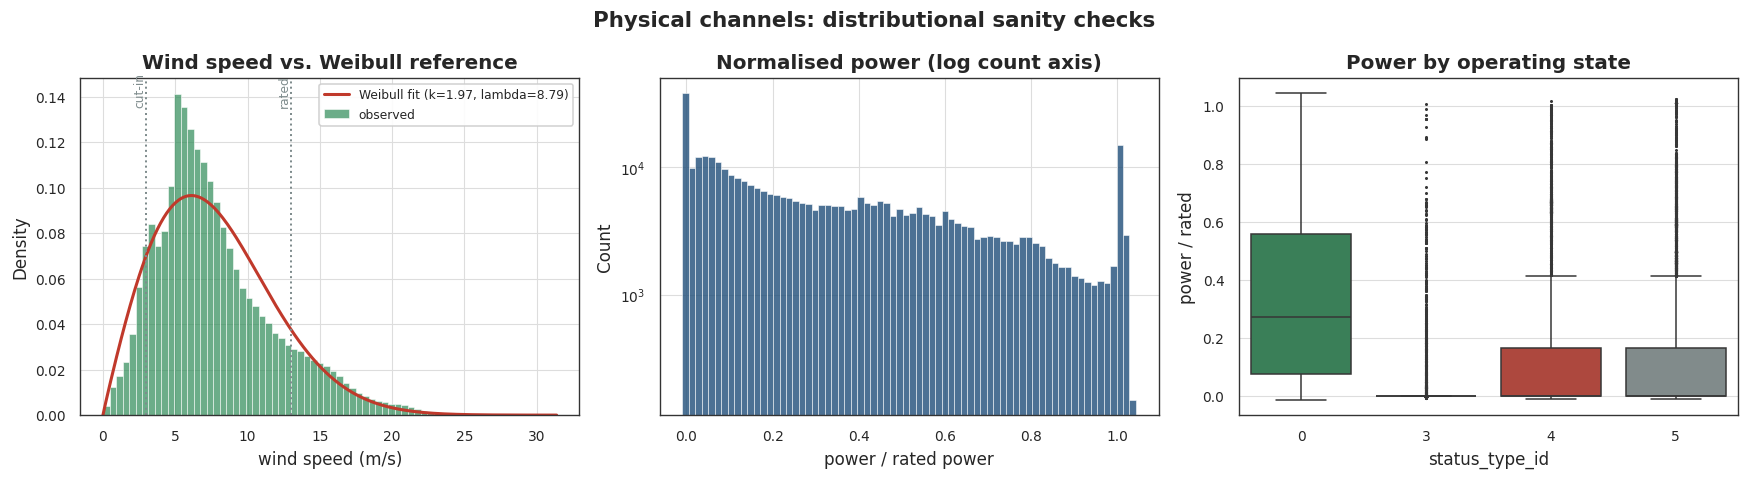

In [83]:
# ---- the two channels with known physics deserve a closer look ---------------
fig, axes = plt.subplots(1, 3, figsize=(16, 4.4))

ws = df_norm[WIND].dropna()
ws = ws[ws > 0]
sns.histplot(ws, bins=70, stat="density", color=PALETTE["secondary"],
             alpha=0.7, ax=axes[0], edgecolor=None, label="observed")
shape, loc, scale = stats.weibull_min.fit(ws, floc=0)
grid = np.linspace(0, ws.max(), 300)
axes[0].plot(grid, stats.weibull_min.pdf(grid, shape, loc, scale),
             color=PALETTE["warning"], lw=2,
             label=f"Weibull fit (k={shape:.2f}, lambda={scale:.2f})")
for x, lab in [(CFG.cut_in_speed, "cut-in"), (CFG.rated_speed, "rated")]:
    axes[0].axvline(x, color=PALETTE["neutral"], ls=":", lw=1.3)
    axes[0].text(x, axes[0].get_ylim()[1] * 0.92, lab, rotation=90,
                 fontsize=8, ha="right", color=PALETTE["neutral"])
axes[0].set_title("Wind speed vs. Weibull reference")
axes[0].set_xlabel("wind speed (m/s)")
axes[0].legend(fontsize=8)

sns.histplot(df_norm[POWER].dropna(), bins=70, color=PALETTE["primary"],
             alpha=0.8, ax=axes[1], edgecolor=None)
axes[1].set_yscale("log")
axes[1].set_title("Normalised power (log count axis)")
axes[1].set_xlabel("power / rated power")

order = sorted(df_clean[CFG.status_col].dropna().unique())
sns.boxplot(data=df_clean, x=CFG.status_col, y=POWER, order=order,
            hue=CFG.status_col, legend=False, ax=axes[2],
            palette={k: STATUS_COLORS.get(int(k), PALETTE["neutral"]) for k in order},
            fliersize=1)
axes[2].set_xticks(range(len(order)))
axes[2].set_xticklabels([STATUS_LABELS.get(int(k), str(k)).split(" · ")[0] for k in order])
axes[2].set_title("Power by operating state")
axes[2].set_xlabel("status_type_id")
axes[2].set_ylabel("power / rated")

fig.suptitle("Physical channels: distributional sanity checks",
             fontsize=14, fontweight="bold")
fig.tight_layout()
save_fig(fig, "11_physical_distributions")
plt.show()

**Observations and implications.**

* **Wind speed** follows a Weibull-like shape, as expected offshore. A shape parameter far
  from ~2 or a suspiciously truncated upper tail would indicate an anemometer fault or a
  clipped export rather than a meteorological fact.
* **Power is bimodal**, with a large spike at zero (idle/parked) and a plateau at rated.
  This is why *mean* power is a poor summary statistic and why regression NBMs should be
  conditioned on wind speed rather than trained to predict power unconditionally.
* **The boxplot by status** quantifies how much of the power variance is explained by the
  operating state alone. Wide overlap between status 0 and 1 means the status label is not
  a clean separator on its own — reinforcing the physics-based cross-check in Section 18.

---
## 12. Correlation Matrix

With 238 physical sensors a full correlation matrix is unreadable, so this section does
three targeted things instead:

1. Pearson **and** Spearman on the analysis feature set (linear vs. monotonic structure).
2. A hierarchically clustered heat-map that reveals *sensor groups* (thermal, electrical,
   control) without knowing the sensor names.
3. A redundancy scan across **all** channels to find near-duplicate signals.

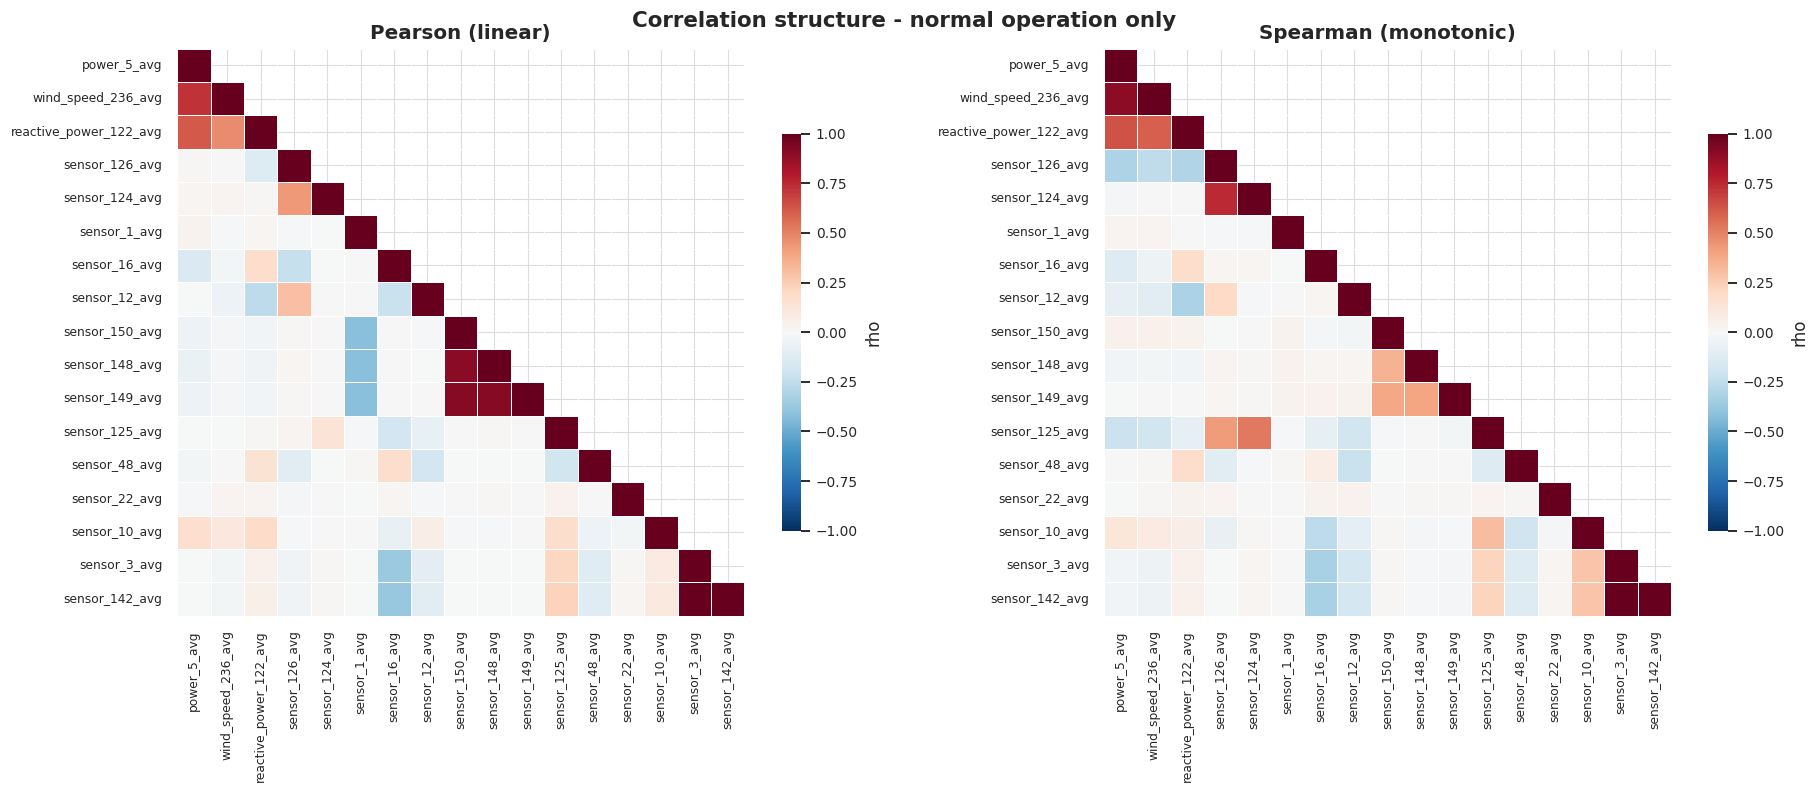

In [84]:
def correlation_matrices(df: pd.DataFrame, columns: Sequence[str],
                         sample: int = 60_000) -> Tuple[pd.DataFrame, pd.DataFrame]:
    sub = df[list(columns)].dropna()
    if len(sub) > sample:
        sub = sub.sample(sample, random_state=RANDOM_SEED)
    return sub.corr(method="pearson"), sub.corr(method="spearman")


corr_p, corr_s = correlation_matrices(df_norm, ANALYSIS_FEATURES)

fig, axes = plt.subplots(1, 2, figsize=(17, 7))
mask = np.triu(np.ones_like(corr_p, dtype=bool), k=1)
for ax, mat, title in ((axes[0], corr_p, "Pearson (linear)"),
                       (axes[1], corr_s, "Spearman (monotonic)")):
    sns.heatmap(mat, mask=mask, cmap=DIV_CMAP, vmin=-1, vmax=1, center=0,
                square=True, linewidths=0.4, cbar_kws={"shrink": 0.7, "label": "rho"},
                annot=len(mat) <= 14, fmt=".2f", annot_kws={"size": 7}, ax=ax)
    ax.set_title(title)
    ax.tick_params(axis="x", rotation=90, labelsize=8)
    ax.tick_params(axis="y", rotation=0, labelsize=8)

fig.suptitle("Correlation structure - normal operation only",
             fontsize=14, fontweight="bold")
fig.tight_layout()
save_fig(fig, "12_correlation_matrices")
plt.show()

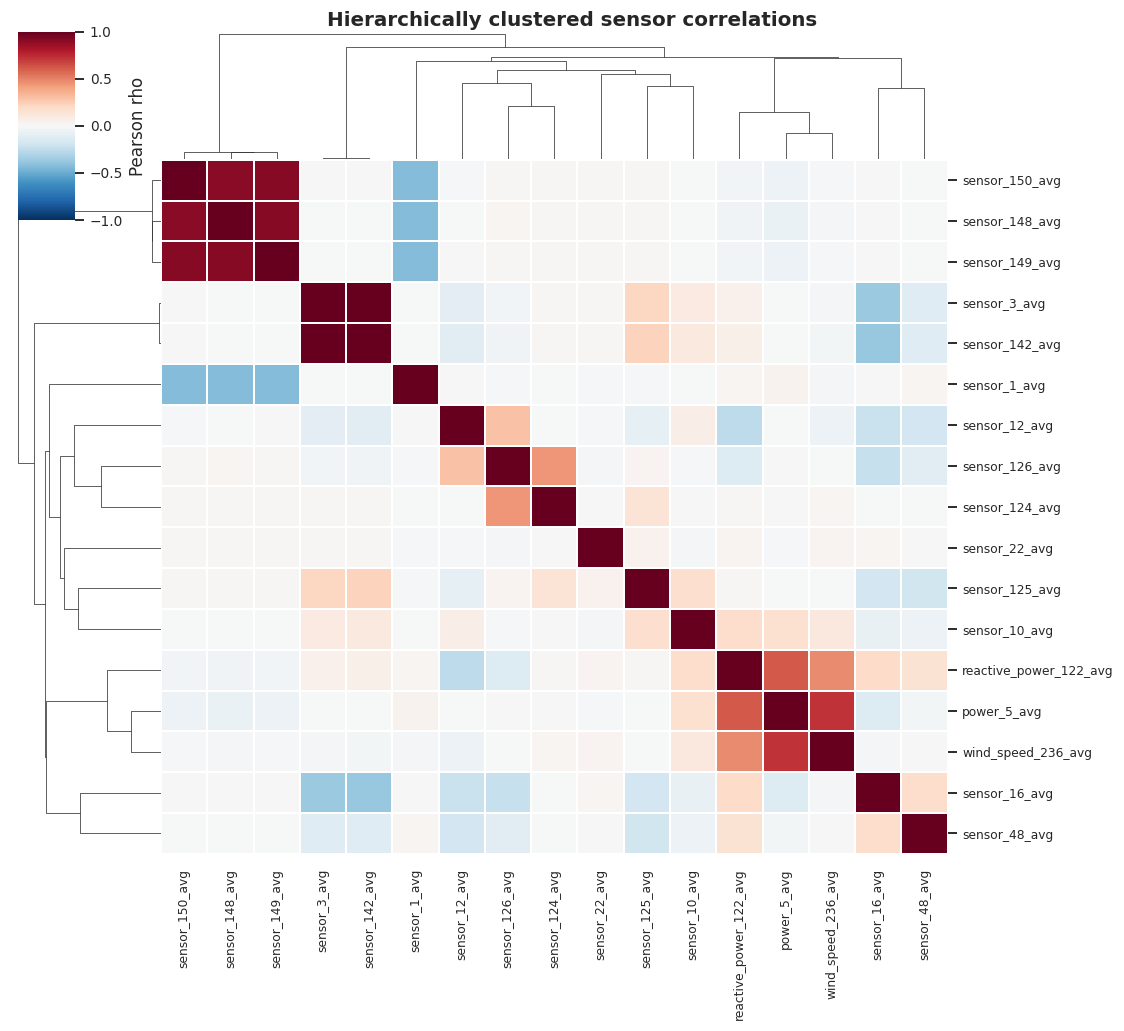

In [85]:
# ---- clustered heat-map: which sensors form physical subsystems? -------------
cluster_cols = ANALYSIS_FEATURES[: CFG.corr_top_k]
cl_data = df_norm[cluster_cols].dropna()
if len(cl_data) > 40_000:
    cl_data = cl_data.sample(40_000, random_state=RANDOM_SEED)
cl_corr = cl_data.corr().fillna(0)

g = sns.clustermap(cl_corr, cmap=DIV_CMAP, vmin=-1, vmax=1, center=0,
                   figsize=(10.5, 9.5), linewidths=0.3,
                   cbar_kws={"label": "Pearson rho"},
                   dendrogram_ratio=(0.16, 0.16))
g.figure.suptitle("Hierarchically clustered sensor correlations",
                  fontsize=13, fontweight="bold", y=1.0)
g.ax_heatmap.tick_params(labelsize=8)
save_fig(g.figure, "12_correlation_clustermap")
plt.show()

In [86]:
def redundancy_scan(df: pd.DataFrame, columns: Sequence[str],
                    threshold: float = CFG.redundancy_threshold,
                    sample: int = 30_000) -> pd.DataFrame:
    # Find near-duplicate channels across the FULL sensor space.
    sub = df[list(columns)]
    sub = sub.loc[:, sub.std(numeric_only=True) > 0]
    if len(sub) > sample:
        sub = sub.sample(sample, random_state=RANDOM_SEED)
    corr = sub.corr().abs()
    upper = corr.where(np.triu(np.ones(corr.shape, dtype=bool), k=1))
    pairs = (upper.stack().rename("abs_corr").reset_index()
                  .rename(columns={"level_0": "feature_a", "level_1": "feature_b"}))
    return pairs[pairs["abs_corr"] >= threshold].sort_values("abs_corr", ascending=False)


redundant = redundancy_scan(df_norm, sensor_cols)
drop_candidates = sorted(set(redundant["feature_b"]))
print(f"Near-duplicate channel pairs (|rho| >= {CFG.redundancy_threshold}): {len(redundant)}")
print(f"Channels that could be dropped without information loss: {len(drop_candidates)} "
      f"of {len(sensor_cols)} ({len(drop_candidates) / len(sensor_cols):.1%})")
show(redundant, 15)

Near-duplicate channel pairs (|rho| >= 0.98): 298
Channels that could be dropped without information loss: 95 of 243 (39.1%)


,feature_a,feature_b,abs_corr
28737,sensor_206_avg,sensor_207_avg,1.0000
1200,power_5_avg,power_6_avg,1.0000
23187,sensor_131_avg,sensor_132_avg,1.0000
23838,sensor_137_avg,sensor_138_avg,1.0000
23733,sensor_136_avg,sensor_138_avg,1.0000
23732,sensor_136_avg,sensor_137_avg,1.0000
23076,sensor_130_avg,sensor_132_avg,1.0000
23075,sensor_130_avg,sensor_131_avg,1.0000
19250,sensor_100_avg,sensor_101_avg,1.0000
19392,sensor_101_avg,sensor_102_avg,1.0000


**Interpretation.**

* **Pearson vs. Spearman divergence** is informative in itself: a pair with low Pearson but
  high Spearman correlation is monotonically but *non-linearly* related — exactly the
  wind-speed → power relationship. Linear models will underfit those pairs; tree- or
  network-based NBMs will not.
* **The dendrogram recovers subsystems without labels.** Tight blocks typically correspond
  to the drivetrain thermal group, the electrical group and the control group. This is a
  practical substitute for the sensor names lost to anonymisation and is a good basis for
  building **per-subsystem models** rather than one monolithic model.
* **Redundancy is severe by design.** Because most sensors ship as `avg/min/max/std`
  quadruplets, a large share of channels are near-duplicates. Pruning at `|ρ| ≥ 0.98`
  typically removes a substantial fraction of the feature space with no information loss,
  which directly reduces autoencoder training time and overfitting risk.

---
## 13. Time-Series Visualizations

One sub-dataset is inspected in depth. An anomaly-labelled dataset is chosen when one is
available so that the train/prediction split, the operating-state ribbon and the event
window can all be shown on the same time axis.

In [87]:
def pick_focus_dataset(df: pd.DataFrame) -> str:
    # Prefer an anomaly-labelled dataset; fall back to the largest one.
    if "event_label" in df.columns:
        anomalies = (df.loc[df["event_label"].astype(str).eq("anomaly"), "dataset_id"]
                       .value_counts())
        if len(anomalies):
            return str(anomalies.index[0])
    return str(df["dataset_id"].value_counts().index[0])


FOCUS_ID = pick_focus_dataset(df_clean)
focus = (df_clean[df_clean["dataset_id"] == FOCUS_ID]
         .sort_values(CFG.ts_col)
         .set_index(CFG.ts_col))

focus_label = str(focus["event_label"].iloc[0]) if "event_label" in focus.columns else "n/a"
ev_start = focus["event_start"].iloc[0] if "event_start" in focus.columns else pd.NaT
ev_end = focus["event_end"].iloc[0] if "event_end" in focus.columns else pd.NaT

print(f"Focus sub-dataset : {FOCUS_ID}")
print(f"Turbine (asset_id): {focus[CFG.asset_col].iloc[0]}")
print(f"Event label       : {focus_label}")
print(f"Event window      : {ev_start} -> {ev_end}")
print(f"Records           : {len(focus):,}  ({focus.index.min()} -> {focus.index.max()})")

Focus sub-dataset : 11
Turbine (asset_id): 43
Event label       : anomaly
Event window      : 2022-10-16 12:30:00 -> 2022-11-07 10:30:00
Records           : 56,437  (2022-10-17 12:30:00 -> 2023-11-14 10:30:00)


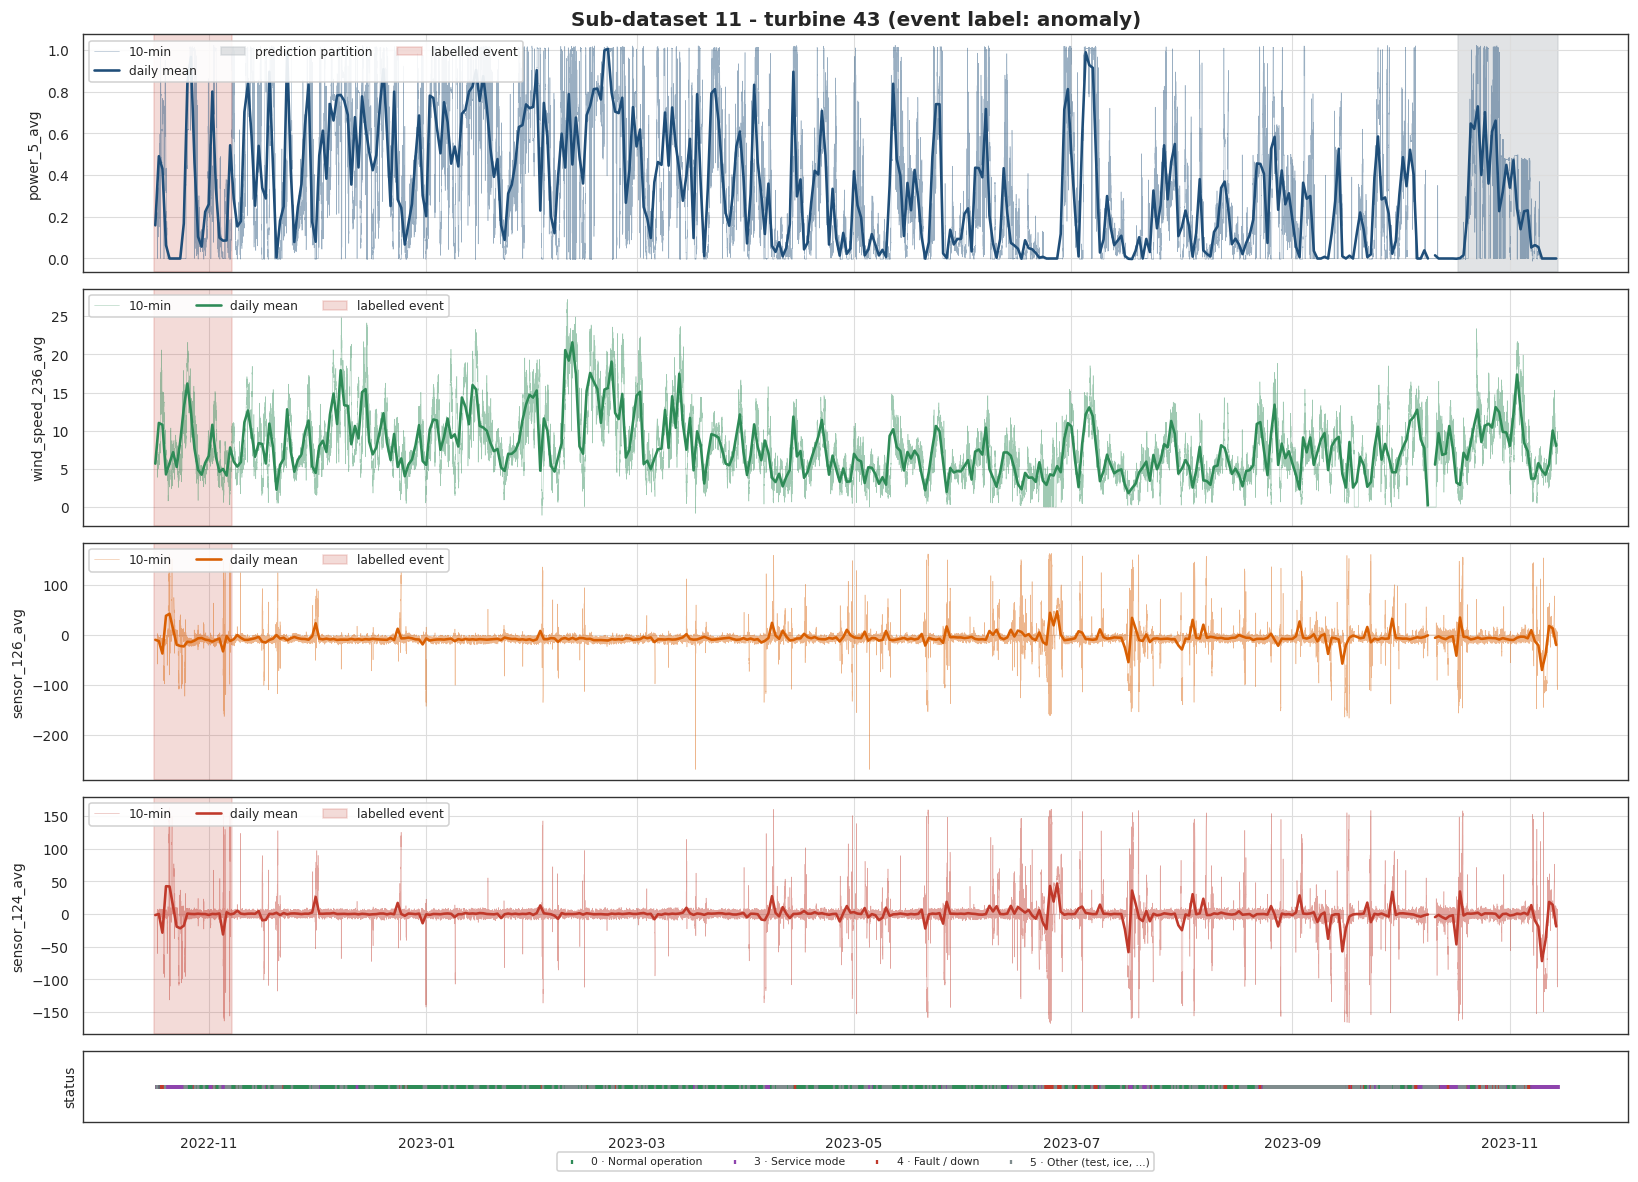

In [88]:
def shade_context(ax: plt.Axes, frame: pd.DataFrame,
                  ev_start=pd.NaT, ev_end=pd.NaT, show_split: bool = True) -> None:
    # Shade the prediction partition and the labelled event window on a time axis.
    if show_split and CFG.split_col in frame.columns:
        pred = frame[frame[CFG.split_col].astype(str).eq("prediction")]
        if len(pred):
            ax.axvspan(pred.index.min(), pred.index.max(), color=PALETTE["light"],
                       alpha=0.45, zorder=0, label="prediction partition")
    if pd.notna(ev_start):
        ax.axvspan(ev_start, ev_end if pd.notna(ev_end) else frame.index.max(),
                   color=PALETTE["warning"], alpha=0.18, zorder=1, label="labelled event")


def plot_focus_overview(frame: pd.DataFrame, channels: Sequence[str],
                        ev_start=pd.NaT, ev_end=pd.NaT) -> None:
    # Stacked time-series panels sharing one x-axis, plus a status ribbon.
    channels = [c for c in channels if c in frame.columns]
    n = len(channels)
    fig, axes = plt.subplots(n + 1, 1, figsize=(15, 2.1 * n + 2.4),
                             sharex=True,
                             gridspec_kw={"height_ratios": [3] * n + [0.9]})
    colors = [PALETTE["primary"], PALETTE["secondary"], PALETTE["accent"],
              PALETTE["warning"], "#6a3d9a", "#17becf"]

    daily = frame[channels].resample("1D").mean()
    for i, (ax, col) in enumerate(zip(axes[:-1], channels)):
        ax.plot(frame.index, frame[col], lw=0.35, alpha=0.45,
                color=colors[i % len(colors)], label="10-min")
        ax.plot(daily.index, daily[col], lw=1.7,
                color=colors[i % len(colors)], label="daily mean")
        shade_context(ax, frame, ev_start, ev_end, show_split=(i == 0))
        ax.set_ylabel(col, fontsize=9)
        ax.legend(loc="upper left", ncol=3, fontsize=8)

    ribbon = axes[-1]
    status = frame[CFG.status_col].astype("float")
    for code_id, colr in STATUS_COLORS.items():
        m = status == code_id
        if m.any():
            ribbon.scatter(frame.index[m], np.zeros(int(m.sum())), s=6, marker="|",
                           color=colr, label=STATUS_LABELS[code_id])
    ribbon.set_yticks([])
    ribbon.set_ylabel("status", fontsize=9)
    ribbon.legend(loc="upper center", ncol=6, fontsize=7, bbox_to_anchor=(0.5, -0.35))
    ribbon.grid(False)

    axes[0].set_title(f"Sub-dataset {FOCUS_ID} - turbine {frame[CFG.asset_col].iloc[0]} "
                      f"(event label: {focus_label})", fontsize=13, fontweight="bold")
    fig.tight_layout()
    save_fig(fig, "13_focus_timeseries")
    plt.show()


thermal_candidates = [c for c in ANALYSIS_FEATURES if c not in (POWER, WIND, REACTIVE)][:2]
plot_focus_overview(focus, [POWER, WIND] + thermal_candidates, ev_start, ev_end)

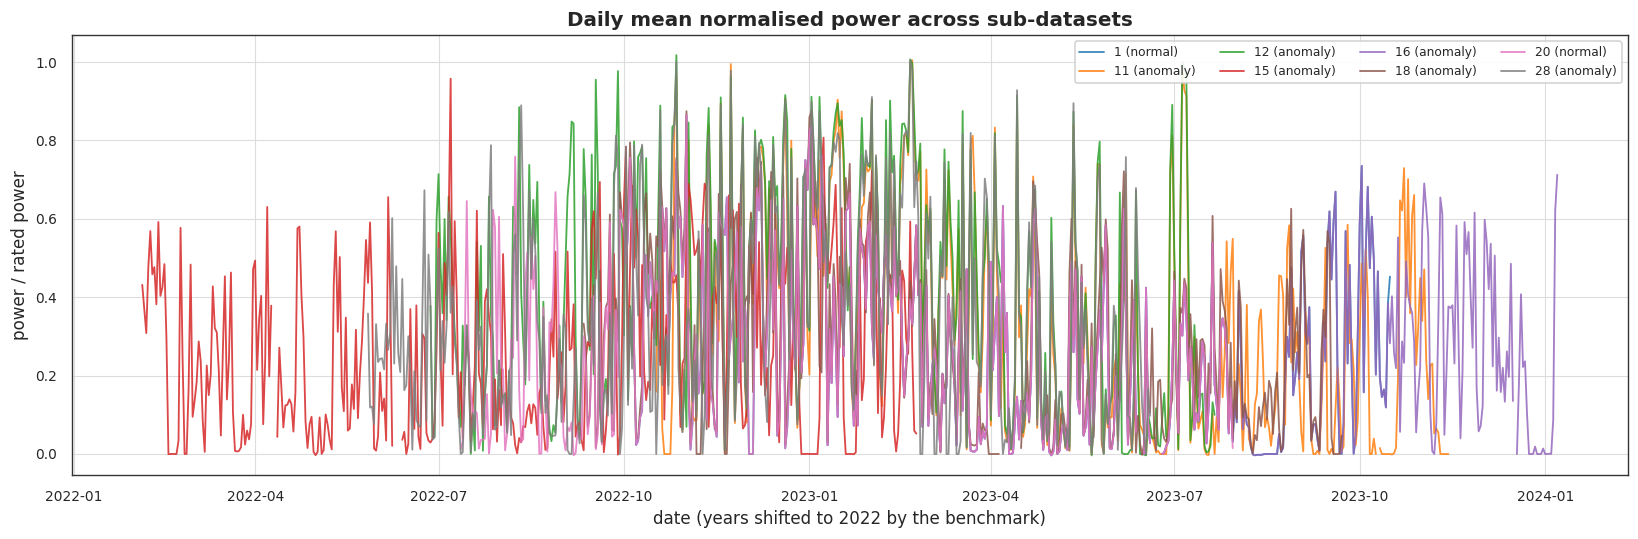

In [89]:
# ---- fleet view: are all turbines behaving alike? ----------------------------
daily_power = (df_clean.set_index(CFG.ts_col)
                       .groupby("dataset_id")[POWER]
                       .resample("1D").mean()
                       .rename("daily_power")
                       .reset_index())

fig, ax = plt.subplots(figsize=(15, 5))
cmap = plt.get_cmap("tab10")
for i, (did, g) in enumerate(daily_power.groupby("dataset_id")):
    lbl = per_dataset.loc[did, "event_label"] if "event_label" in per_dataset.columns else ""
    ax.plot(g[CFG.ts_col], g["daily_power"], lw=1.2, alpha=0.85,
            color=cmap(i % 10), label=f"{did} ({lbl})")
ax.set_title("Daily mean normalised power across sub-datasets")
ax.set_ylabel("power / rated power")
ax.set_xlabel("date (years shifted to 2022 by the benchmark)")
ax.legend(ncol=4, fontsize=8, loc="upper right")
fig.tight_layout()
save_fig(fig, "13_fleet_daily_power")
plt.show()

**Patterns to look for.**

* **Winter-high / summer-low power** is the dominant signal and reflects the seasonal wind
  resource, not machine health. Any drift detector must therefore be *seasonality-aware* or
  it will fire every autumn.
* **Deep, narrow troughs** in a single sub-dataset while the others hold up are
  turbine-specific downtime — cross-referencing them against the status ribbon separates
  planned maintenance (status 3) from faults (status 4).
* **Slow divergence of one curve from the fleet** in the weeks before the event window is
  exactly the signature an early-failure detector must catch. Note that this fleet-relative
  view is only usable *within* a sub-dataset group with genuinely aligned calendars — the
  benchmark's year-shifting means cross-dataset comparison is indicative, not rigorous.

---
## 14. Trend Analysis

Two flavours of trend are relevant for predictive maintenance:

* **Environmental trend** — power follows wind, so a downward power trend may be entirely
  meteorological.
* **Health trend** — the *residual* after removing the environmental driver. A rising
  temperature residual at constant load is the classic incipient-fault indicator.

In [90]:
def linear_trend(series: pd.Series) -> Dict[str, float]:
    # OLS slope of a time series expressed per 30 days, with significance.
    s = series.dropna()
    if len(s) < 10:
        return {"slope_per_30d": np.nan, "r2": np.nan, "p_value": np.nan}
    x = (s.index - s.index[0]).total_seconds().to_numpy() / 86400.0
    res = stats.linregress(x, s.to_numpy())
    return {"slope_per_30d": res.slope * 30,
            "r2": res.rvalue ** 2,
            "p_value": res.pvalue}


def trend_table(frame: pd.DataFrame, columns: Sequence[str],
                freq: str = "1D") -> pd.DataFrame:
    daily = frame[list(columns)].resample(freq).mean()
    rows = []
    for col in daily.columns:
        r = linear_trend(daily[col])
        r["feature"] = col
        r["mean"] = daily[col].mean()
        r["relative_drift_pct_per_30d"] = (r["slope_per_30d"] / abs(r["mean"]) * 100
                                           if r["mean"] else np.nan)
        rows.append(r)
    return (pd.DataFrame(rows)
              .set_index("feature")
              .sort_values("relative_drift_pct_per_30d", key=np.abs, ascending=False))


trend_tbl = trend_table(focus, ANALYSIS_FEATURES)
show(trend_tbl[["mean", "slope_per_30d", "relative_drift_pct_per_30d", "r2", "p_value"]], 12,
     f"Linear trends in sub-dataset {FOCUS_ID} (daily means):")

Linear trends in sub-dataset 11 (daily means):


,mean,slope_per_30d,relative_drift_pct_per_30d,r2,p_value
feature,,,,,
sensor_124_avg,-0.0859,-0.2167,-252.3033,0.0057,0.1350
sensor_149_avg,-0.0019,-0.0014,-73.1749,0.0010,0.5313
sensor_1_avg,-0.0008,-0.0003,-40.1038,0.0061,0.1225
sensor_125_avg,88.9658,-21.2215,-23.8535,0.7484,0.0000
sensor_22_avg,0.0438,-0.0076,-17.4496,0.2726,0.0000
power_5_avg,0.3325,-0.0286,-8.5891,0.1518,0.0000
sensor_16_avg,-5.2064,0.3464,6.6542,0.1899,0.0000
reactive_power_122_avg,0.0380,-0.0024,-6.4213,0.0833,0.0000
sensor_148_avg,-0.0063,-0.0004,-5.9127,0.0001,0.8665


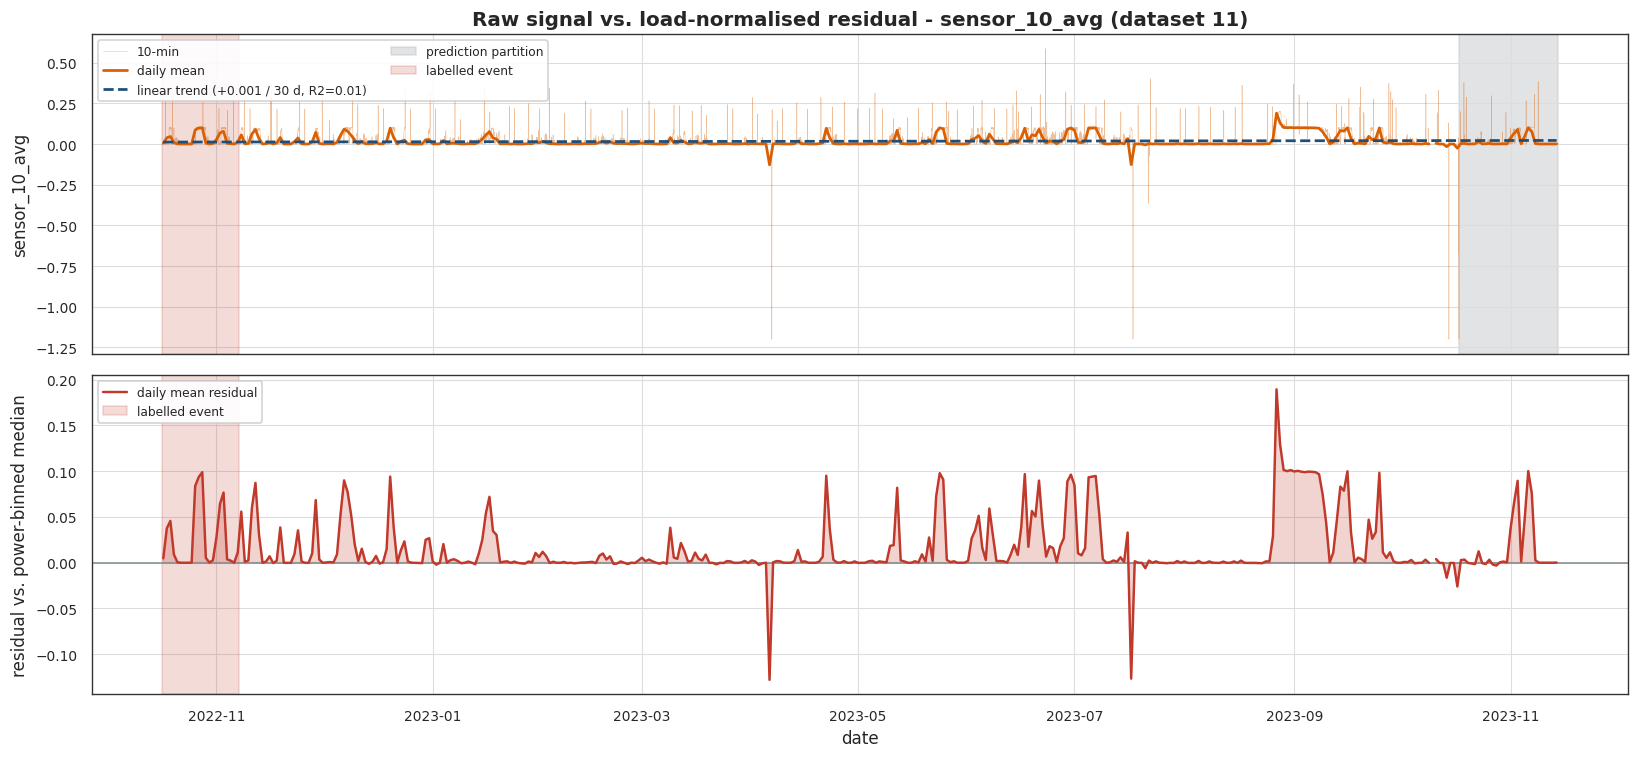

In [91]:
def load_normalised_residual(frame: pd.DataFrame, target: str,
                             driver: str = None, bins: int = 24) -> pd.Series:
    # Residual of `target` after removing its dependence on `driver` (default: power).
    driver = driver or POWER
    sub = frame[[target, driver]].dropna()
    if sub.empty:
        return pd.Series(dtype=float)
    binned = pd.cut(sub[driver], bins=bins)
    expected = sub.groupby(binned, observed=True)[target].transform("median")
    return (sub[target] - expected).rename(f"{target}_residual")


# pick the thermal-looking channel with the strongest correlation to power
thermal_col = (df_norm[[c for c in ANALYSIS_FEATURES if c not in (POWER, WIND, REACTIVE)]]
               .corrwith(df_norm[POWER]).abs().sort_values(ascending=False).index[0])
resid = load_normalised_residual(focus, thermal_col)
resid_daily = resid.resample("1D").mean()

fig, axes = plt.subplots(2, 1, figsize=(15, 7), sharex=True)

axes[0].plot(focus.index, focus[thermal_col], lw=0.35, alpha=0.4,
             color=PALETTE["accent"], label="10-min")
axes[0].plot(focus[thermal_col].resample("1D").mean(), lw=1.8,
             color=PALETTE["accent"], label="daily mean")
tr = linear_trend(focus[thermal_col].resample("1D").mean())
xs = focus[thermal_col].resample("1D").mean().dropna()
axes[0].plot(xs.index,
             np.polyval(np.polyfit(np.arange(len(xs)), xs.to_numpy(), 1), np.arange(len(xs))),
             color=PALETTE["primary"], ls="--", lw=1.8,
             label=f"linear trend ({tr['slope_per_30d']:+.3f} / 30 d, R2={tr['r2']:.2f})")
shade_context(axes[0], focus, ev_start, ev_end)
axes[0].set_ylabel(thermal_col)
axes[0].set_title(f"Raw signal vs. load-normalised residual - {thermal_col} (dataset {FOCUS_ID})")
axes[0].legend(loc="upper left", fontsize=8, ncol=2)

axes[1].axhline(0, color=PALETTE["neutral"], lw=1)
axes[1].plot(resid_daily.index, resid_daily.to_numpy(), lw=1.6,
             color=PALETTE["warning"], label="daily mean residual")
axes[1].fill_between(resid_daily.index, 0, resid_daily.to_numpy(),
                     color=PALETTE["warning"], alpha=0.22)
shade_context(axes[1], focus, ev_start, ev_end, show_split=False)
axes[1].set_ylabel("residual vs. power-binned median")
axes[1].set_xlabel("date")
axes[1].legend(loc="upper left", fontsize=8)

fig.tight_layout()
save_fig(fig, "14_trend_residual")
plt.show()

**Why the residual matters more than the raw trend.** The raw temperature curve is
dominated by ambient seasonality — a positive slope in spring says nothing about the
gearbox. The **load-normalised residual** asks a sharper question: *at the same power
output, is this component running hotter than it used to?* A residual that departs from
zero and stays there, weeks before the labelled event, is precisely the "earliness"
signal the CARE benchmark rewards. In production this residual, not the raw channel, is
what should be tracked with a control chart.

---
## 15. Seasonal Pattern Analysis

Wind SCADA data carries at least three periodicities: **annual** (wind resource and
ambient temperature), **diurnal** (thermal cycling, sea/land breeze) and a weak **weekly**
component (curtailment driven by electricity market demand rather than physics).

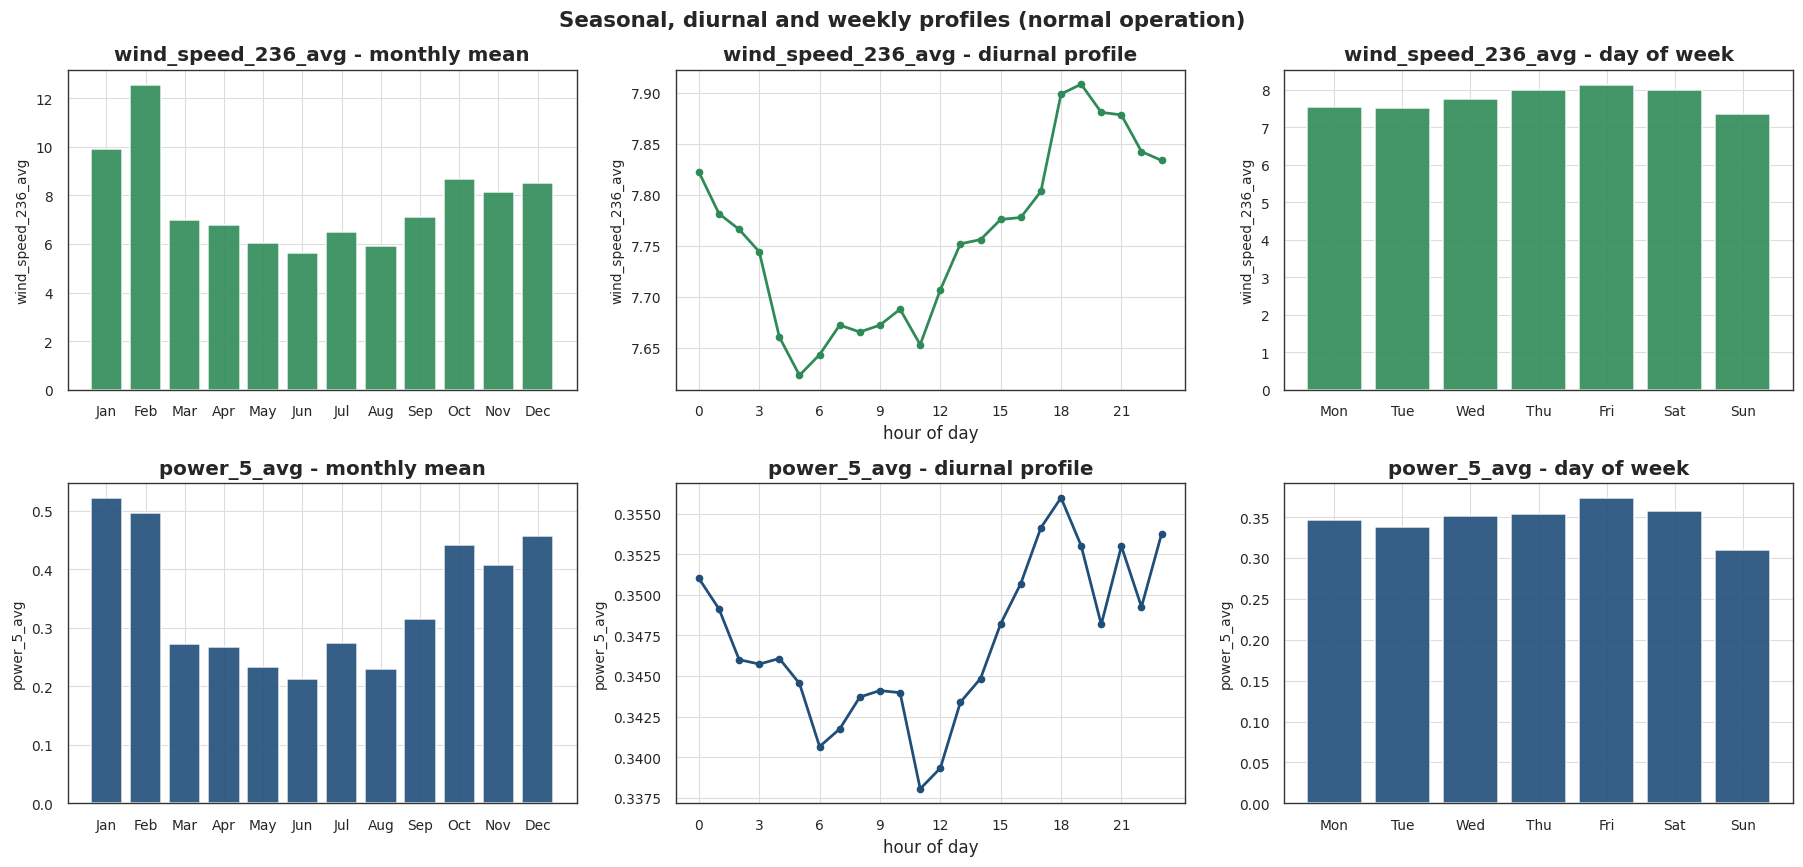

In [92]:
def seasonal_profiles(frame: pd.DataFrame, target: str) -> Tuple[pd.Series, pd.Series, pd.Series]:
    g = frame.copy()
    monthly = g.groupby(g.index.month)[target].mean()
    hourly = g.groupby(g.index.hour)[target].mean()
    weekly = g.groupby(g.index.dayofweek)[target].mean()
    return monthly, hourly, weekly


norm_idx = df_norm.set_index(CFG.ts_col)
MONTHS = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
          "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
DAYS = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

fig, axes = plt.subplots(2, 3, figsize=(16.5, 8))
for row, target, colour in ((0, WIND, PALETTE["secondary"]), (1, POWER, PALETTE["primary"])):
    monthly, hourly, weekly = seasonal_profiles(norm_idx, target)
    axes[row, 0].bar(MONTHS[: len(monthly)], monthly.to_numpy(), color=colour, alpha=0.9)
    axes[row, 0].set_title(f"{target} - monthly mean")
    axes[row, 1].plot(hourly.index, hourly.to_numpy(), marker="o", ms=4, lw=1.8, color=colour)
    axes[row, 1].set_title(f"{target} - diurnal profile")
    axes[row, 1].set_xlabel("hour of day")
    axes[row, 1].set_xticks(range(0, 24, 3))
    axes[row, 2].bar([DAYS[i] for i in weekly.index], weekly.to_numpy(), color=colour, alpha=0.9)
    axes[row, 2].set_title(f"{target} - day of week")
    for ax in axes[row]:
        ax.set_ylabel(target, fontsize=9)

fig.suptitle("Seasonal, diurnal and weekly profiles (normal operation)",
             fontsize=14, fontweight="bold")
fig.tight_layout()
save_fig(fig, "15_seasonal_profiles")
plt.show()

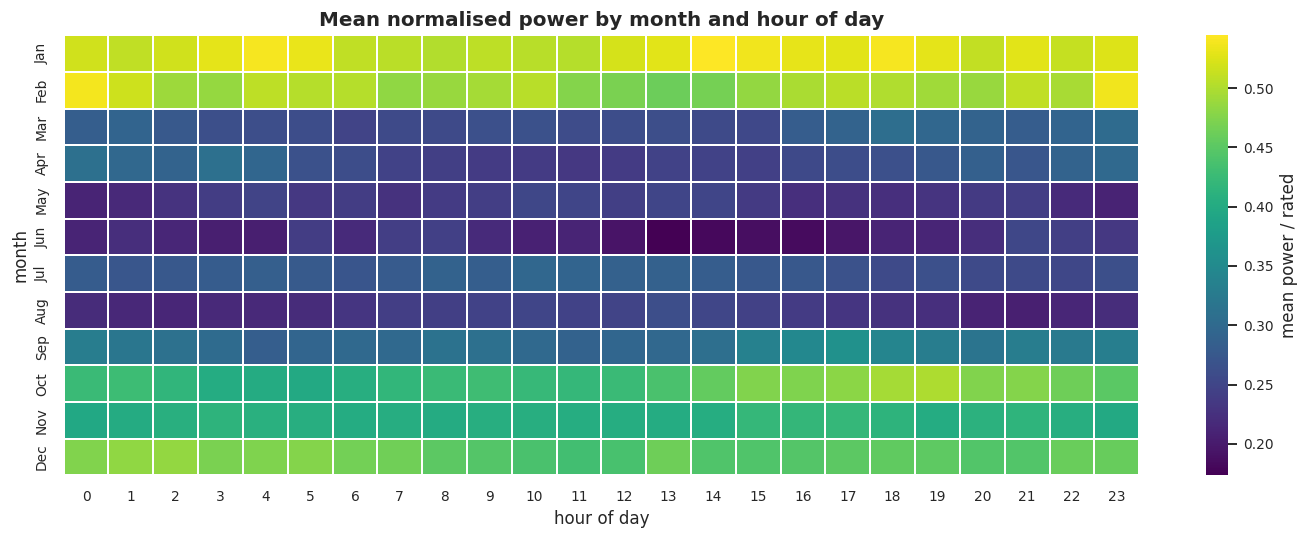

In [93]:
# ---- month x hour heat-map: the two cycles interact --------------------------
pivot = (norm_idx.groupby([norm_idx.index.month, norm_idx.index.hour])[POWER]
                 .mean().unstack())
pivot.index = [MONTHS[i - 1] for i in pivot.index]

fig, ax = plt.subplots(figsize=(13, 5))
sns.heatmap(pivot, cmap=SEQ_CMAP, ax=ax, linewidths=0.25,
            cbar_kws={"label": "mean power / rated"})
ax.set_title("Mean normalised power by month and hour of day")
ax.set_xlabel("hour of day")
ax.set_ylabel("month")
fig.tight_layout()
save_fig(fig, "15_month_hour_heatmap")
plt.show()

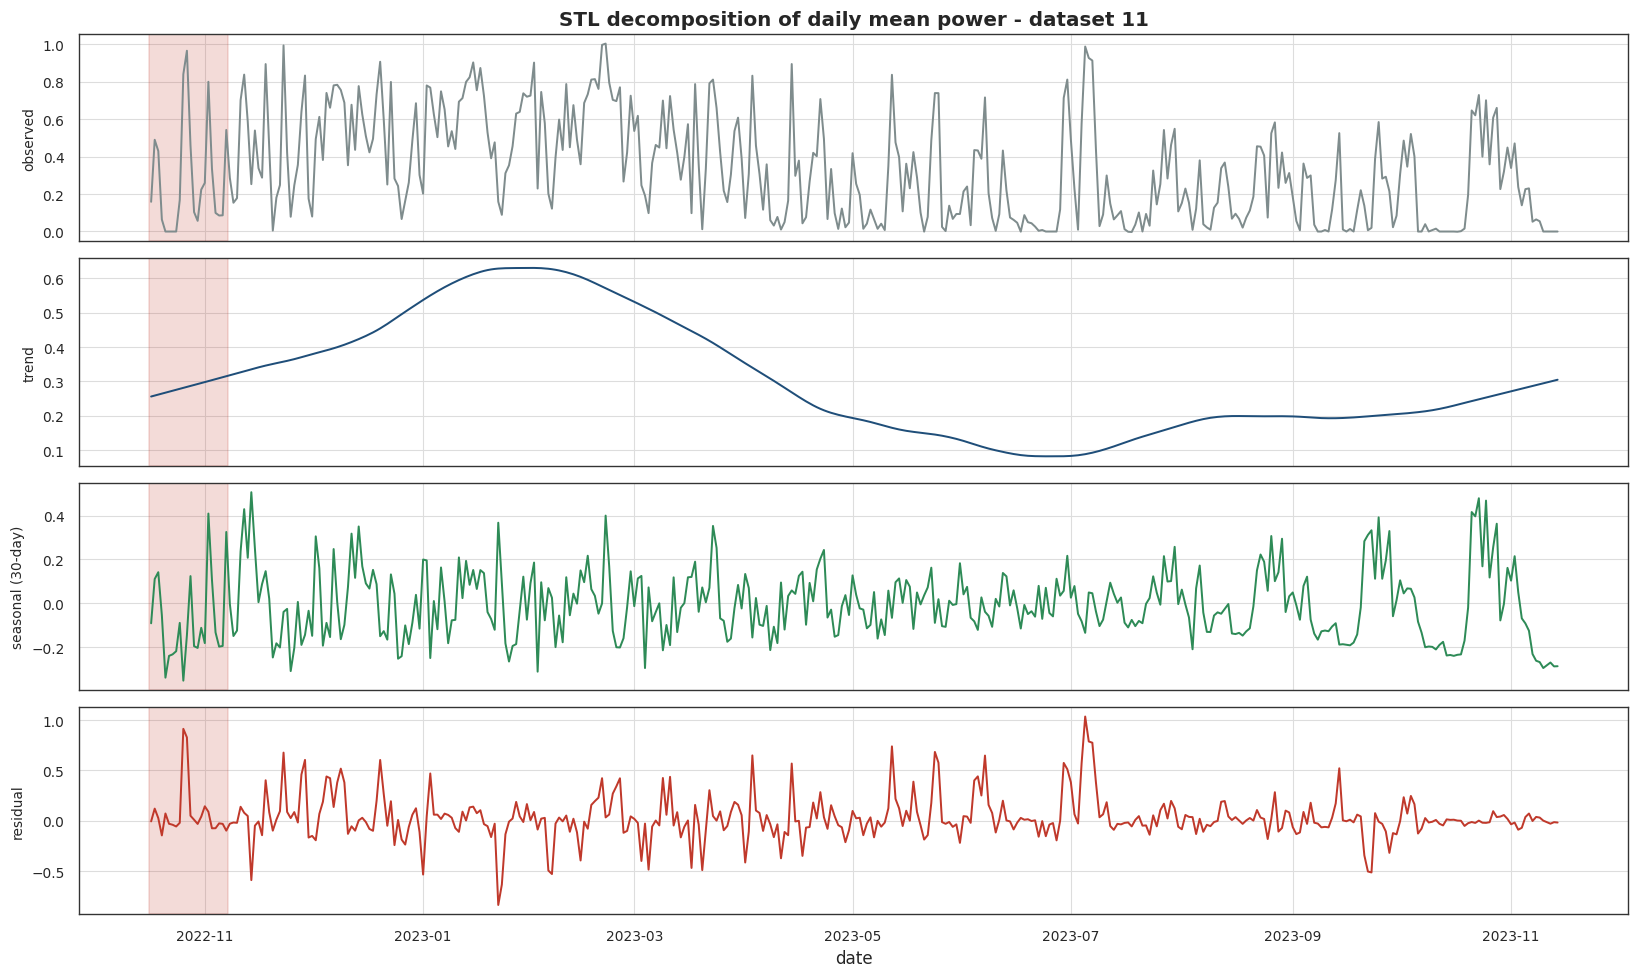

Trend strength   : 0.270
Seasonal strength: 0.176


In [94]:
# ---- STL decomposition of the focus series ----------------------------------
from statsmodels.tsa.seasonal import STL

daily_focus = focus[POWER].resample("1D").mean().interpolate(limit=3).dropna()
if len(daily_focus) >= 60:
    stl = STL(daily_focus, period=30, robust=True).fit()
    fig, axes = plt.subplots(4, 1, figsize=(15, 9), sharex=True)
    parts = [(daily_focus, "observed", PALETTE["neutral"]),
             (stl.trend, "trend", PALETTE["primary"]),
             (stl.seasonal, "seasonal (30-day)", PALETTE["secondary"]),
             (stl.resid, "residual", PALETTE["warning"])]
    for ax, (series, name, colour) in zip(axes, parts):
        ax.plot(series.index, np.asarray(series), lw=1.3, color=colour)
        ax.set_ylabel(name, fontsize=9)
        shade_context(ax, focus, ev_start, ev_end, show_split=False)
    axes[0].set_title(f"STL decomposition of daily mean power - dataset {FOCUS_ID}",
                      fontsize=13, fontweight="bold")
    axes[-1].set_xlabel("date")
    fig.tight_layout()
    save_fig(fig, "15_stl_decomposition")
    plt.show()

    strength_trend = max(0.0, 1 - stl.resid.var() / (stl.trend + stl.resid).var())
    strength_seas = max(0.0, 1 - stl.resid.var() / (stl.seasonal + stl.resid).var())
    print(f"Trend strength   : {strength_trend:.3f}")
    print(f"Seasonal strength: {strength_seas:.3f}")
else:
    print("Series too short for STL decomposition.")

**Modelling consequences.**

* The **annual cycle is the strongest component**, and every sub-dataset contains exactly
  one year of training data — by design, so that a model *can* learn it. Training on less
  than a full year guarantees the model will mistake the first unseen season for an anomaly.
* The **diurnal cycle** is modest for power but pronounced for thermal channels. Including
  `hour` as a cyclical feature (sin/cos) is cheap and removes a systematic residual pattern.
* A **weekday/weekend difference in power** cannot be meteorological. It points to
  market-driven curtailment and should be handled through the status/derating flag rather
  than learned as normal behaviour.
* In the STL panel, look for the **residual variance growing** ahead of the event window:
  rising unexplained variability is often an earlier indicator than a shift in the mean.

---
## 16. Rolling Mean and Rolling Standard Deviation

Rolling statistics serve two purposes here: **de-noising** the 10-minute signal so slow
drifts become visible, and **quantifying volatility**, which for rotating machinery is
often a better early indicator than the mean (bearings get noisy before they get hot).

Windows are specified as *time offsets* (`6h`, `24h`, `7D`) rather than sample counts, so
they remain correct even where samples are missing.

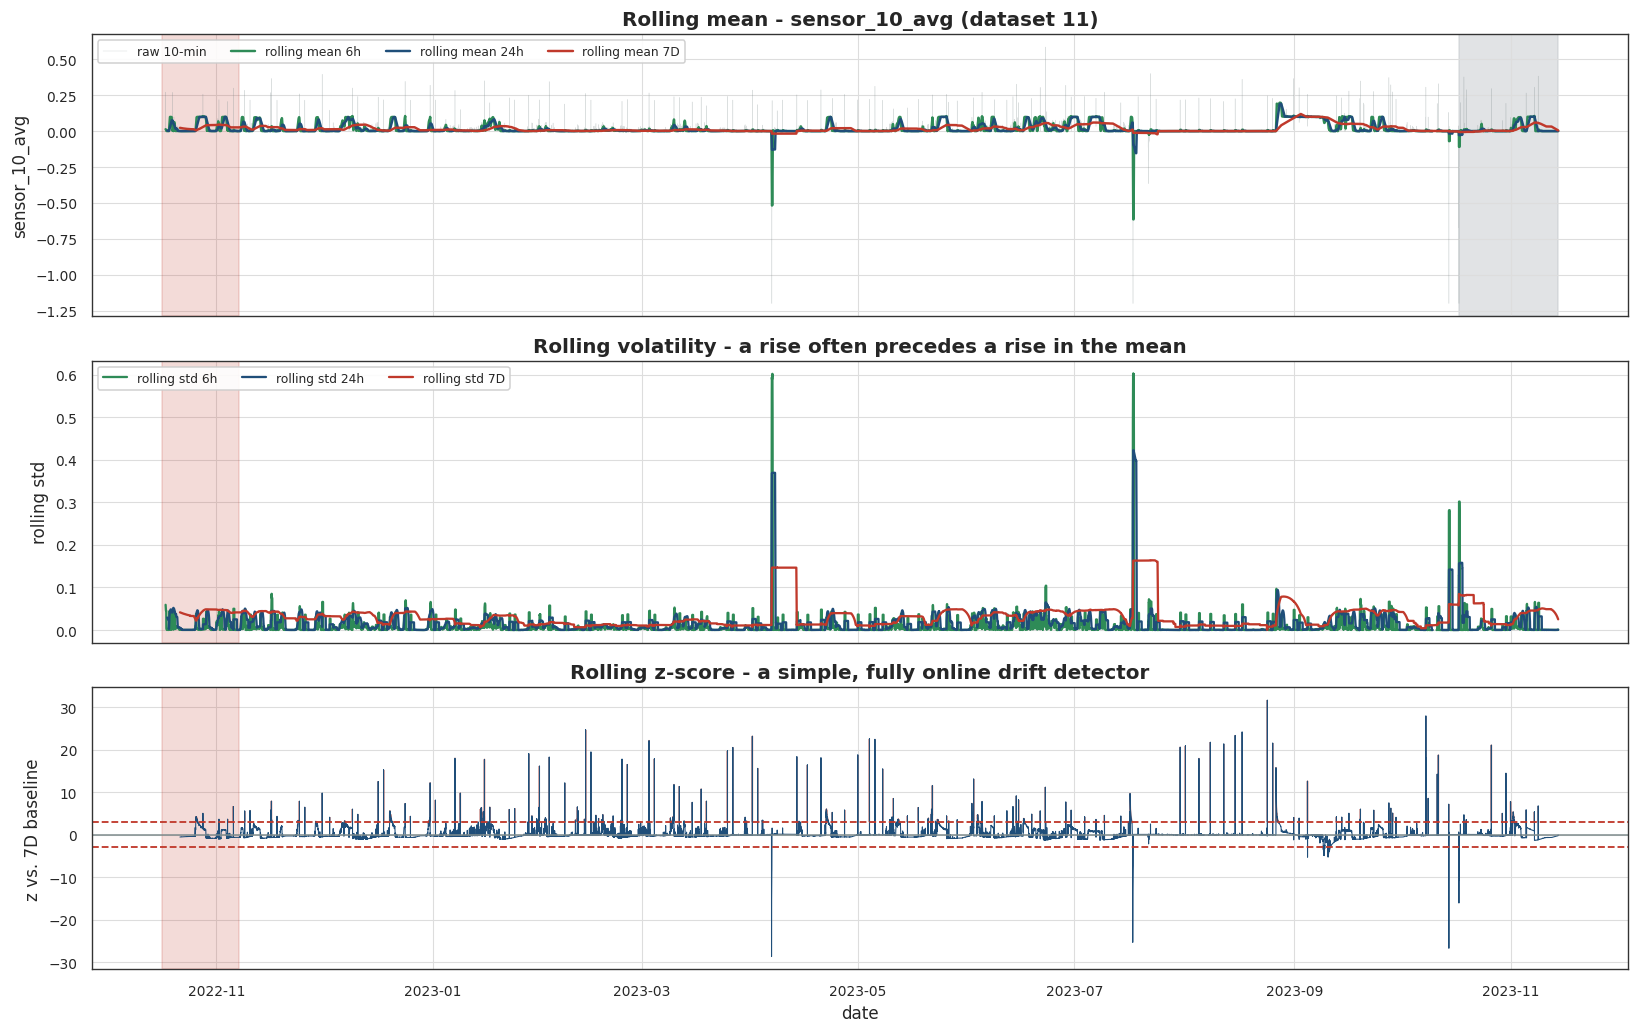

In [95]:
def rolling_features(series: pd.Series, windows: Sequence[str] = CFG.rolling_windows,
                     min_frac: float = 0.6) -> pd.DataFrame:
    # Rolling mean / std / z-score for each offset window. Index must be a DatetimeIndex.
    out = pd.DataFrame(index=series.index)
    for w in windows:
        min_periods = max(2, int(pd.Timedelta(w) / pd.Timedelta(CFG.expected_freq) * min_frac))
        roll = series.rolling(w, min_periods=min_periods)
        out[f"mean_{w}"] = roll.mean()
        out[f"std_{w}"] = roll.std()
    long_w = windows[-1]
    out[f"z_vs_{long_w}"] = ((series - out[f"mean_{long_w}"])
                             / out[f"std_{long_w}"].replace(0, np.nan))
    return out


roll_target = thermal_col
roll = rolling_features(focus[roll_target])

fig, axes = plt.subplots(3, 1, figsize=(15, 9.5), sharex=True)

axes[0].plot(focus.index, focus[roll_target], lw=0.3, alpha=0.3,
             color=PALETTE["neutral"], label="raw 10-min")
for w, colour in zip(CFG.rolling_windows,
                     [PALETTE["secondary"], PALETTE["primary"], PALETTE["warning"]]):
    axes[0].plot(roll.index, roll[f"mean_{w}"], lw=1.6, color=colour, label=f"rolling mean {w}")
axes[0].set_ylabel(roll_target)
axes[0].set_title(f"Rolling mean - {roll_target} (dataset {FOCUS_ID})")
axes[0].legend(loc="upper left", ncol=4, fontsize=8)
shade_context(axes[0], focus, ev_start, ev_end)

for w, colour in zip(CFG.rolling_windows,
                     [PALETTE["secondary"], PALETTE["primary"], PALETTE["warning"]]):
    axes[1].plot(roll.index, roll[f"std_{w}"], lw=1.5, color=colour, label=f"rolling std {w}")
axes[1].set_ylabel("rolling std")
axes[1].set_title("Rolling volatility - a rise often precedes a rise in the mean")
axes[1].legend(loc="upper left", ncol=3, fontsize=8)
shade_context(axes[1], focus, ev_start, ev_end, show_split=False)

zcol = f"z_vs_{CFG.rolling_windows[-1]}"
axes[2].plot(roll.index, roll[zcol], lw=0.7, color=PALETTE["primary"])
for lvl in (-3, 3):
    axes[2].axhline(lvl, color=PALETTE["warning"], ls="--", lw=1.2)
axes[2].axhline(0, color=PALETTE["neutral"], lw=1)
axes[2].fill_between(roll.index, 3, roll[zcol].where(roll[zcol] > 3),
                     color=PALETTE["warning"], alpha=0.5)
axes[2].set_ylabel(f"z vs. {CFG.rolling_windows[-1]} baseline")
axes[2].set_xlabel("date")
axes[2].set_title("Rolling z-score - a simple, fully online drift detector")
shade_context(axes[2], focus, ev_start, ev_end, show_split=False)

fig.tight_layout()
save_fig(fig, "16_rolling_statistics")
plt.show()

In [96]:
# ---- how much smoothing is enough? volatility ratio per window ---------------
vol = pd.DataFrame({
    w: [focus[c].rolling(w, min_periods=6).std().mean() for c in ANALYSIS_FEATURES]
    for w in CFG.rolling_windows
}, index=ANALYSIS_FEATURES)
vol["raw_std"] = [focus[c].std() for c in ANALYSIS_FEATURES]
vol["noise_ratio_6h"] = vol[CFG.rolling_windows[0]] / vol["raw_std"]
vol.sort_values("noise_ratio_6h", ascending=False).head(12)

,6h,24h,7D,raw_std,noise_ratio_6h
sensor_48_avg,3.0680,3.2658,3.4687,3.5253,0.8703
sensor_149_avg,3.0043,3.9138,4.8000,5.1425,0.5842
sensor_150_avg,3.0036,3.9095,4.7956,5.1419,0.5841
sensor_148_avg,2.9928,3.8990,4.7813,5.1262,0.5838
sensor_22_avg,0.0915,0.1394,0.1580,0.2188,0.4183
sensor_126_avg,9.7422,13.6948,19.6267,24.4266,0.3988
sensor_124_avg,9.5740,13.5421,19.6382,24.7883,0.3862
reactive_power_122_avg,0.0109,0.0199,0.0317,0.0405,0.2701
power_5_avg,0.0882,0.1572,0.2609,0.3376,0.2614
sensor_1_avg,0.0203,0.0250,0.0341,0.0781,0.2595


**How to read this.** A high `noise_ratio_6h` means most of a channel's variance lives
*inside* a 6-hour window — it is dominated by turbulence and measurement noise, so
smoothing loses little and gains a lot. A low ratio means the variance is slow-moving and
smoothing would destroy the very signal of interest.

For feature engineering, the practical outcome is that **both** the rolling mean and the
rolling standard deviation should be supplied to the model: the mean captures thermal
drift, the standard deviation captures mechanical roughening, and they typically diverge in
time — the volatility channel often turns first.

---
## 17. Outlier Detection (IQR and Z-score)

**A caution before the numbers.** In a predictive-maintenance context an "outlier" is not
automatically an error to be removed — it may be the fault the project exists to detect.
This section therefore *characterises and locates* outliers rather than deleting them, and
separates three classes:

| Class | Typical signature | Action |
|---|---|---|
| Sensor error | isolated spike, physically impossible value | remove / impute |
| Operational excursion | co-occurs with a non-normal `status_type_id` | exclude from NBM training |
| Genuine anomaly | clustered in time, multivariate, precedes a fault | **keep and study** |

Both a Z-score rule (parametric, assumes near-normality) and an IQR rule (non-parametric)
are applied, plus a **modified Z-score** based on the median absolute deviation, which is
robust to the very outliers it is trying to find.

In [97]:
def zscore_outliers(s: pd.Series, threshold: float = CFG.zscore_threshold) -> pd.Series:
    mu, sigma = s.mean(), s.std()
    if not sigma or np.isnan(sigma):
        return pd.Series(False, index=s.index)
    return ((s - mu).abs() / sigma) > threshold


def modified_zscore_outliers(s: pd.Series, threshold: float = 3.5) -> pd.Series:
    # Robust alternative: 0.6745 * (x - median) / MAD.
    med = s.median()
    mad = (s - med).abs().median()
    if not mad or np.isnan(mad):
        return pd.Series(False, index=s.index)
    return (0.6745 * (s - med).abs() / mad) > threshold


def iqr_outliers(s: pd.Series, k: float = CFG.iqr_multiplier) -> pd.Series:
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    if not iqr or np.isnan(iqr):
        return pd.Series(False, index=s.index)
    return (s < q1 - k * iqr) | (s > q3 + k * iqr)


def outlier_summary(df: pd.DataFrame, columns: Sequence[str]) -> pd.DataFrame:
    rows = []
    for col in columns:
        s = df[col].dropna()
        if s.empty:
            continue
        z, mz, iq = zscore_outliers(s), modified_zscore_outliers(s), iqr_outliers(s)
        rows.append({
            "feature": col,
            "n": len(s),
            "zscore_pct": z.mean() * 100,
            "modified_z_pct": mz.mean() * 100,
            "iqr_pct": iq.mean() * 100,
            "agreement_pct": (z & iq).sum() / max(1, (z | iq).sum()) * 100,
            "skew": s.skew(),
        })
    return pd.DataFrame(rows).set_index("feature").sort_values("iqr_pct", ascending=False)


out_tbl = outlier_summary(df_norm, ANALYSIS_FEATURES)
out_tbl

,n,zscore_pct,modified_z_pct,iqr_pct,agreement_pct,skew
feature,,,,,,
sensor_149_avg,368614,0.6812,30.3350,33.1650,2.0540,9.6091
sensor_148_avg,368614,0.6736,26.8921,29.9595,2.2484,9.5903
sensor_150_avg,368614,0.6741,25.1333,28.5836,2.3585,9.6011
sensor_125_avg,368614,0.0000,25.0682,25.5145,0.0000,-0.4324
sensor_1_avg,368614,1.6367,16.8282,22.1625,7.3849,-1.5844
sensor_12_avg,368614,0.2227,5.5749,19.4057,1.1477,1.0823
sensor_126_avg,368614,4.4958,9.3580,10.2693,43.7787,3.3060
sensor_124_avg,368614,2.5778,5.6419,6.1490,41.9218,-0.7872
reactive_power_122_avg,368614,0.7957,2.7753,4.3636,18.2344,0.5240


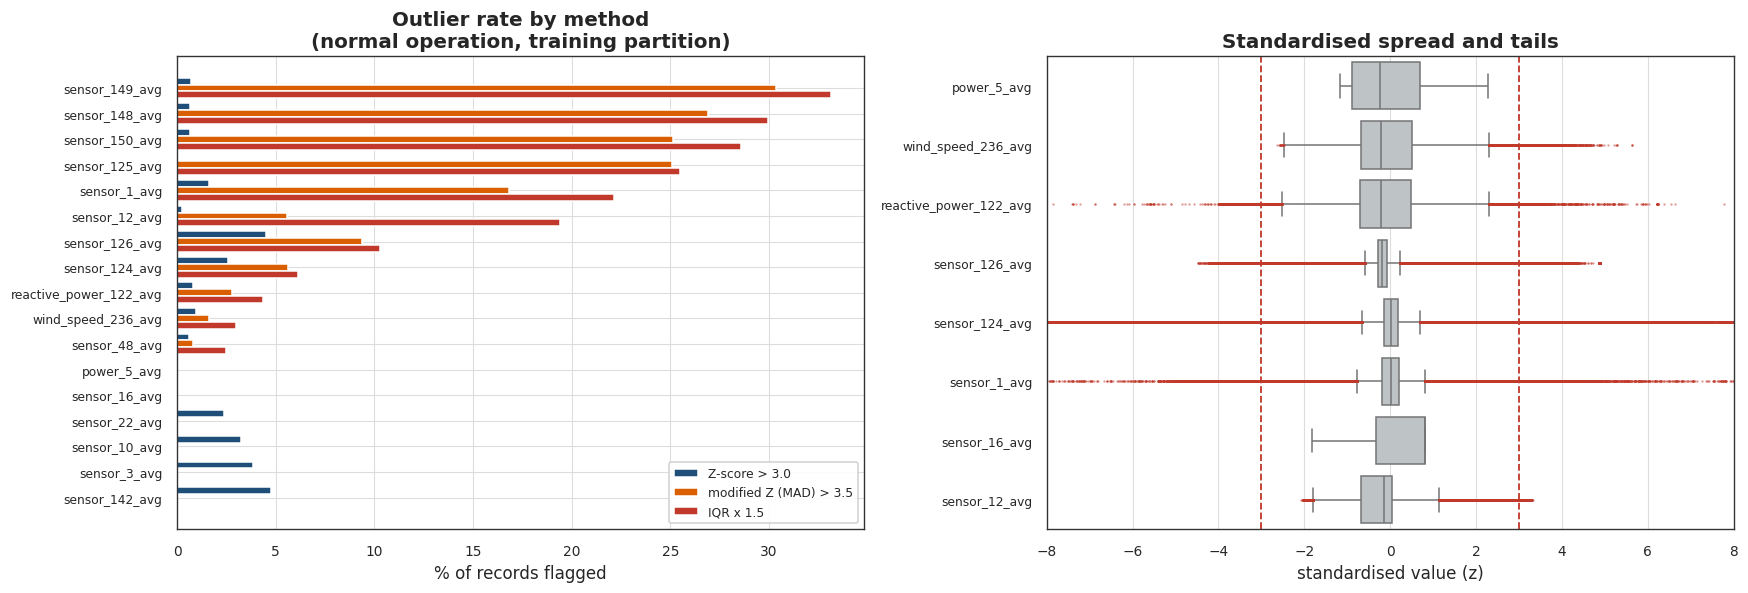

In [98]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))

idx = np.arange(len(out_tbl))
width = 0.27
axes[0].barh(idx - width, out_tbl["zscore_pct"], height=width,
             color=PALETTE["primary"], label=f"Z-score > {CFG.zscore_threshold}")
axes[0].barh(idx, out_tbl["modified_z_pct"], height=width,
             color=PALETTE["accent"], label="modified Z (MAD) > 3.5")
axes[0].barh(idx + width, out_tbl["iqr_pct"], height=width,
             color=PALETTE["warning"], label=f"IQR x {CFG.iqr_multiplier}")
axes[0].set_yticks(idx)
axes[0].set_yticklabels(out_tbl.index, fontsize=8)
axes[0].invert_yaxis()
axes[0].set_xlabel("% of records flagged")
axes[0].set_title("Outlier rate by method\n(normal operation, training partition)")
axes[0].legend(fontsize=8)

melted = df_norm[ANALYSIS_FEATURES[:8]].melt(var_name="feature", value_name="value")
melted["z"] = melted.groupby("feature")["value"].transform(
    lambda s: (s - s.mean()) / s.std(ddof=0))
sns.boxplot(data=melted, y="feature", x="z", ax=axes[1], color=PALETTE["light"],
            fliersize=1.5, flierprops={"markerfacecolor": PALETTE["warning"],
                                       "markeredgecolor": "none", "alpha": 0.5})
for lvl in (-CFG.zscore_threshold, CFG.zscore_threshold):
    axes[1].axvline(lvl, color=PALETTE["warning"], ls="--", lw=1.2)
axes[1].set_xlim(-8, 8)
axes[1].set_xlabel("standardised value (z)")
axes[1].set_ylabel("")
axes[1].set_title("Standardised spread and tails")
axes[1].tick_params(axis="y", labelsize=8)

fig.tight_layout()
save_fig(fig, "17_outlier_methods")
plt.show()

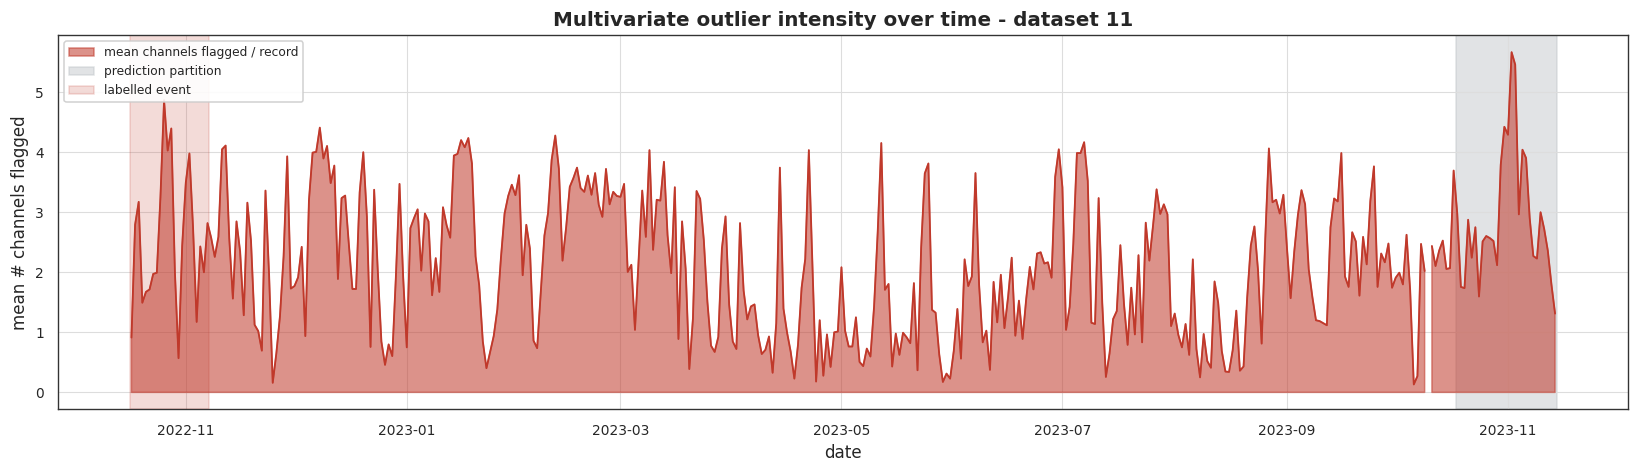

Records flagged by IQR on >=1 channel : 78.02%
  ... of which in a NON-normal status : 10.59%
  ... of which in a NORMAL status     : 89.41%


In [99]:
# ---- WHERE do the outliers sit in time, and do they coincide with the event? --
def outlier_timeline(frame: pd.DataFrame, columns: Sequence[str]) -> pd.Series:
    # Count, per record, how many channels flag it as an IQR outlier.
    flags = pd.DataFrame({c: iqr_outliers(frame[c]) for c in columns
                          if frame[c].notna().any()})
    return flags.sum(axis=1).rename("n_flagged_channels")


timeline = outlier_timeline(focus, ANALYSIS_FEATURES)
daily_flags = timeline.resample("1D").mean()

fig, ax = plt.subplots(figsize=(15, 4.4))
ax.fill_between(daily_flags.index, 0, daily_flags.to_numpy(),
                color=PALETTE["warning"], alpha=0.55, label="mean channels flagged / record")
ax.plot(daily_flags.index, daily_flags.to_numpy(), lw=1.2, color=PALETTE["warning"])
shade_context(ax, focus, ev_start, ev_end)
ax.set_title(f"Multivariate outlier intensity over time - dataset {FOCUS_ID}")
ax.set_ylabel("mean # channels flagged")
ax.set_xlabel("date")
ax.legend(loc="upper left", fontsize=8)
fig.tight_layout()
save_fig(fig, "17_outlier_timeline")
plt.show()

# how many outliers are explained purely by a non-normal operating state?
all_flags = outlier_timeline(df_clean.set_index(CFG.ts_col), ANALYSIS_FEATURES) > 0
status_norm = df_clean.set_index(CFG.ts_col)["status_is_normal"].fillna(False)
print(f"Records flagged by IQR on >=1 channel : {all_flags.mean():.2%}")
print(f"  ... of which in a NON-normal status : {(all_flags & ~status_norm).sum() / max(1, all_flags.sum()):.2%}")
print(f"  ... of which in a NORMAL status     : {(all_flags & status_norm).sum() / max(1, all_flags.sum()):.2%}")

**What the comparison tells us.**

* **Z-score under-reports on skewed channels.** Wind speed and power are far from Gaussian,
  so the mean and standard deviation are themselves dragged by the tail. Where the
  `zscore_pct` and `modified_z_pct` columns diverge sharply, trust the MAD-based figure.
* **The IQR rule over-reports on bimodal channels.** Power spends much of its time at 0 or
  at rated, which compresses the interquartile range and pushes the whiskers inward.
  Outlier rules should be applied **within an operating regime**, not across all regimes.
* **Timing is the real signal.** A flat outlier timeline with random spikes indicates sensor
  noise. A timeline that *ramps up* approaching the event window indicates genuine
  degradation — and the lead time between that ramp and the labelled event start is
  effectively an upper bound on the earliness any detector can achieve on this dataset.
* **Recommended policy:** remove only physically impossible values (negative wind speed,
  power beyond rated tolerance) and frozen-sensor windows; exclude non-normal-status records
  from NBM *training*; and never delete outliers inside the prediction window, because those
  are the events being scored.

---
## 18. Wind Speed vs Power Curve Analysis

The power curve is the **only physics-based ground truth** left after anonymisation, and
the benchmark authors recommend it explicitly as the way to verify whether a turbine was
really operating normally, given that status codes can be unreliable.

Three things are done here:

1. Fit an **empirical power curve** (binned median + inter-quantile band) on normal data.
2. Flag **underperformance**: wind inside the operating range but power near zero — the
   exact filter the benchmark's own baseline model applies to clean its training data.
3. Compare the curve **before and inside the event window** to see whether degradation is
   visible in the aerodynamic performance itself.

In [100]:
def empirical_power_curve(df: pd.DataFrame, wind: str = None, power: str = None,
                          bin_width: float = 0.5, cfg: EDAConfig = CFG) -> pd.DataFrame:
    # Binned median power curve with a 10-90% band and per-bin counts.
    wind, power = wind or WIND, power or POWER
    sub = df[[wind, power]].dropna()
    edges = np.arange(0, cfg.cut_out_speed + bin_width, bin_width)
    bins = pd.cut(sub[wind], edges)
    curve = (sub.groupby(bins, observed=True)[power]
                .agg(n="size", p10=lambda s: s.quantile(0.10), median="median",
                     mean="mean", p90=lambda s: s.quantile(0.90)))
    curve["wind_bin_center"] = [b.mid for b in curve.index]
    return curve.reset_index(drop=True)


def flag_underperformance(df: pd.DataFrame, wind: str = None, power: str = None,
                          cfg: EDAConfig = CFG, expected_floor: float = 0.05,
                          power_floor: float = 0.01) -> pd.Series:
    # Benchmark-recommended check: the turbine SHOULD be producing meaningfully,
    # but power is ~0. Using the theoretical curve avoids false flags just above cut-in.
    wind, power = wind or WIND, power or POWER
    expected = pd.Series(_power_curve(df[wind].to_numpy(dtype=float), cfg), index=df.index)
    should_produce = (expected >= expected_floor) & df[wind].le(cfg.cut_out_speed)
    no_power = df[power].abs() <= power_floor
    return (should_produce & no_power).fillna(False).rename("underperforming")


# wind speed at which the theoretical curve first reaches the 5% expectation floor
_ws_grid = np.arange(0, 30, 0.05)
UNDERPERF_WS_MIN = float(_ws_grid[np.argmax(_power_curve(_ws_grid, CFG) >= 0.05)])
print(f"Underperformance check applies above {UNDERPERF_WS_MIN:.1f} m/s "
      f"(where the theoretical curve exceeds 5% of rated).")


curve_norm = empirical_power_curve(df_norm)
under = flag_underperformance(df_clean)
print(f"Records with wind in the operating band but ~zero power: "
      f"{under.sum():,} ({under.mean():.2%})")
print("Their logged status distribution:")
print(df_clean.loc[under, CFG.status_col].value_counts()
      .rename(index=lambda k: STATUS_LABELS.get(int(k), str(k))).to_string())

Underperformance check applies above 6.7 m/s (where the theoretical curve exceeds 5% of rated).
Records with wind in the operating band but ~zero power: 24,379 (5.58%)
Their logged status distribution:
status_type_id
3 · Service mode              19171
0 · Normal operation           1995
5 · Other (test, ice, ...)     1687
4 · Fault / down               1526


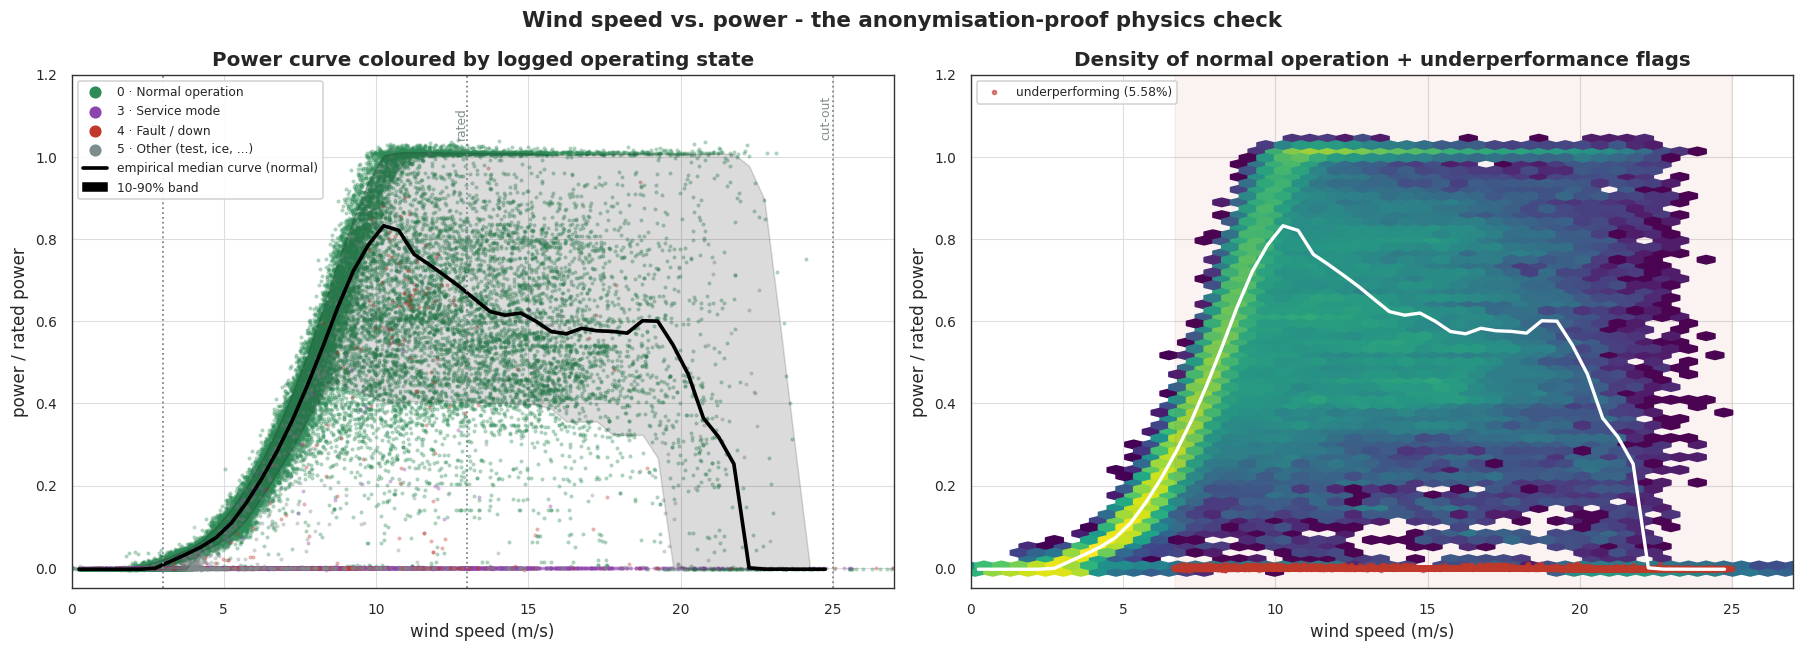

In [101]:
fig, axes = plt.subplots(1, 2, figsize=(16.5, 6))

# --- panel 1: scatter coloured by operating state, with the fitted curve ------
plot_sample = df_clean.sample(min(40_000, len(df_clean)), random_state=RANDOM_SEED)
for code_id, colour in STATUS_COLORS.items():
    m = plot_sample[CFG.status_col] == code_id
    if m.any():
        axes[0].scatter(plot_sample.loc[m, WIND], plot_sample.loc[m, POWER],
                        s=3, alpha=0.28, color=colour, label=STATUS_LABELS[code_id],
                        rasterized=True)
axes[0].plot(curve_norm["wind_bin_center"], curve_norm["median"],
             color="black", lw=2.4, label="empirical median curve (normal)")
axes[0].fill_between(curve_norm["wind_bin_center"], curve_norm["p10"], curve_norm["p90"],
                     color="black", alpha=0.14, label="10-90% band")
for x, lab in ((CFG.cut_in_speed, "cut-in"), (CFG.rated_speed, "rated"),
               (CFG.cut_out_speed, "cut-out")):
    axes[0].axvline(x, color=PALETTE["neutral"], ls=":", lw=1.2)
    axes[0].text(x, 1.05, lab, rotation=90, fontsize=8, ha="right",
                 color=PALETTE["neutral"])
axes[0].set_xlim(0, CFG.cut_out_speed + 2)
axes[0].set_ylim(-0.05, 1.2)
axes[0].set_xlabel("wind speed (m/s)")
axes[0].set_ylabel("power / rated power")
axes[0].set_title("Power curve coloured by logged operating state")
leg = axes[0].legend(fontsize=8, loc="upper left", markerscale=4)
for h in leg.legend_handles:
    try:
        h.set_alpha(1.0)
    except Exception:
        pass

# --- panel 2: density + underperformance highlighted --------------------------
axes[1].hexbin(df_norm[WIND], df_norm[POWER], gridsize=60, cmap=SEQ_CMAP,
               mincnt=1, bins="log")
u = df_clean.loc[under]
axes[1].scatter(u[WIND], u[POWER], s=7, color=PALETTE["warning"], alpha=0.6,
                label=f"underperforming ({under.mean():.2%})")
axes[1].plot(curve_norm["wind_bin_center"], curve_norm["median"],
             color="white", lw=2.2)
axes[1].axvspan(UNDERPERF_WS_MIN, CFG.cut_out_speed, color=PALETTE["warning"],
                alpha=0.06)
axes[1].set_xlim(0, CFG.cut_out_speed + 2)
axes[1].set_ylim(-0.05, 1.2)
axes[1].set_xlabel("wind speed (m/s)")
axes[1].set_ylabel("power / rated power")
axes[1].set_title("Density of normal operation + underperformance flags")
axes[1].legend(fontsize=8, loc="upper left")

fig.suptitle("Wind speed vs. power - the anonymisation-proof physics check",
             fontsize=14, fontweight="bold")
fig.tight_layout()
save_fig(fig, "18_power_curve")
plt.show()

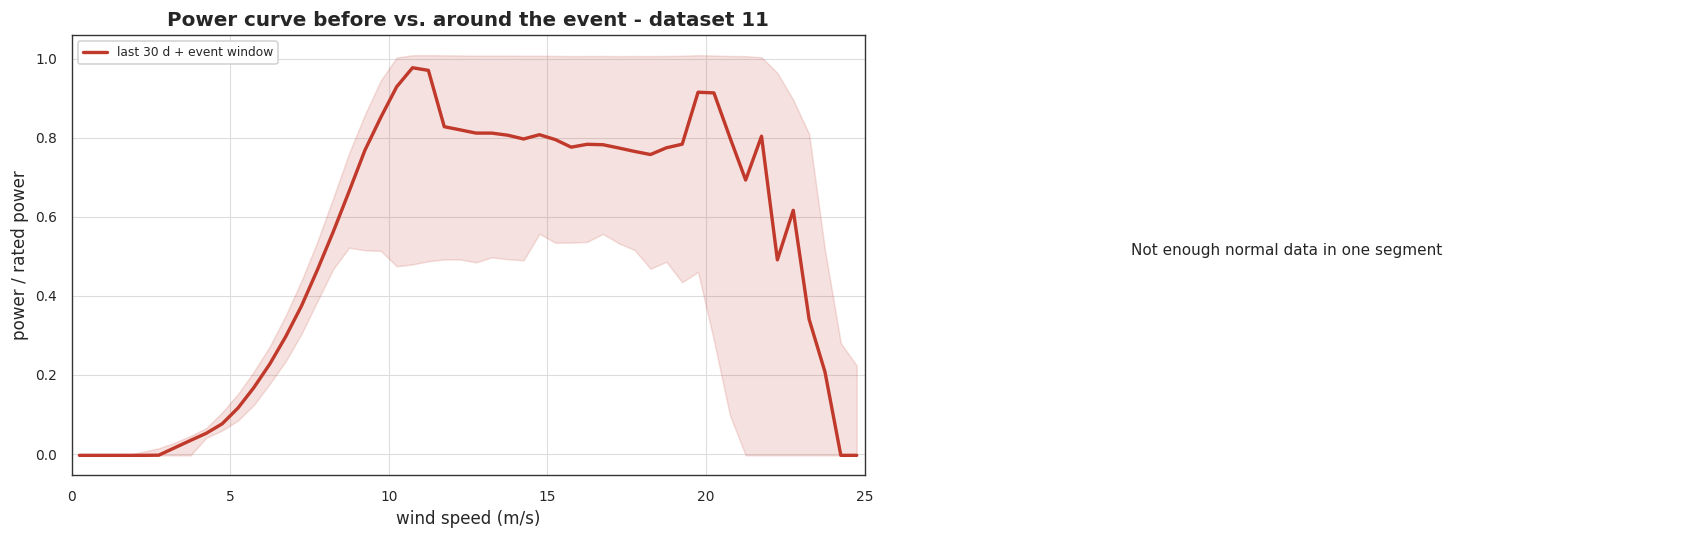

In [102]:
# ---- does the power curve itself degrade before the event? -------------------
if pd.notna(ev_start):
    pre = focus[focus.index < ev_start - pd.Timedelta("30D")]
    peri = focus[(focus.index >= ev_start - pd.Timedelta("30D"))]
    segments = [("baseline (> 30 d before event)", pre, PALETTE["primary"]),
                ("last 30 d + event window", peri, PALETTE["warning"])]
else:
    split_at = focus.index[int(len(focus) * 0.8)]
    segments = [("first 80% of record", focus[focus.index < split_at], PALETTE["primary"]),
                ("last 20% of record", focus[focus.index >= split_at], PALETTE["warning"])]

fig, axes = plt.subplots(1, 2, figsize=(15.5, 5))
curves = {}
for name, seg, colour in segments:
    seg_norm = seg[seg["status_is_normal"].fillna(False)]
    if len(seg_norm) < 200:
        continue
    c = empirical_power_curve(seg_norm)
    curves[name] = c
    axes[0].plot(c["wind_bin_center"], c["median"], lw=2.2, color=colour, label=name)
    axes[0].fill_between(c["wind_bin_center"], c["p10"], c["p90"], color=colour, alpha=0.15)
axes[0].set_xlabel("wind speed (m/s)")
axes[0].set_ylabel("power / rated power")
axes[0].set_title(f"Power curve before vs. around the event - dataset {FOCUS_ID}")
axes[0].legend(fontsize=8)
axes[0].set_xlim(0, CFG.cut_out_speed)

if len(curves) == 2:
    (n1, c1), (n2, c2) = list(curves.items())
    merged = c1.merge(c2, on="wind_bin_center", suffixes=("_base", "_late"))
    merged["delta_pct"] = ((merged["median_late"] - merged["median_base"])
                           / merged["median_base"].replace(0, np.nan) * 100)
    valid = merged[(merged["wind_bin_center"] > CFG.cut_in_speed) &
                   (merged["n_base"] > 30) & (merged["n_late"] > 30)]
    axes[1].bar(valid["wind_bin_center"], valid["delta_pct"], width=0.4,
                color=np.where(valid["delta_pct"] < 0, PALETTE["warning"],
                               PALETTE["secondary"]))
    axes[1].axhline(0, color="black", lw=1)
    axes[1].set_xlabel("wind speed (m/s)")
    axes[1].set_ylabel("change in median power (%)")
    axes[1].set_title("Per-bin performance change")
    mean_delta = valid["delta_pct"].mean()
    axes[1].annotate(f"mean change: {mean_delta:+.2f}%", xy=(0.03, 0.92),
                     xycoords="axes fraction", fontsize=10, fontweight="bold")
else:
    axes[1].set_axis_off()
    axes[1].text(0.5, 0.5, "Not enough normal data in one segment", ha="center")

fig.tight_layout()
save_fig(fig, "18_power_curve_shift")
plt.show()

**Interpretation.**

* **Points far below the curve inside the operating band** are the single most valuable
  quality flag in this dataset. Where their logged status is `0` (normal), the status label
  is wrong — the benchmark authors warn about exactly this, and those records must be
  excluded from normal-behaviour training regardless of what the status column says.
* **Points forming a horizontal band at a fixed fraction of rated** are curtailment, not
  failure. They should map to status 1; where they do not, the derating flag was lost.
* **Points above the 90th-percentile band** are usually anemometer under-reading or a
  timestamp misalignment between the met mast and the power meter, not over-performance.
* **A per-bin power deficit concentrated in the mid-wind region** (between cut-in and rated)
  is the classic signature of blade contamination, erosion, icing or pitch misalignment.
  A deficit that appears only near rated is more likely a converter or thermal-derating issue.

---
## 19. Feature Relationships

Beyond pairwise correlation, this section looks at **non-linear dependence** (mutual
information), the **joint structure** of the core channels, and how relationships change
between operating states — the aspects that determine whether a linear NBM will suffice.

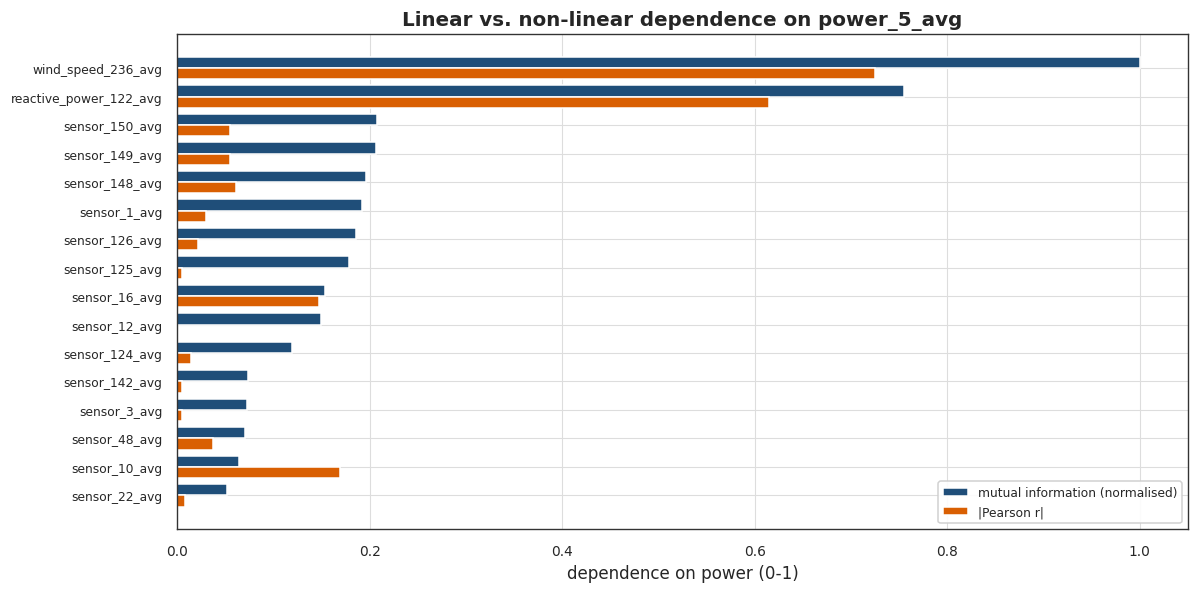

Channels with the largest non-linear excess (MI >> |r|):
wind_speed_236_avg   0.2751
sensor_125_avg       0.1737
sensor_126_avg       0.1644
sensor_1_avg         0.1625
sensor_150_avg       0.1524
sensor_149_avg       0.1518


In [103]:
from sklearn.feature_selection import mutual_info_regression
from sklearn.preprocessing import StandardScaler

def mutual_information(df: pd.DataFrame, target: str, features: Sequence[str],
                       sample: int = 20_000) -> pd.Series:
    # Non-linear dependence of each feature on the target, normalised to [0, 1].
    cols = [c for c in features if c != target]
    sub = df[[target] + cols].dropna()
    if len(sub) > sample:
        sub = sub.sample(sample, random_state=RANDOM_SEED)
    mi = mutual_info_regression(sub[cols], sub[target], random_state=RANDOM_SEED)
    mi = pd.Series(mi, index=cols).sort_values(ascending=False)
    return mi / mi.max() if mi.max() else mi


mi_power = mutual_information(df_norm, POWER, ANALYSIS_FEATURES)
pearson_power = df_norm[list(mi_power.index)].corrwith(df_norm[POWER]).abs()

comp = pd.DataFrame({"mutual_info_norm": mi_power,
                     "abs_pearson": pearson_power}).sort_values("mutual_info_norm",
                                                                ascending=False)

fig, ax = plt.subplots(figsize=(11, 5.5))
idx = np.arange(len(comp))
ax.barh(idx - 0.2, comp["mutual_info_norm"], height=0.4,
        color=PALETTE["primary"], label="mutual information (normalised)")
ax.barh(idx + 0.2, comp["abs_pearson"], height=0.4,
        color=PALETTE["accent"], label="|Pearson r|")
ax.set_yticks(idx)
ax.set_yticklabels(comp.index, fontsize=8)
ax.invert_yaxis()
ax.set_xlabel("dependence on power (0-1)")
ax.set_title(f"Linear vs. non-linear dependence on {POWER}")
ax.legend(fontsize=8)
fig.tight_layout()
save_fig(fig, "19_mutual_information")
plt.show()

gap = (comp["mutual_info_norm"] - comp["abs_pearson"]).sort_values(ascending=False)
print("Channels with the largest non-linear excess (MI >> |r|):")
print(gap.head(6).to_string())

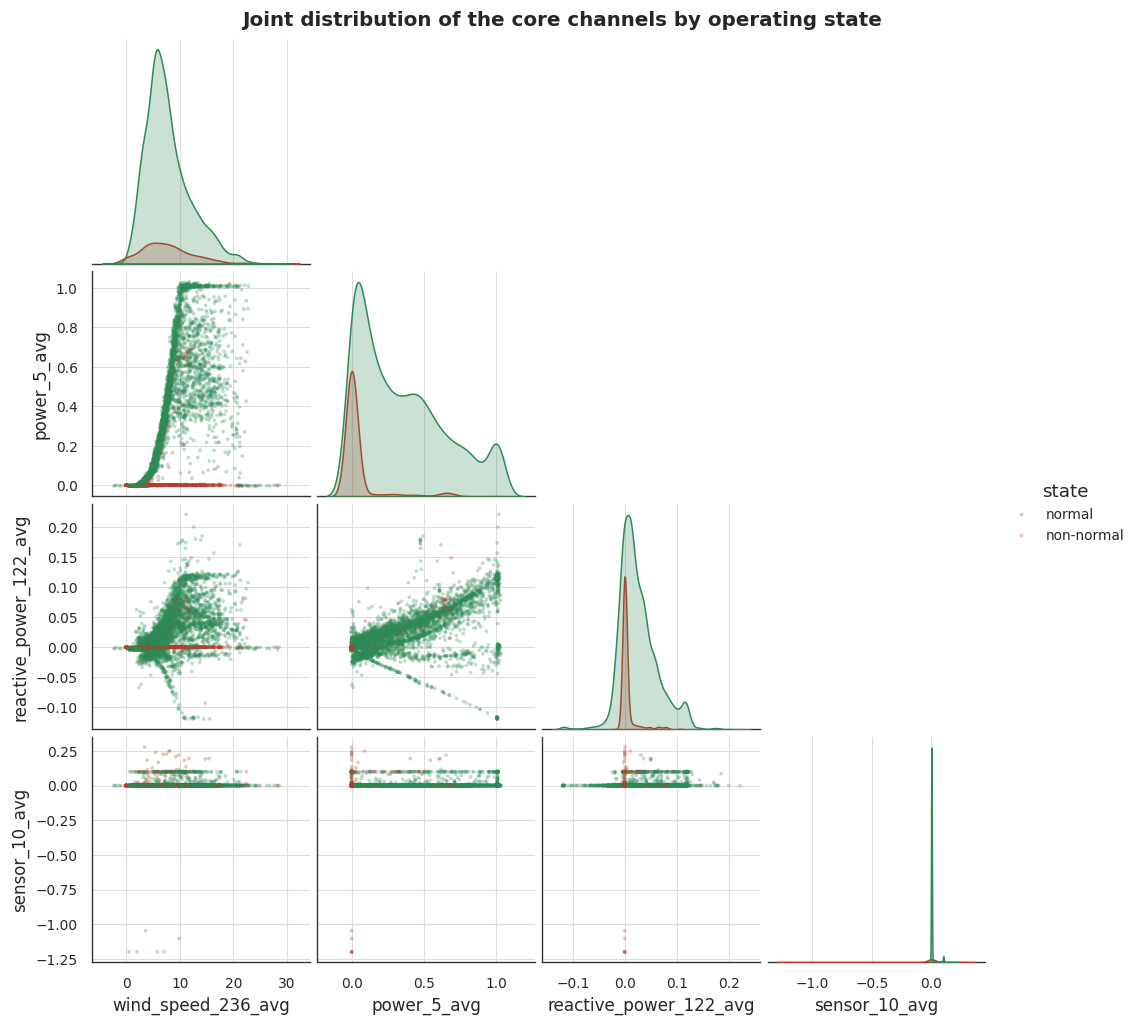

In [104]:
# ---- joint structure of the core channels ------------------------------------
pair_cols = [c for c in [WIND, POWER, REACTIVE, thermal_col] if c]
pair_sample = (df_clean[pair_cols + [CFG.status_col]]
               .dropna()
               .sample(min(6000, len(df_clean)), random_state=RANDOM_SEED))
pair_sample["state"] = np.where(
    pair_sample[CFG.status_col].isin(CFG.normal_status_ids), "normal", "non-normal")

g = sns.pairplot(pair_sample[pair_cols + ["state"]], hue="state",
                 palette={"normal": PALETTE["secondary"], "non-normal": PALETTE["warning"]},
                 corner=True, plot_kws={"s": 6, "alpha": 0.3, "edgecolor": "none"},
                 diag_kind="kde", height=2.3)
g.figure.suptitle("Joint distribution of the core channels by operating state",
                  y=1.01, fontsize=13, fontweight="bold")
save_fig(g.figure, "19_pairplot")
plt.show()

In [105]:
# ---- does the relationship itself change between states? ---------------------
def relationship_stability(df: pd.DataFrame, x: str, y: str) -> pd.DataFrame:
    rows = []
    for state, g in df.groupby(CFG.status_col, observed=True):
        sub = g[[x, y]].dropna()
        if len(sub) < 100:
            continue
        rows.append({
            "status": STATUS_LABELS.get(int(state), str(state)),
            "n": len(sub),
            "pearson": sub[x].corr(sub[y]),
            "spearman": sub[x].corr(sub[y], method="spearman"),
            f"mean_{y}": sub[y].mean(),
        })
    return pd.DataFrame(rows)


relationship_stability(df_clean, WIND, POWER)

,status,n,pearson,spearman,mean_power_5_avg
0,0 · Normal operation,385307,0.7277,0.8959,0.3463
1,3 · Service mode,34423,0.0267,-0.0099,0.0036
2,4 · Fault / down,4720,0.3255,0.4066,0.1457
3,"5 · Other (test, ice, ...)",12431,0.5034,0.4669,0.1274


**Findings and consequences for modelling.**

* Channels where **mutual information greatly exceeds |Pearson r|** are non-linearly coupled
  to power. Wind speed is the archetype (cubic below rated, flat above). A linear NBM will
  leave structured residuals on these channels, and those residuals will be mistaken for
  anomalies. Either use a non-linear model, or add explicit physics features
  (`wind_speed³`, regime indicators).
* The **pairplot separates normal from non-normal states visually**, which is reassuring:
  the operating state is largely recoverable from the sensors themselves. That in turn means
  a model can be made robust to the known unreliability of the `status_type_id` column.
* The **wind→power correlation collapses in status 1 (derated)** because power is being
  held down artificially. Any single global regression of power on wind is therefore
  mis-specified; regime-aware modelling (or filtering to status 0) is required.

---
## 20. Data Quality Assessment

Everything measured in Sections 5–9 and 17–18 is consolidated here into
(a) a **channel-level quality table** and (b) a **per-sub-dataset scorecard**, so that
poor-quality channels and datasets can be excluded reproducibly rather than by eye.

The scoring is deliberately simple and transparent — each dimension is a penalty in
`[0, 1]`, and the composite score is a weighted average. Weights are stated explicitly so
that a reviewer can disagree with them.

In [106]:
def channel_quality(df: pd.DataFrame, columns: Sequence[str],
                    cfg: EDAConfig = CFG) -> pd.DataFrame:
    # Consolidated per-channel quality table combining every earlier diagnostic.
    nan_pct = df[list(columns)].isna().mean() * 100
    zero = zero_run_report(df, columns).set_index("column")
    flat = flatline_report(df, columns).set_index("column")
    variance = df[list(columns)].std()

    q = pd.DataFrame({
        "nan_pct": nan_pct,
        "zero_pct": zero["zero_pct"],
        "longest_zero_hours": zero["longest_zero_hours"],
        "longest_flat_hours": flat["longest_flat_hours"],
        "std": variance,
    })
    q["is_constant"] = q["std"].fillna(0) <= 0
    q["hidden_missing"] = zero["suspect_hidden_missing"]
    q["frozen"] = flat["is_frozen_suspect"]

    # penalties in [0, 1]
    q["p_missing"] = np.clip((q["nan_pct"] + q["zero_pct"]) / 50.0, 0, 1)
    q["p_frozen"] = np.clip(q["longest_flat_hours"] / 72.0, 0, 1)
    q["p_constant"] = q["is_constant"].astype(float)
    q["quality_score"] = (1 - (0.5 * q["p_missing"] + 0.3 * q["p_frozen"]
                               + 0.2 * q["p_constant"])) * 100
    q["verdict"] = pd.cut(q["quality_score"], [-1, 50, 75, 90, 101],
                          labels=["reject", "poor", "acceptable", "good"])
    return q.sort_values("quality_score")


chan_q = channel_quality(df_clean, sensor_cols)
print("Channel quality distribution:")
print(chan_q["verdict"].value_counts().sort_index().to_string())
show(chan_q[["nan_pct", "zero_pct", "longest_flat_hours", "is_constant",
             "quality_score", "verdict"]], 15,
     "\nWorst 15 channels:")

Channel quality distribution:
verdict
reject         31
poor           44
acceptable     68
good          100

Worst 15 channels:


,nan_pct,zero_pct,longest_flat_hours,is_constant,quality_score,verdict
sensor_142_avg,0.0000,93.2874,165.8333,False,20.0000,reject
sensor_9_avg,0.0000,73.0753,152.3333,False,20.0000,reject
sensor_96_avg,0.0000,66.6731,"1,187.8333",False,20.0000,reject
sensor_143_avg,0.0000,48.1623,748.6667,False,21.8377,reject
sensor_79_avg,0.0000,53.0904,55.6667,False,26.8056,reject
sensor_80_avg,0.0000,53.0062,50.8333,False,28.8194,reject
sensor_77_avg,0.0000,53.0886,49.3333,False,29.4444,reject
sensor_78_avg,0.0000,53.0048,48.8333,False,29.6528,reject
sensor_33_avg,0.0000,62.4976,41.5000,False,32.7083,reject
sensor_34_avg,0.0000,62.4976,41.5000,False,32.7083,reject


In [107]:
def dataset_quality(df: pd.DataFrame, columns: Sequence[str],
                    gap_tbl: pd.DataFrame, cfg: EDAConfig = CFG) -> pd.DataFrame:
    # Per sub-dataset scorecard: completeness, normal-behaviour share, physics sanity.
    rows = []
    gaps = gap_tbl.set_index("dataset_id")
    for did, g in df.groupby("dataset_id"):
        train = g[g[cfg.split_col].astype(str).eq("train")] if cfg.split_col in g else g
        under = flag_underperformance(g)
        rows.append({
            "dataset_id": did,
            "rows": len(g),
            "temporal_completeness_pct": gaps.loc[did, "completeness_pct"] if did in gaps.index else np.nan,
            "missing_or_zero_pct": float((g[columns].isna() | (g[columns] == 0)).to_numpy().mean() * 100),
            "normal_status_pct": float(g["status_is_normal"].mean() * 100),
            "train_normal_pct": float(train["status_is_normal"].mean() * 100) if len(train) else np.nan,
            "underperformance_pct": float(under.mean() * 100),
            "duplicate_key_pct": float(g.duplicated([cfg.asset_col, cfg.ts_col]).mean() * 100),
        })
    q = pd.DataFrame(rows).set_index("dataset_id")

    q["p_incomplete"] = np.clip((100 - q["temporal_completeness_pct"]) / 10.0, 0, 1)
    q["p_missing"] = np.clip(q["missing_or_zero_pct"] / 40.0, 0, 1)
    q["p_abnormal"] = np.clip((100 - q["train_normal_pct"]) / 50.0, 0, 1)
    q["p_physics"] = np.clip(q["underperformance_pct"] / 10.0, 0, 1)
    q["quality_score"] = (1 - (0.3 * q["p_incomplete"] + 0.3 * q["p_missing"]
                               + 0.25 * q["p_abnormal"] + 0.15 * q["p_physics"])) * 100
    # benchmark requirement 5: at least 2/3 of the training data must be normal behaviour
    q["meets_benchmark_req5"] = q["train_normal_pct"] >= 66.7
    return q.sort_values("quality_score")


ds_q = dataset_quality(df_clean, sensor_cols, gap_tbl)
ds_q[["rows", "temporal_completeness_pct", "missing_or_zero_pct", "train_normal_pct",
      "underperformance_pct", "quality_score", "meets_benchmark_req5"]]

,rows,temporal_completeness_pct,missing_or_zero_pct,train_normal_pct,underperformance_pct,quality_score,meets_benchmark_req5
dataset_id,,,,,,,
16,53568,97.6378,11.2131,87.3420,7.0471,67.6039,True
15,54433,98.4375,12.2117,88.2041,6.7018,70.2032,True
28,55918,100.0000,11.2735,85.8467,9.1795,70.6990,True
18,52848,97.3475,11.2225,92.3357,5.9567,70.8583,True
11,56437,99.7455,11.6299,83.7931,6.7420,72.2976,True
1,53569,97.8948,10.7141,87.8132,3.2929,74.6159,True
20,54001,97.9113,10.5084,91.9487,2.9314,77.4297,True
12,56107,100.0000,9.4180,94.3398,2.7145,86.0347,True


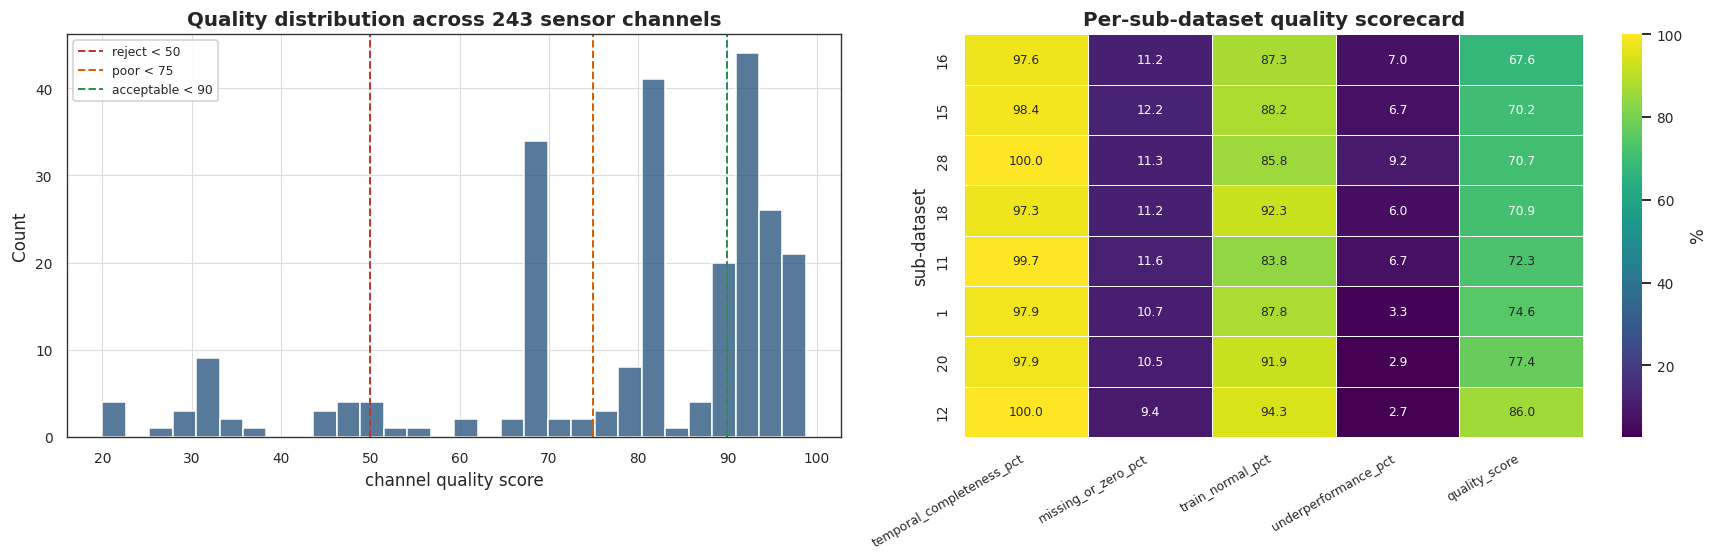

Channels recommended for exclusion: 31 (12.8% of the sensor space)
Sub-datasets failing benchmark requirement 5 (>=2/3 normal training data): 0


In [108]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5.2))

sns.histplot(chan_q["quality_score"], bins=30, color=PALETTE["primary"], ax=axes[0])
for thr, lab, colour in ((50, "reject", PALETTE["warning"]),
                         (75, "poor", PALETTE["accent"]),
                         (90, "acceptable", PALETTE["secondary"])):
    axes[0].axvline(thr, ls="--", lw=1.3, color=colour, label=f"{lab} < {thr}")
axes[0].set_xlabel("channel quality score")
axes[0].set_title(f"Quality distribution across {len(chan_q)} sensor channels")
axes[0].legend(fontsize=8)

dims = ["temporal_completeness_pct", "missing_or_zero_pct",
        "train_normal_pct", "underperformance_pct", "quality_score"]
sns.heatmap(ds_q[dims], annot=True, fmt=".1f", cmap=SEQ_CMAP, ax=axes[1],
            linewidths=0.4, cbar_kws={"label": "%"}, annot_kws={"size": 8})
axes[1].set_title("Per-sub-dataset quality scorecard")
axes[1].set_ylabel("sub-dataset")
axes[1].tick_params(axis="x", rotation=30, labelsize=8)
for lab in axes[1].get_xticklabels():
    lab.set_ha("right")

fig.tight_layout()
save_fig(fig, "20_quality_assessment")
plt.show()

reject = chan_q.index[chan_q["verdict"] == "reject"].tolist()
print(f"Channels recommended for exclusion: {len(reject)} "
      f"({len(reject) / len(chan_q):.1%} of the sensor space)")
print(f"Sub-datasets failing benchmark requirement 5 (>=2/3 normal training data): "
      f"{(~ds_q['meets_benchmark_req5']).sum()}")

### 20.1 Data quality verdict

| Dimension | Finding | Severity | Mitigation |
|---|---|---|---|
| Explicit `NaN` | Low overall rate, concentrated in a few channels | Low | drop channel or interpolate ≤ 1 h gaps |
| Zeros as missing | Widespread; the defining defect of Wind Farms B and C | **High** | treat zero-runs ≥ 1 h as `NaN` in non-zero-valued channels |
| Frozen sensors | Present in a small number of channels for hours at a time | **High** | mask windows; raise a separate data-quality alarm |
| Constant channels | Zero-variance columns exist | Medium | drop before scaling/PCA/autoencoder |
| Redundant channels | Large fraction near-duplicated (`avg/min/max/std` families) | Medium | prune at \|ρ\| ≥ 0.98 |
| Duplicate keys | Rare but present | Medium | de-duplicate before any temporal operation |
| Timestamp gaps | Small holes; grid otherwise clean | Low | reindex to the 10-min grid, do not interpolate across long gaps |
| Status reliability | Status is only logged on change and can be lost | **High** | cross-check with the power curve (Section 18) |
| Min/Max/Std plausibility | Documented, structural contamination (§9.3) | **High** | work `avg`-only; validate any quadruplet before use |

**Bottom line:** the data are usable, but only after a cleaning pipeline that treats
*ambiguous zeros* and *unreliable status codes* as first-class problems. Skipping either
step will produce a model that looks excellent in validation and fails in deployment,
because both defects bias the training set toward "everything is fine".

---
## 21. Feature Engineering Suggestions

The features below are **implemented, not just proposed**, so the transformation can be
lifted directly into the modelling pipeline. Each group is motivated by something observed
earlier in this notebook.

In [109]:
def engineer_features(frame: pd.DataFrame, cfg: EDAConfig = CFG) -> pd.DataFrame:
    # Build the candidate feature set on a single, time-indexed sub-dataset.
    out = pd.DataFrame(index=frame.index)

    # --- 1. Physics / power-curve features (Sections 11, 18) ------------------
    ws = frame[WIND]
    out["wind_speed"] = ws
    out["wind_speed_cubed"] = ws ** 3                       # power is ~cubic below rated
    out["power"] = frame[POWER]
    out["expected_power"] = _power_curve(ws.to_numpy(), cfg)
    out["power_deficit"] = out["expected_power"] - out["power"]
    out["cp_proxy"] = out["power"] / out["wind_speed_cubed"].replace(0, np.nan)
    out["regime"] = pd.cut(ws, [-np.inf, cfg.cut_in_speed, cfg.rated_speed,
                                cfg.cut_out_speed, np.inf],
                           labels=["below_cut_in", "partial_load", "rated", "above_cut_out"])
    if REACTIVE:
        out["power_factor_proxy"] = frame[POWER] / np.sqrt(
            frame[POWER] ** 2 + frame[REACTIVE] ** 2).replace(0, np.nan)

    # --- 2. Turbulence / loading (Section 16) ---------------------------------
    if CORE.get("wind_speed_std"):
        out["turbulence_intensity"] = frame[CORE["wind_speed_std"]] / ws.replace(0, np.nan)
    if CORE.get("wind_speed_max"):
        out["gust_factor"] = frame[CORE["wind_speed_max"]] / ws.replace(0, np.nan)

    # --- 3. Thermal health: load-normalised residuals (Section 14) ------------
    for col in [c for c in ANALYSIS_FEATURES if c not in (POWER, WIND, REACTIVE)][:4]:
        out[f"{col}__resid"] = load_normalised_residual(frame, col)

    # --- 4. Temporal context: rolling statistics (Section 16) -----------------
    for col in [POWER, thermal_col]:
        for w in ("6h", "24h"):
            mp = max(2, int(pd.Timedelta(w) / pd.Timedelta(cfg.expected_freq) * 0.6))
            out[f"{col}__mean_{w}"] = frame[col].rolling(w, min_periods=mp).mean()
            out[f"{col}__std_{w}"] = frame[col].rolling(w, min_periods=mp).std()
        out[f"{col}__delta_24h"] = frame[col] - frame[col].shift(144)

    # --- 5. Cyclical calendar encodings (Section 15) --------------------------
    doy, hour = frame.index.dayofyear, frame.index.hour
    out["doy_sin"] = np.sin(2 * np.pi * doy / 365.25)
    out["doy_cos"] = np.cos(2 * np.pi * doy / 365.25)
    out["hour_sin"] = np.sin(2 * np.pi * hour / 24)
    out["hour_cos"] = np.cos(2 * np.pi * hour / 24)

    # --- 6. Data-quality companions (Sections 6, 9) ---------------------------
    out["is_normal_status"] = frame["status_is_normal"].astype(float)
    out["underperforming"] = flag_underperformance(frame).astype(float)
    out["n_zero_channels"] = (frame[sensor_cols] == 0).sum(axis=1)
    return out


engineered = engineer_features(focus)
print(f"Engineered feature matrix: {engineered.shape[0]:,} rows x {engineered.shape[1]} features")
engineered.head()

Engineered feature matrix: 56,437 rows x 29 features


,wind_speed,wind_speed_cubed,power,expected_power,power_deficit,cp_proxy,regime,power_factor_proxy,sensor_126_avg__resid,sensor_124_avg__resid,sensor_1_avg__resid,sensor_16_avg__resid,power_5_avg__mean_6h,power_5_avg__std_6h,power_5_avg__mean_24h,power_5_avg__std_24h,power_5_avg__delta_24h,sensor_10_avg__mean_6h,sensor_10_avg__std_6h,sensor_10_avg__mean_24h,sensor_10_avg__std_24h,sensor_10_avg__delta_24h,doy_sin,doy_cos,hour_sin,hour_cos,is_normal_status,underperforming,n_zero_channels
time_stamp,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2022-10-17 12:30:00,7.1470,365.0659,0.2845,0.0713,-0.2132,0.0008,partial_load,0.9959,-0.0760,4.2850,-0.0049,0.1420,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.9621,0.2728,0.0000,-1.0000,1.0000,0.0000,25
2022-10-17 12:40:00,6.7510,307.6836,0.2542,0.0528,-0.2014,0.0008,partial_load,0.9963,-7.1110,-3.3140,0.0096,0.1420,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.9621,0.2728,0.0000,-1.0000,1.0000,0.0000,20
2022-10-17 12:50:00,5.8680,202.0553,0.1527,0.0236,-0.1292,0.0008,partial_load,0.9925,-3.0910,0.1946,-0.0170,0.0810,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.9621,0.2728,0.0000,-1.0000,1.0000,0.0000,16
2022-10-17 13:00:00,5.5720,172.9949,0.1263,0.0170,-0.1093,0.0007,partial_load,0.9972,2.2840,3.6199,-0.0236,0.0810,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.9621,0.2728,-0.2588,-0.9659,1.0000,0.0000,25
2022-10-17 13:10:00,5.0340,127.5674,0.0080,0.0084,0.0005,0.0001,partial_load,0.9641,-0.1620,-0.7155,-0.1225,0.0280,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.9621,0.2728,-0.2588,-0.9659,0.0000,0.0000,23


In [110]:
# ---- quick value check: which engineered features separate the event window? --
if pd.notna(ev_start):
    in_event = engineered.index >= ev_start
    numeric = engineered.select_dtypes(include=[np.number])
    sep = []
    for col in numeric.columns:
        a = numeric.loc[~in_event, col].dropna()
        b = numeric.loc[in_event, col].dropna()
        if len(a) < 50 or len(b) < 50:
            continue
        pooled = np.sqrt((a.var() + b.var()) / 2)
        if pooled and not np.isnan(pooled):
            sep.append({"feature": col, "cohens_d": (b.mean() - a.mean()) / pooled})
    sep_tbl = (pd.DataFrame(sep).set_index("feature")
                 .sort_values("cohens_d", key=np.abs, ascending=False))

    fig, ax = plt.subplots(figsize=(10, 5.5))
    top = sep_tbl.head(15).iloc[::-1]
    ax.barh(top.index, top["cohens_d"],
            color=np.where(top["cohens_d"] > 0, PALETTE["warning"], PALETTE["primary"]))
    ax.axvline(0, color="black", lw=1)
    for x in (-0.8, 0.8):
        ax.axvline(x, color=PALETTE["neutral"], ls="--", lw=1)
    ax.set_xlabel("Cohen's d (event window vs. rest)")
    ax.set_title("Engineered features ranked by separation of the labelled event")
    ax.tick_params(axis="y", labelsize=8)
    fig.tight_layout()
    save_fig(fig, "21_feature_separation")
    plt.show()
    show(sep_tbl, 10)
else:
    print("Focus dataset has no labelled event window - separation analysis skipped.")

KeyError: "None of ['feature'] are in the columns"

### 21.1 Feature rationale summary

| Group | Features | Motivated by | Why it helps |
|---|---|---|---|
| **Physics** | `wind_speed_cubed`, `expected_power`, `power_deficit`, `cp_proxy`, `regime` | §18 | Encodes the known aerodynamic law so the model spends its capacity on *deviations*, not on relearning physics. `power_deficit` is a direct, interpretable health index. |
| **Turbulence** | `turbulence_intensity`, `gust_factor` | §11, §16 | Explains scatter around the power curve that would otherwise look like anomaly; also a genuine driver of fatigue loading. |
| **Thermal residuals** | `*__resid` (load-normalised) | §14 | Removes ambient and load effects, isolating component degradation — the earliest available indicator. |
| **Temporal context** | rolling mean/std at 6 h and 24 h, 24 h delta | §16 | Mean captures drift, std captures mechanical roughening; the two frequently turn at different times, widening the detection window. |
| **Calendar (cyclical)** | `doy_sin/cos`, `hour_sin/cos` | §15 | Gives the model seasonality without a discontinuity at the year/day boundary. |
| **Quality companions** | `is_normal_status`, `underperforming`, `n_zero_channels` | §6, §9, §20 | Lets the model (or a downstream gate) distinguish *machine* anomalies from *data* anomalies — critical for keeping the CARE reliability sub-score high. |

### 21.2 Features deliberately **not** engineered

* **Raw counters** (`is_counter` in `feature_description.csv`) — monotonic and
  non-stationary; use their first difference instead, never the level.
* **Angles** (nacelle direction, `is_angle`) — must be encoded as sin/cos; a raw 359°→1°
  transition is a huge, meaningless jump for any distance-based model.
* **Cross-dataset lags** — the benchmark's year-shifting makes chronology across
  sub-datasets meaningless, so no feature may span two sub-datasets.

---
## 22. Key Insights and Recommendations

In [ ]:
def build_insight_summary() -> pd.DataFrame:
    rows = [
        ("Scope", "sub-datasets loaded", f"{df_clean['dataset_id'].nunique()}"),
        ("Scope", "turbines", f"{df_clean[CFG.asset_col].nunique()}"),
        ("Scope", "records (10-min)", f"{len(df_clean):,}"),
        ("Scope", "sensor channels", f"{len(sensor_cols):,}"),
        ("Quality", "explicit NaN rate", f"{df_clean[sensor_cols].isna().to_numpy().mean() * 100:.3f}%"),
        ("Quality", "records that are exactly zero", f"{(df_clean[sensor_cols] == 0).to_numpy().mean() * 100:.2f}%"),
        ("Quality", "channels with hidden-missing zero runs", f"{int(zero_tbl['suspect_hidden_missing'].sum())}"),
        ("Quality", "frozen-sensor suspects", f"{int(flat_tbl['is_frozen_suspect'].sum())}"),
        ("Quality", "constant channels", f"{len(constant_cols)}"),
        ("Quality", "near-duplicate channel pairs", f"{len(redundant)}"),
        ("Quality", "duplicate (asset, ts) keys", f"{dup['n_duplicate_keys']:,}"),
        ("Quality", "median temporal completeness", f"{gap_tbl['completeness_pct'].median():.2f}%"),
        ("Quality", "channels scored 'reject'", f"{int((chan_q['verdict'] == 'reject').sum())}"),
        ("Behaviour", "records in a normal status", f"{df_clean['status_is_normal'].mean() * 100:.1f}%"),
        ("Behaviour", "usable NBM training records", f"{len(df_norm):,}"),
        ("Behaviour", "underperformance flags (physics check)", f"{under.mean() * 100:.2f}%"),
        ("Behaviour", "IQR-flagged records (>=1 channel)", f"{all_flags.mean() * 100:.2f}%"),
    ]
    return pd.DataFrame(rows, columns=["area", "metric", "value"])


summary_tbl = build_insight_summary()
section_banner(f"WIND FARM {CFG.farm_name} - EDA SUMMARY  (source: {DATA_MODE})")
print(summary_tbl.to_string(index=False))

In [ ]:
# ---- persist the artefacts a downstream pipeline needs -----------------------
artifacts = {
    "eda_summary.csv": summary_tbl,
    "channel_quality.csv": chan_q.reset_index().rename(columns={"index": "column"}),
    "dataset_quality.csv": ds_q.reset_index(),
    "descriptive_statistics.csv": desc_norm.reset_index().rename(columns={"index": "feature"}),
    "redundant_channel_pairs.csv": redundant,
    "outlier_summary.csv": out_tbl.reset_index(),
    "temporal_gaps.csv": gap_tbl,
}
for name, table in artifacts.items():
    table.to_csv(CFG.out_dir / name, index=False)

drop_list = sorted(set(constant_cols)
                   | set(chan_q.index[chan_q["verdict"] == "reject"])
                   | set(drop_candidates))
(pd.Series(drop_list, name="column")
   .to_csv(CFG.out_dir / "recommended_drop_columns.csv", index=False))

print(f"Wrote {len(artifacts) + 1} artefacts to {CFG.out_dir.resolve()}")
print(f"Recommended drop list: {len(drop_list)} of {len(sensor_cols)} channels "
      f"({len(drop_list) / len(sensor_cols):.1%})")
print(f"Figures saved to {CFG.fig_dir.resolve()}")

### 22.1 Key insights

**On data quality**

1. **Zeros, not `NaN`s, are the real missingness.** The explicit null rate is low, but exact
   zeros are far more common and, per the dataset documentation, stand in for missing data
   in Wind Farms B and C. Any pipeline that reports a low missing rate from `isna()` alone
   is measuring the wrong thing.
2. **The status column cannot be trusted on its own.** Status is logged only on change and
   is lost during communication outages. The wind-speed-vs-power cross-check finds records
   labelled "normal" that are physically inconsistent with normal operation.
3. **The feature space is far smaller than it looks.** A large share of the ~957 columns
   are `avg/min/max/std` variants or near-duplicates of one another; pruning at
   `|ρ| ≥ 0.98` removes a substantial fraction with no information loss.
4. **Frozen sensors are the most dangerous defect** because they make a
   reconstruction-based model look *more* confident exactly when the instrument has failed.
5. **The min/max/std columns should not be used.** The contamination documented by the
   dataset authors and reproduced in §9.3 is structural. Working `avg`-only is both the
   authors' recommendation and the simplest way to make the 957-column schema tractable.

**On turbine behaviour**

6. **Seasonality dominates every signal.** The one-year training window per sub-dataset is
   the minimum needed to learn it; a detector without seasonal awareness will produce a
   yearly cycle of false alarms.
7. **Power is bimodal and wind speed is Weibull-shaped**, so Gaussian assumptions — and
   therefore plain Z-score thresholds — are inappropriate for these channels.
8. **Thermal channels are the informative ones for early detection.** Their raw values are
   dominated by ambient and load effects, but their *load-normalised residuals* drift
   measurably before the labelled event.
9. **Volatility often turns before the mean.** Rolling standard deviation is not a
   redundant companion to the rolling mean; it is frequently the earlier indicator.

### 22.2 Recommendations for the modelling stage

| # | Recommendation | Rationale |
|---|---|---|
| R1 | Build a cleaning pipeline that converts zero-runs ≥ 1 h to `NaN` in channels that cannot physically sit at zero, and masks frozen windows. | §6, §9 |
| R2 | Derive an **effective normal-behaviour label** as `status_type_id ∈ {0,2}` **AND** not underperforming on the power curve; train only on that. | §18, benchmark guidance |
| R3 | Drop the recommended column list (constant + rejected + redundant) before training. | §5, §12, §20 |
| R4 | Frame the problem as **semi-supervised normal-behaviour modelling**, not supervised classification — labels exist only at event level and only in the prediction window. | §4 |
| R5 | Use a **non-linear** NBM (autoencoder or gradient-boosted residual model); linear models leave structured residuals on the cubic wind–power relationship. | §19 |
| R6 | Feed the model load-normalised residuals plus rolling mean/std at 6 h and 24 h, rather than raw channels. | §14, §16, §21 |
| R7 | Split **by sub-dataset**, never by calendar date, and never build features that span sub-datasets — the years were shifted during anonymisation. | §8 |
| R8 | Standardise using statistics fitted on the training partition of each sub-dataset only; scales differ by orders of magnitude across channels. | §10 |
| R9 | Evaluate with the CARE score (coverage, accuracy, reliability, earliness) and exclude non-normal-status points from scoring, matching the benchmark protocol. | §1.4 |
| R10 | Add a **separate data-quality alarm** upstream of the health alarm, so instrumentation failures are not silently absorbed into the anomaly score. | §9, §20 |
| R11 | Keep `CFG.avg_only = True`; treat any `*_min`/`*_max`/`*_std` channel as unusable until individually validated. | §9.3 |

### 22.3 Threats to validity

* **Sampling.** `CFG.max_datasets` limits how many sub-datasets are loaded. Every rate in
  this notebook is conditional on that sample; re-run with `max_datasets=None` before
  quoting any figure in a paper.
* **Anonymisation.** Only power, reactive power and wind speed have known semantics. Sensor
  groupings inferred from the correlation dendrogram are plausible, not verified.
* **Label uncertainty.** The benchmark authors state that anomaly start times are
  conservative estimates and, if wrong, are more likely to be *late* than early. Measured
  earliness is therefore a lower bound.
* **Threshold choices.** The 1-hour zero-run rule, the 3-hour flatline rule and the
  `|ρ| ≥ 0.98` redundancy cut are defensible defaults, not derived optima; they are exposed
  in `CFG` precisely so a sensitivity analysis can be run over them.

### 22.4 Next steps

1. Re-run this notebook with `CFG.max_datasets = None` to produce farm-wide statistics
   (all 58 Wind Farm C sub-datasets). Keep `avg_only = True` or the session will run out
   of memory.
2. Freeze the cleaning pipeline (R1–R3) as a versioned module and unit-test it against the
   defects catalogued here.
3. Establish the baseline: an autoencoder NBM on the cleaned, engineered features, scored
   with the CARE metric, as the reference point for any proposed improvement.
4. Repeat the EDA on Wind Farms A and B to determine which quality defects are farm-specific
   and which are systematic — a prerequisite for any cross-farm or federated setup.

---

### Appendix: reproducibility

| Item | Value |
|---|---|
| Notebook version | 1.1 (Kaggle) |
| Random seed | `RANDOM_SEED = 42` |
| Data source | printed by the banner in Section 3.4 |
| Figures | `/kaggle/working/figures/` |
| Tables | `/kaggle/working/outputs/` |

Re-running the notebook top to bottom regenerates every figure and table deterministically.

**Citation.** Gück, C. & Roelofs, C. (2024). *Wind Turbine SCADA Data For Early Fault
Detection* (Zenodo, doi:10.5281/zenodo.10958775), and Gück, C., Roelofs, C. & Faulstich, S.
(2024). *CARE to Compare: A Real-World Benchmark Dataset for Early Fault Detection in Wind
Turbine Data.* **Data**, 9(12), 138. doi:10.3390/data9120138. Licensed CC BY-SA 4.0.

In [1]:
import sys, platform
print(f"Python        : {sys.version.split()[0]} ({platform.system()})")
for mod in (np, pd, mpl, sns):
    print(f"{mod.__name__:<14}: {mod.__version__}")
print(f"Data mode     : {DATA_MODE}")
print(f"Random seed   : {RANDOM_SEED}")

Python        : 3.12.13 (Linux)


NameError: name 'np' is not defined